In [2]:
import pandas as pd
import numpy as np

# ============================================================
# EDA 4.1 — Dataset / Analytical View Sanity Check
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("EDA 4.1 — DATASET / ANALYTICAL VIEW SANITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 2. Basic shape
# ------------------------------------------------------------
print("\n[1] DATASET SHAPE")
print("-" * 70)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# ------------------------------------------------------------
# 3. Column names
# ------------------------------------------------------------
print("\n[2] COLUMNS")
print("-" * 70)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

# ------------------------------------------------------------
# 4. Data types
# ------------------------------------------------------------
print("\n[3] DATA TYPES")
print("-" * 70)
print(df.dtypes.to_string())

# ------------------------------------------------------------
# 5. Date conversion for validation only
# ------------------------------------------------------------
if "Date" not in df.columns:
    print("\nERROR: 'Date' column not found.")
    raise SystemExit

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# ------------------------------------------------------------
# 6. Missing values
# ------------------------------------------------------------
print("\n[4] MISSING VALUES")
print("-" * 70)

missing = df.isna().sum()
missing_total = int(missing.sum())

print(missing.to_string())
print(f"\nTotal missing cells: {missing_total:,}")

# ------------------------------------------------------------
# 7. Duplicate rows
# ------------------------------------------------------------
print("\n[5] DUPLICATE ROW CHECK")
print("-" * 70)

duplicate_rows = int(df.duplicated().sum())

print(f"Duplicate complete rows: {duplicate_rows:,}")

# ------------------------------------------------------------
# 8. Natural key validation
# ------------------------------------------------------------
required_key = ["Date", "Store ID", "Product ID"]

print("\n[6] NATURAL KEY CHECK")
print("-" * 70)

missing_key_columns = [c for c in required_key if c not in df.columns]

if missing_key_columns:
    print("Missing key columns:", missing_key_columns)
else:
    key_duplicates = int(df.duplicated(subset=required_key).sum())

    print("Natural key:")
    print("Date + Store ID + Product ID")
    print(f"Duplicate natural keys: {key_duplicates:,}")

# ------------------------------------------------------------
# 9. Unique entity counts
# ------------------------------------------------------------
print("\n[7] UNIQUE ENTITY COUNTS")
print("-" * 70)

for col in ["Date", "Store ID", "Product ID", "Category", "Region"]:
    if col in df.columns:
        print(f"{col:20}: {df[col].nunique():,}")

# ------------------------------------------------------------
# 10. Date coverage
# ------------------------------------------------------------
print("\n[8] DATE COVERAGE")
print("-" * 70)

valid_dates = df["Date"].dropna()

if len(valid_dates) > 0:
    print(f"Minimum date : {valid_dates.min().date()}")
    print(f"Maximum date : {valid_dates.max().date()}")
    print(f"Unique dates : {valid_dates.nunique():,}")

    expected_dates = pd.date_range(
        start=valid_dates.min(),
        end=valid_dates.max(),
        freq="D"
    )

    actual_dates = pd.DatetimeIndex(valid_dates.unique())

    missing_dates = expected_dates.difference(actual_dates)

    print(f"Expected calendar dates : {len(expected_dates):,}")
    print(f"Missing calendar dates   : {len(missing_dates):,}")

    if len(missing_dates) > 0:
        print("\nFirst missing dates:")
        print(missing_dates[:20].date.tolist())
else:
    print("No valid dates found.")

# ------------------------------------------------------------
# 11. Product × Store series balance
# ------------------------------------------------------------
print("\n[9] PRODUCT × STORE SERIES BALANCE")
print("-" * 70)

if all(c in df.columns for c in ["Store ID", "Product ID", "Date"]):

    series_counts = (
        df.groupby(["Store ID", "Product ID"])["Date"]
        .nunique()
    )

    print(f"Number of Product × Store series: {len(series_counts):,}")
    print(f"Minimum observations per series: {series_counts.min():,}")
    print(f"Maximum observations per series: {series_counts.max():,}")
    print(f"Mean observations per series   : {series_counts.mean():.2f}")
    print(f"Median observations per series : {series_counts.median():.2f}")

    print("\nSeries observation count distribution:")
    print(series_counts.value_counts().sort_index().to_string())

    expected_series = (
        df["Store ID"].nunique() *
        df["Product ID"].nunique()
    )

    print(f"\nExpected Product × Store combinations: {expected_series:,}")
    print(f"Actual Product × Store combinations  : {len(series_counts):,}")

# ------------------------------------------------------------
# 12. Target validation
# ------------------------------------------------------------
print("\n[10] TARGET VARIABLE CHECK")
print("-" * 70)

if "Demand" not in df.columns:
    print("ERROR: Demand column not found.")
else:
    demand = pd.to_numeric(df["Demand"], errors="coerce")

    print(f"Demand NULL values : {demand.isna().sum():,}")
    print(f"Demand minimum     : {demand.min()}")
    print(f"Demand maximum     : {demand.max()}")
    print(f"Demand mean        : {demand.mean():.2f}")
    print(f"Demand median      : {demand.median():.2f}")
    print(f"Negative Demand    : {(demand < 0).sum():,}")

# ------------------------------------------------------------
# 13. Basic numeric integrity
# ------------------------------------------------------------
print("\n[11] NEGATIVE VALUE CHECK")
print("-" * 70)

numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Demand"
]

for col in numeric_columns:
    if col in df.columns:
        numeric_values = pd.to_numeric(df[col], errors="coerce")
        negative_count = int((numeric_values < 0).sum())
        print(f"{col:25}: {negative_count:,} negative values")

# ------------------------------------------------------------
# 14. Final sanity summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SANITY CHECK SUMMARY")
print("=" * 70)

print(f"Rows                         : {len(df):,}")
print(f"Columns                      : {len(df.columns):,}")
print(f"Missing cells                : {missing_total:,}")
print(f"Duplicate complete rows      : {duplicate_rows:,}")

if all(c in df.columns for c in required_key):
    print(f"Duplicate natural keys      : {key_duplicates:,}")

print(f"Unique dates                 : {df['Date'].nunique():,}")
print(f"Unique stores                : {df['Store ID'].nunique():,}")
print(f"Unique products              : {df['Product ID'].nunique():,}")

if "Demand" in df.columns:
    print(f"Demand range                : {demand.min()} → {demand.max()}")

print("=" * 70)
print("EDA 4.1 inspection complete.")
print("NO DATA WAS MODIFIED.")
print("=" * 70)

EDA 4.1 — DATASET / ANALYTICAL VIEW SANITY CHECK

[1] DATASET SHAPE
----------------------------------------------------------------------
Rows    : 76,000
Columns : 16

[2] COLUMNS
----------------------------------------------------------------------
 1. Date
 2. Store ID
 3. Product ID
 4. Category
 5. Region
 6. Inventory Level
 7. Units Sold
 8. Units Ordered
 9. Price
10. Discount
11. Weather Condition
12. Promotion
13. Competitor Pricing
14. Seasonality
15. Epidemic
16. Demand

[3] DATA TYPES
----------------------------------------------------------------------
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epid

EDA 4.2 — DEMAND DISTRIBUTION

[1] DESCRIPTIVE STATISTICS
----------------------------------------------------------------------
count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64

[2] DISTRIBUTION CHARACTERISTICS
----------------------------------------------------------------------
Mean       : 104.32
Median     : 100.00
Std Dev    : 46.96
Minimum    : 4
Maximum    : 430

[3] DEMAND QUANTILES
----------------------------------------------------------------------
0.01     17.0
0.05     34.0
0.10     47.0
0.25     71.0
0.50    100.0
0.75    133.0
0.90    166.0
0.95    188.0
0.99    234.0

[4] SKEWNESS AND KURTOSIS
----------------------------------------------------------------------
Skewness : 0.6078
Kurtosis : 0.6749

[5] EXTREME DEMAND FREQUENCY
----------------------------------------------------------------------
5th percentile t

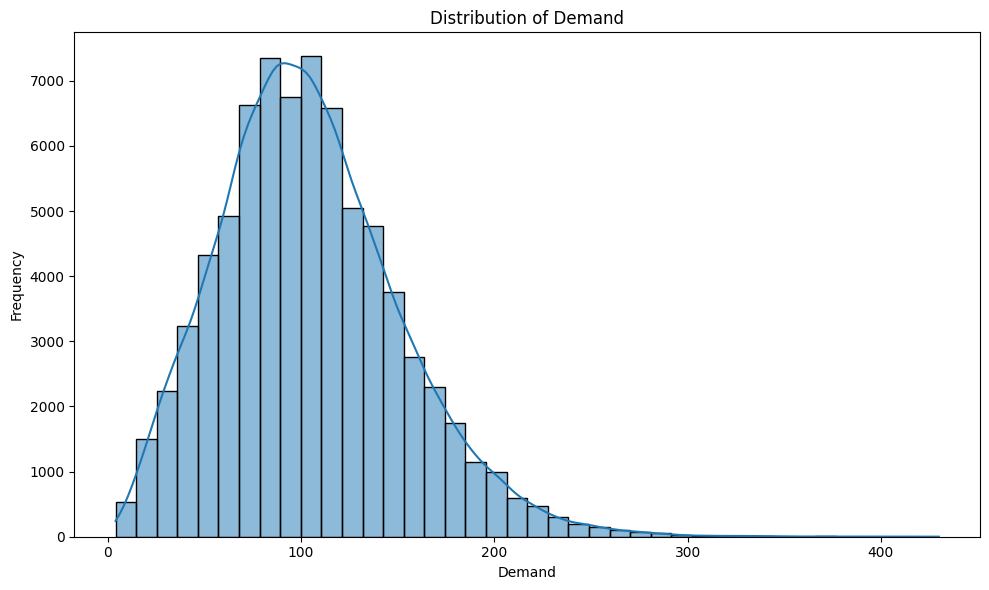

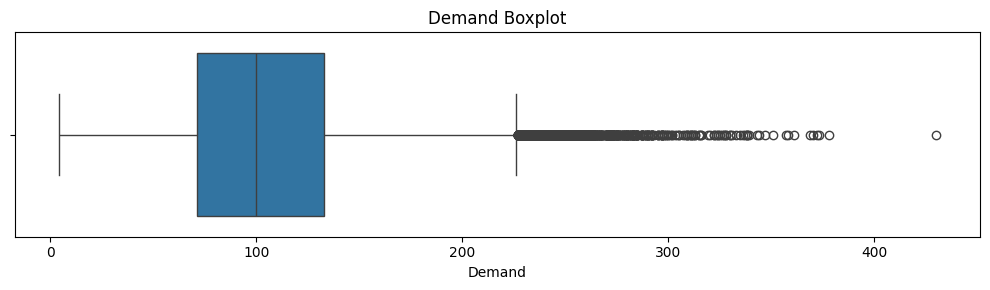


EDA 4.2 COMPLETE
No observations were removed or modified.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EDA 4.2 — DEMAND DISTRIBUTION
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

df = pd.read_csv(FILE_PATH)

# Convert Demand to numeric
df["Demand"] = pd.to_numeric(df["Demand"], errors="coerce")

# ------------------------------------------------------------
# 1. Descriptive statistics
# ------------------------------------------------------------
print("=" * 70)
print("EDA 4.2 — DEMAND DISTRIBUTION")
print("=" * 70)

print("\n[1] DESCRIPTIVE STATISTICS")
print("-" * 70)

print(df["Demand"].describe())

# ------------------------------------------------------------
# 2. Additional distribution statistics
# ------------------------------------------------------------
print("\n[2] DISTRIBUTION CHARACTERISTICS")
print("-" * 70)

mean_demand = df["Demand"].mean()
median_demand = df["Demand"].median()
std_demand = df["Demand"].std()
min_demand = df["Demand"].min()
max_demand = df["Demand"].max()

print(f"Mean       : {mean_demand:.2f}")
print(f"Median     : {median_demand:.2f}")
print(f"Std Dev    : {std_demand:.2f}")
print(f"Minimum    : {min_demand}")
print(f"Maximum    : {max_demand}")

# ------------------------------------------------------------
# 3. Quantiles
# ------------------------------------------------------------
print("\n[3] DEMAND QUANTILES")
print("-" * 70)

quantiles = df["Demand"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print(quantiles.to_string())

# ------------------------------------------------------------
# 4. Skewness and kurtosis
# ------------------------------------------------------------
print("\n[4] SKEWNESS AND KURTOSIS")
print("-" * 70)

print(f"Skewness : {df['Demand'].skew():.4f}")
print(f"Kurtosis : {df['Demand'].kurtosis():.4f}")

# ------------------------------------------------------------
# 5. Low and high demand frequency
# ------------------------------------------------------------
print("\n[5] EXTREME DEMAND FREQUENCY")
print("-" * 70)

low_threshold = df["Demand"].quantile(0.05)
high_threshold = df["Demand"].quantile(0.95)

low_count = int((df["Demand"] <= low_threshold).sum())
high_count = int((df["Demand"] >= high_threshold).sum())

print(f"5th percentile threshold  : {low_threshold:.2f}")
print(f"Observations <= 5th pct   : {low_count:,}")
print(f"Percentage                : {(low_count / len(df)) * 100:.2f}%")

print(f"\n95th percentile threshold : {high_threshold:.2f}")
print(f"Observations >= 95th pct  : {high_count:,}")
print(f"Percentage                : {(high_count / len(df)) * 100:.2f}%")

# ------------------------------------------------------------
# 6. Demand frequency table
# ------------------------------------------------------------
print("\n[6] MOST FREQUENT DEMAND VALUES")
print("-" * 70)

frequency = (
    df["Demand"]
    .value_counts()
    .sort_values(ascending=False)
    .head(15)
)

print(frequency.to_string())

# ------------------------------------------------------------
# 7. Histogram
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Demand"],
    bins=40,
    kde=True
)

plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Boxplot
# ------------------------------------------------------------
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["Demand"]
)

plt.title("Demand Boxplot")
plt.xlabel("Demand")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.2 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.3 — DEMAND OVER TIME

[1] DAILY DEMAND SUMMARY
----------------------------------------------------------------------
Number of daily observations : 760
Minimum daily demand         : 5,859
Maximum daily demand         : 14,093
Mean daily demand            : 10,431.72
Median daily demand          : 10,979.50
Std deviation                : 1,896.42

[2] EARLY VS RECENT DEMAND
----------------------------------------------------------------------
First 30-day average : 11,050.53
Last 30-day average  : 9,805.30
Change               : -11.27%

[3] YEARLY DEMAND
----------------------------------------------------------------------
          sum          mean          std   min    max
Year                                                 
2022  3862652  10582.608219  1751.395967  6009  13772
2023  3771293  10332.309589  2023.178023  5859  14093
2024   294159   9805.300000  1852.310284  6430  12846

[4] MONTHLY DEMAND
---------------------------------------------------------------------

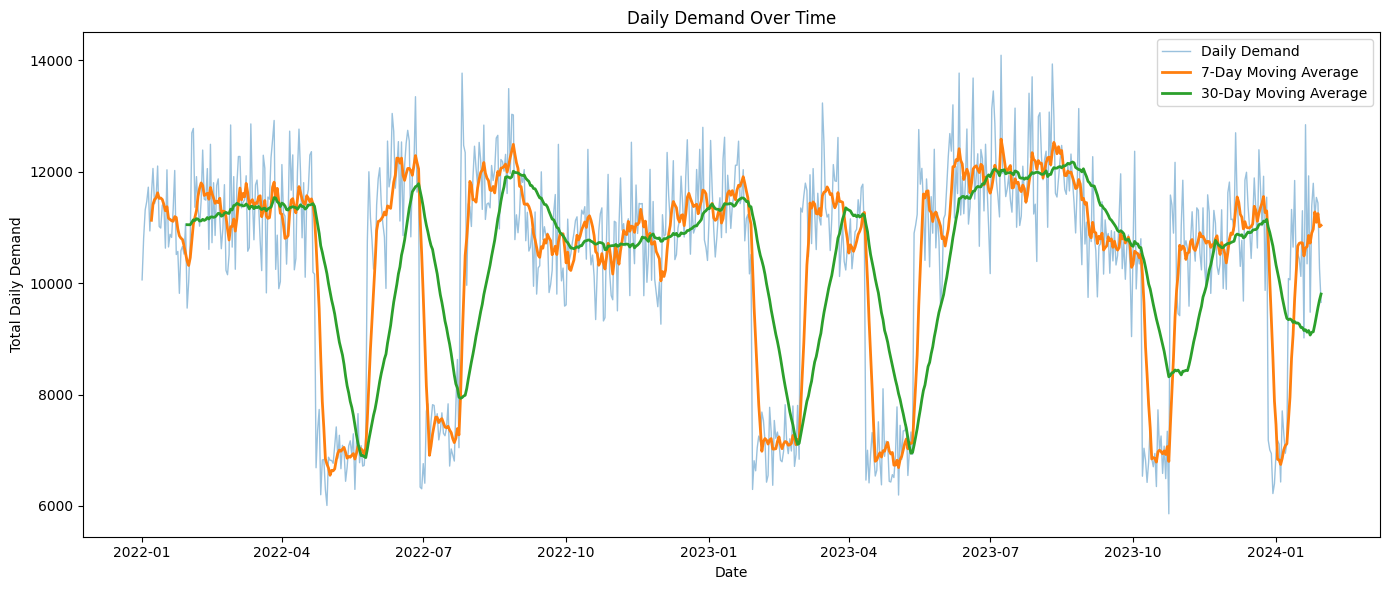

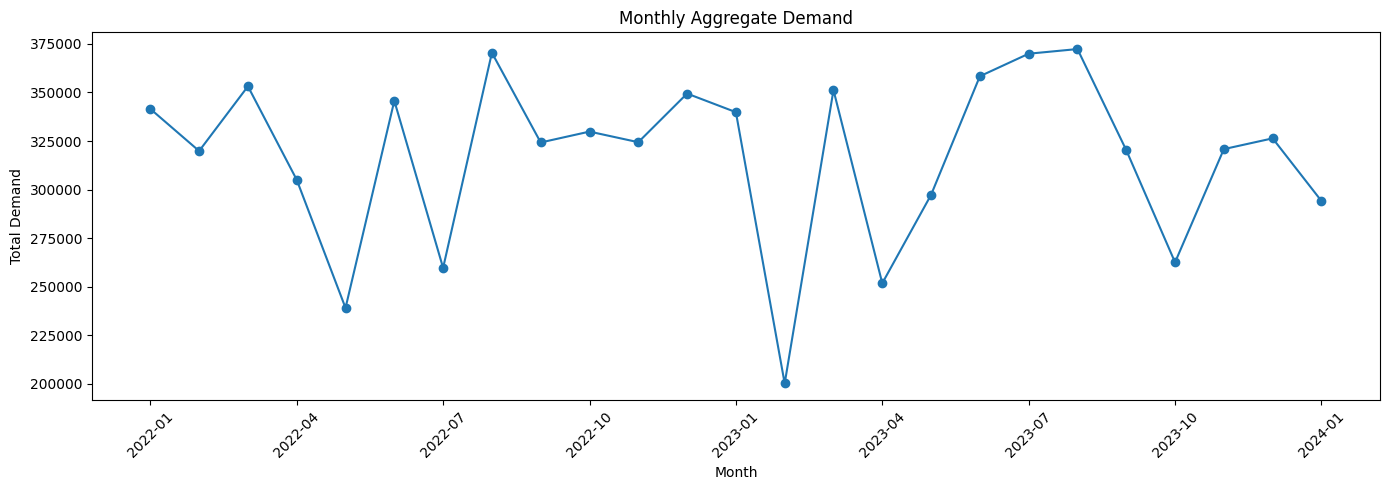


EDA 4.3 COMPLETE
No observations were removed or modified.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EDA 4.3 — DEMAND OVER TIME
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df["Demand"] = pd.to_numeric(df["Demand"], errors="coerce")

# ------------------------------------------------------------
# 2. Aggregate demand by date
# ------------------------------------------------------------
daily_demand = (
    df.groupby("Date", as_index=False)["Demand"]
      .sum()
      .sort_values("Date")
)

# ------------------------------------------------------------
# 3. Calculate rolling averages
# ------------------------------------------------------------
daily_demand["Demand_7D_MA"] = (
    daily_demand["Demand"]
    .rolling(window=7, min_periods=7)
    .mean()
)

daily_demand["Demand_30D_MA"] = (
    daily_demand["Demand"]
    .rolling(window=30, min_periods=30)
    .mean()
)

# ------------------------------------------------------------
# 4. Basic time-series summary
# ------------------------------------------------------------
print("=" * 70)
print("EDA 4.3 — DEMAND OVER TIME")
print("=" * 70)

print("\n[1] DAILY DEMAND SUMMARY")
print("-" * 70)

print(f"Number of daily observations : {len(daily_demand):,}")
print(f"Minimum daily demand         : {daily_demand['Demand'].min():,.0f}")
print(f"Maximum daily demand         : {daily_demand['Demand'].max():,.0f}")
print(f"Mean daily demand            : {daily_demand['Demand'].mean():,.2f}")
print(f"Median daily demand          : {daily_demand['Demand'].median():,.2f}")
print(f"Std deviation                : {daily_demand['Demand'].std():,.2f}")

# ------------------------------------------------------------
# 5. First vs last 30 days
# ------------------------------------------------------------
print("\n[2] EARLY VS RECENT DEMAND")
print("-" * 70)

first_30 = daily_demand.head(30)["Demand"].mean()
last_30 = daily_demand.tail(30)["Demand"].mean()

print(f"First 30-day average : {first_30:,.2f}")
print(f"Last 30-day average  : {last_30:,.2f}")

change_pct = ((last_30 - first_30) / first_30) * 100

print(f"Change               : {change_pct:,.2f}%")

# ------------------------------------------------------------
# 6. Year-level demand
# ------------------------------------------------------------
print("\n[3] YEARLY DEMAND")
print("-" * 70)

daily_demand["Year"] = daily_demand["Date"].dt.year

yearly = (
    daily_demand
    .groupby("Year")["Demand"]
    .agg(["sum", "mean", "std", "min", "max"])
)

print(yearly.to_string())

# ------------------------------------------------------------
# 7. Monthly demand
# ------------------------------------------------------------
print("\n[4] MONTHLY DEMAND")
print("-" * 70)

daily_demand["YearMonth"] = (
    daily_demand["Date"]
    .dt.to_period("M")
)

monthly = (
    daily_demand
    .groupby("YearMonth")["Demand"]
    .sum()
    .reset_index()
)

print(monthly.to_string(index=False))

# ------------------------------------------------------------
# 8. Highest-demand days
# ------------------------------------------------------------
print("\n[5] TOP 10 HIGHEST-DEMAND DAYS")
print("-" * 70)

top_days = (
    daily_demand[["Date", "Demand"]]
    .sort_values("Demand", ascending=False)
    .head(10)
)

print(top_days.to_string(index=False))

# ------------------------------------------------------------
# 9. Lowest-demand days
# ------------------------------------------------------------
print("\n[6] TOP 10 LOWEST-DEMAND DAYS")
print("-" * 70)

low_days = (
    daily_demand[["Date", "Demand"]]
    .sort_values("Demand", ascending=True)
    .head(10)
)

print(low_days.to_string(index=False))

# ------------------------------------------------------------
# 10. Daily demand time-series plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"],
    linewidth=1,
    alpha=0.45,
    label="Daily Demand"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand_7D_MA"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand_30D_MA"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Monthly demand plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    monthly["YearMonth"].astype(str),
    monthly["Demand"],
    marker="o"
)

plt.title("Monthly Aggregate Demand")
plt.xlabel("Month")
plt.ylabel("Total Demand")

plt.xticks(
    ticks=np.arange(0, len(monthly), 3),
    labels=monthly["YearMonth"].astype(str).iloc[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.3 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.4 — TREND ANALYSIS

[1] LINEAR TREND
----------------------------------------------------------------------
Trend slope per day       : -0.3063
Approx. annual change     : -111.81
Starting fitted value     : 10547.97
Ending fitted value       : 10315.47

[2] PERIOD AVERAGES
----------------------------------------------------------------------
Early-period average      : 10458.09
Middle-period average     : 10073.25
Late-period average       : 10762.50

Late vs Early change      : 2.91%

[3] MONTHLY AVERAGE DAILY DEMAND
----------------------------------------------------------------------
YearMonth  days  avg_daily_demand
  2022-01    31      11017.548387
  2022-02    28      11424.392857
  2022-03    31      11392.677419
  2022-04    30      10169.200000
  2022-05    31       7713.290323
  2022-06    30      11524.166667
  2022-07    31       8378.580645
  2022-08    31      11949.580645
  2022-09    30      10808.800000
  2022-10    31      10640.806452
  2022-11    30      10

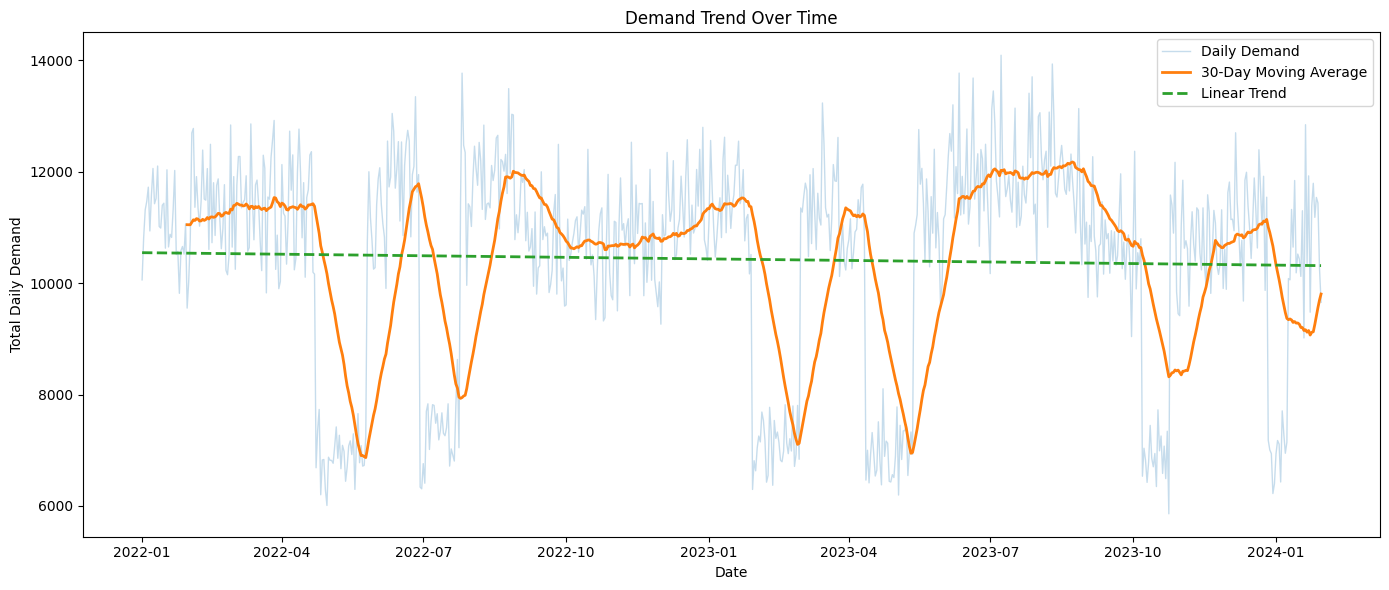

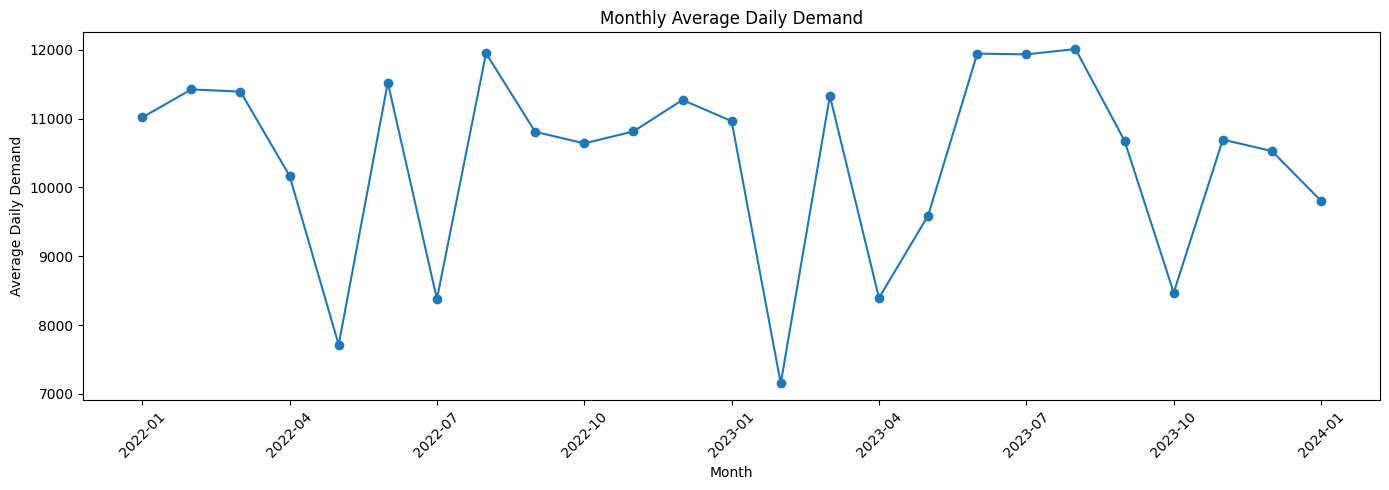


EDA 4.4 COMPLETE
No observations were removed or modified.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EDA 4.4 — TREND ANALYSIS
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df["Demand"] = pd.to_numeric(df["Demand"], errors="coerce")

# ------------------------------------------------------------
# 2. Aggregate demand by date
# ------------------------------------------------------------
daily = (
    df.groupby("Date", as_index=False)["Demand"]
      .sum()
      .sort_values("Date")
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. 30-day moving average
# ------------------------------------------------------------
daily["MA_30"] = (
    daily["Demand"]
    .rolling(window=30, min_periods=30)
    .mean()
)

# ------------------------------------------------------------
# 4. Monthly average DAILY demand
# ------------------------------------------------------------
daily["YearMonth"] = daily["Date"].dt.to_period("M")

monthly = (
    daily.groupby("YearMonth")
    .agg(
        total_demand=("Demand", "sum"),
        days=("Demand", "count"),
        avg_daily_demand=("Demand", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 5. Linear trend on daily aggregate demand
# ------------------------------------------------------------
x = np.arange(len(daily))

slope, intercept = np.polyfit(
    x,
    daily["Demand"],
    1
)

daily["Linear_Trend"] = intercept + slope * x

# Convert slope to approximate daily and annual change
annual_change = slope * 365

# ------------------------------------------------------------
# 6. Early / middle / late period comparison
# ------------------------------------------------------------
n = len(daily)

early = daily.iloc[:n // 3]["Demand"].mean()
middle = daily.iloc[n // 3:2 * n // 3]["Demand"].mean()
late = daily.iloc[2 * n // 3:]["Demand"].mean()

# ------------------------------------------------------------
# 7. Print results
# ------------------------------------------------------------
print("=" * 70)
print("EDA 4.4 — TREND ANALYSIS")
print("=" * 70)

print("\n[1] LINEAR TREND")
print("-" * 70)

print(f"Trend slope per day       : {slope:.4f}")
print(f"Approx. annual change     : {annual_change:.2f}")
print(f"Starting fitted value     : {daily['Linear_Trend'].iloc[0]:.2f}")
print(f"Ending fitted value       : {daily['Linear_Trend'].iloc[-1]:.2f}")

# ------------------------------------------------------------
# 8. Period comparison
# ------------------------------------------------------------
print("\n[2] PERIOD AVERAGES")
print("-" * 70)

print(f"Early-period average      : {early:.2f}")
print(f"Middle-period average     : {middle:.2f}")
print(f"Late-period average       : {late:.2f}")

print(f"\nLate vs Early change      : {((late - early) / early) * 100:.2f}%")

# ------------------------------------------------------------
# 9. Monthly average daily demand
# ------------------------------------------------------------
print("\n[3] MONTHLY AVERAGE DAILY DEMAND")
print("-" * 70)

print(
    monthly[
        ["YearMonth", "days", "avg_daily_demand"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 10. Highest monthly average daily demand
# ------------------------------------------------------------
print("\n[4] HIGHEST MONTHLY AVERAGE DAILY DEMAND")
print("-" * 70)

highest_months = (
    monthly
    .sort_values("avg_daily_demand", ascending=False)
    .head(5)
)

print(
    highest_months[
        ["YearMonth", "days", "avg_daily_demand"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 11. Lowest monthly average daily demand
# ------------------------------------------------------------
print("\n[5] LOWEST MONTHLY AVERAGE DAILY DEMAND")
print("-" * 70)

lowest_months = (
    monthly
    .sort_values("avg_daily_demand", ascending=True)
    .head(5)
)

print(
    lowest_months[
        ["YearMonth", "days", "avg_daily_demand"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 12. Trend plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    daily["Date"],
    daily["Demand"],
    alpha=0.25,
    linewidth=1,
    label="Daily Demand"
)

plt.plot(
    daily["Date"],
    daily["MA_30"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.plot(
    daily["Date"],
    daily["Linear_Trend"],
    linewidth=2,
    linestyle="--",
    label="Linear Trend"
)

plt.title("Demand Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Monthly average daily demand plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    monthly["YearMonth"].astype(str),
    monthly["avg_daily_demand"],
    marker="o"
)

plt.title("Monthly Average Daily Demand")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")

plt.xticks(
    ticks=np.arange(0, len(monthly), 3),
    labels=monthly["YearMonth"].astype(str).iloc[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.4 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.5 — SEASONALITY ANALYSIS

[1] MONTH-OF-YEAR AVERAGE DEMAND
----------------------------------------------------------------------
 Month Month_Name  mean_demand  median_demand  std_demand  observations
     1    January 10604.000000        10981.5 1543.608004            92
     2   February  9288.250000         8985.0 2241.201076            56
     3      March 11361.387097        11387.5  806.514121            62
     4      April  9281.666667        10218.5 2340.556450            60
     5        May  8652.112903         7349.5 2101.256736            62
     6       June 11734.600000        11911.5 1266.348711            60
     7       July 10156.161290        11224.0 2374.947697            62
     8     August 11980.338710        12020.5  735.270262            62
     9  September 10743.150000        10743.5  703.878621            60
    10    October  9555.725806        10264.0 1888.072833            62
    11   November 10754.233333        10764.0  687.785869            60


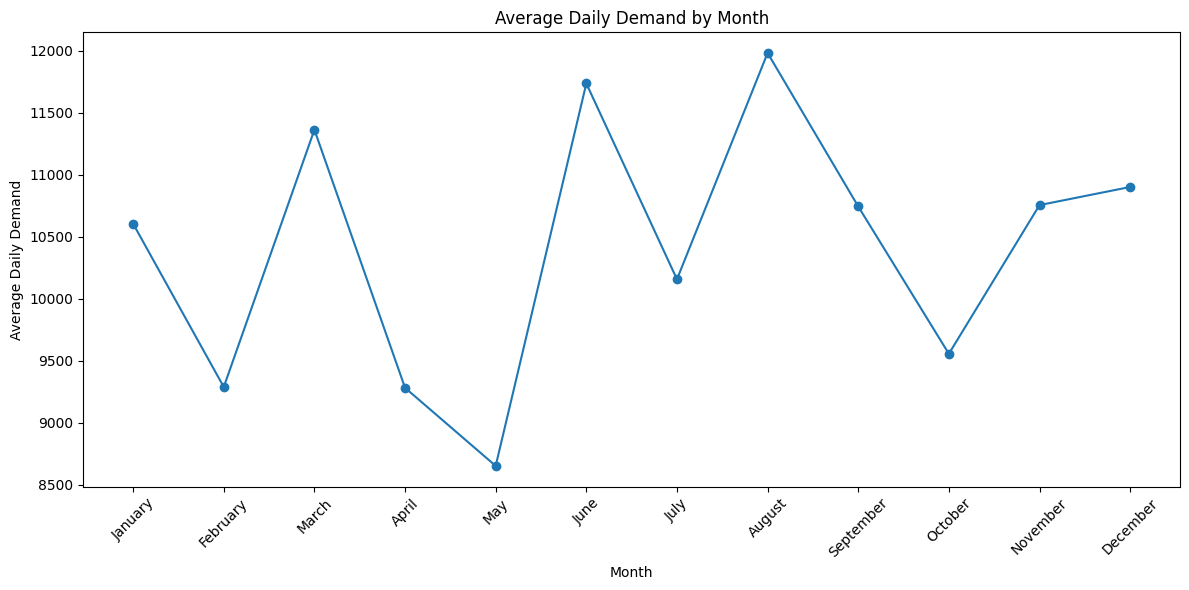

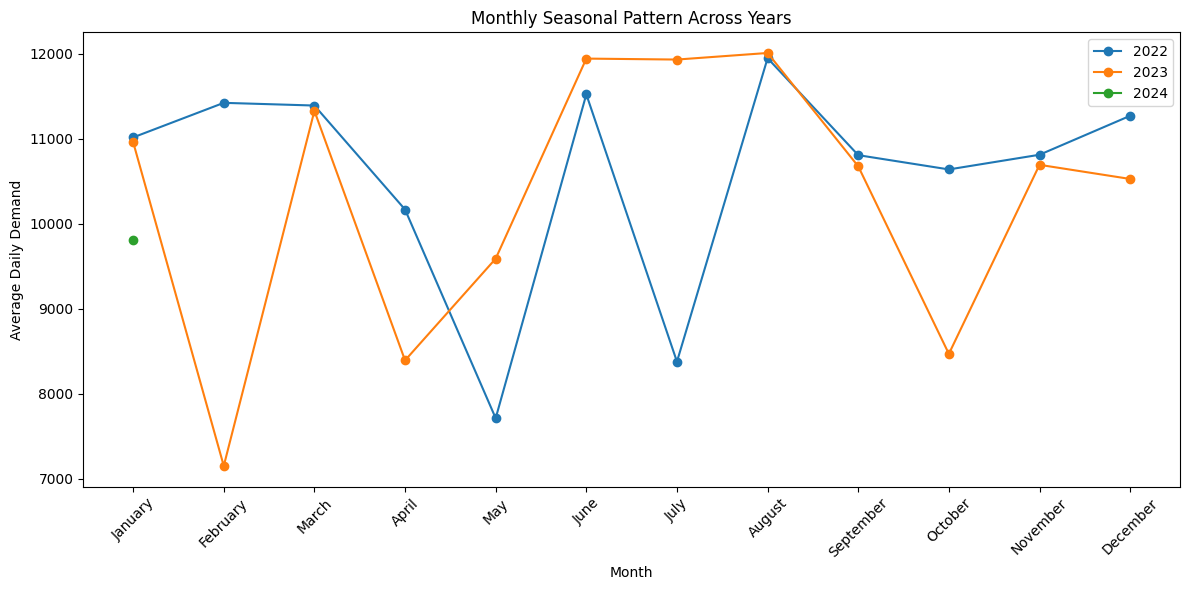

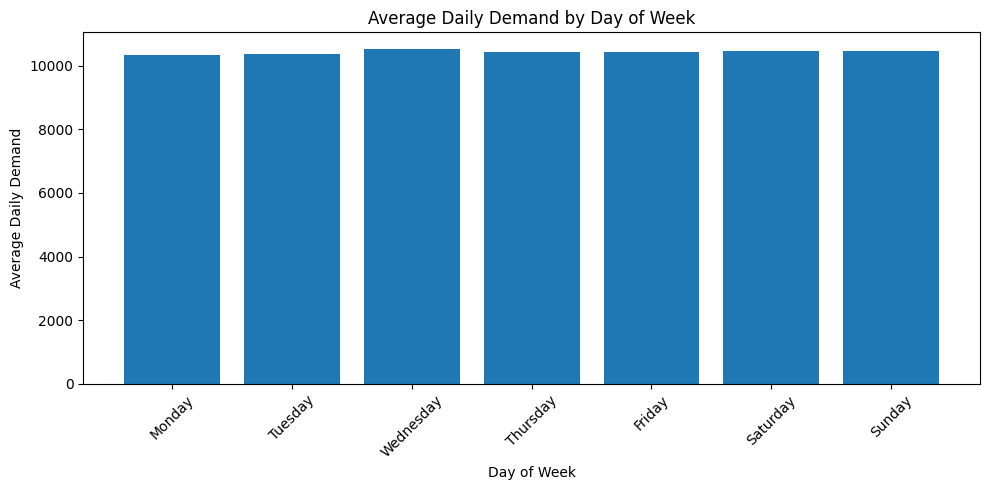


EDA 4.5 COMPLETE
No observations were removed or modified.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EDA 4.5 — SEASONALITY ANALYSIS
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df["Demand"] = pd.to_numeric(df["Demand"], errors="coerce")

# ------------------------------------------------------------
# 2. Aggregate to daily demand
# ------------------------------------------------------------
daily = (
    df.groupby("Date", as_index=False)["Demand"]
      .sum()
      .sort_values("Date")
)

# ------------------------------------------------------------
# 3. Create calendar features
# ------------------------------------------------------------
daily["Year"] = daily["Date"].dt.year
daily["Month"] = daily["Date"].dt.month
daily["Month_Name"] = daily["Date"].dt.month_name()
daily["Day_of_Week"] = daily["Date"].dt.dayofweek
daily["Day_Name"] = daily["Date"].dt.day_name()

# ------------------------------------------------------------
# 4. Month-of-year seasonality
# ------------------------------------------------------------
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_seasonality = (
    daily.groupby(["Month", "Month_Name"])["Demand"]
    .agg(
        mean_demand="mean",
        median_demand="median",
        std_demand="std",
        observations="count"
    )
    .reset_index()
)

monthly_seasonality["Month_Name"] = pd.Categorical(
    monthly_seasonality["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_seasonality = (
    monthly_seasonality
    .sort_values("Month")
)

# ------------------------------------------------------------
# 5. Year × Month comparison
# ------------------------------------------------------------
year_month = (
    daily.groupby(["Year", "Month"])["Demand"]
    .mean()
    .reset_index()
)

year_month["Month_Name"] = year_month["Month"].map(
    dict(enumerate(month_order, start=1))
)

# ------------------------------------------------------------
# 6. Day-of-week seasonality
# ------------------------------------------------------------
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_seasonality = (
    daily.groupby(["Day_of_Week", "Day_Name"])["Demand"]
    .agg(
        mean_demand="mean",
        median_demand="median",
        std_demand="std",
        observations="count"
    )
    .reset_index()
)

weekday_seasonality["Day_Name"] = pd.Categorical(
    weekday_seasonality["Day_Name"],
    categories=weekday_order,
    ordered=True
)

weekday_seasonality = (
    weekday_seasonality
    .sort_values("Day_of_Week")
)

# ------------------------------------------------------------
# 7. Print monthly seasonality
# ------------------------------------------------------------
print("=" * 70)
print("EDA 4.5 — SEASONALITY ANALYSIS")
print("=" * 70)

print("\n[1] MONTH-OF-YEAR AVERAGE DEMAND")
print("-" * 70)

print(
    monthly_seasonality[
        ["Month", "Month_Name", "mean_demand",
         "median_demand", "std_demand", "observations"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 8. Highest / lowest months
# ------------------------------------------------------------
print("\n[2] HIGHEST MONTHS BY AVERAGE DEMAND")
print("-" * 70)

print(
    monthly_seasonality
    .sort_values("mean_demand", ascending=False)
    .head(5)[
        ["Month_Name", "mean_demand", "observations"]
    ]
    .to_string(index=False)
)

print("\n[3] LOWEST MONTHS BY AVERAGE DEMAND")
print("-" * 70)

print(
    monthly_seasonality
    .sort_values("mean_demand", ascending=True)
    .head(5)[
        ["Month_Name", "mean_demand", "observations"]
    ]
    .to_string(index=False)
)

# ------------------------------------------------------------
# 9. Year × Month table
# ------------------------------------------------------------
print("\n[4] YEAR × MONTH AVERAGE DAILY DEMAND")
print("-" * 70)

pivot_year_month = year_month.pivot(
    index="Month_Name",
    columns="Year",
    values="Demand"
)

pivot_year_month = pivot_year_month.reindex(month_order)

print(pivot_year_month.round(2).to_string())

# ------------------------------------------------------------
# 10. Day-of-week seasonality
# ------------------------------------------------------------
print("\n[5] DAY-OF-WEEK AVERAGE DEMAND")
print("-" * 70)

print(
    weekday_seasonality[
        ["Day_Name", "mean_demand",
         "median_demand", "std_demand", "observations"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 11. Monthly seasonality plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality["Month_Name"],
    monthly_seasonality["mean_demand"],
    marker="o"
)

plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Year × Month seasonal comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

for year in sorted(year_month["Year"].unique()):
    temp = year_month[year_month["Year"] == year]

    plt.plot(
        temp["Month"],
        temp["Demand"],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Seasonal Pattern Across Years")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")

plt.xticks(
    range(1, 13),
    month_order,
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Day-of-week seasonality plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_seasonality["Day_Name"],
    weekday_seasonality["mean_demand"]
)

plt.title("Average Daily Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.5 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.6 — STORE-LEVEL ANALYSIS

[1] STORE DEMAND SUMMARY
----------------------------------------------------------------------
Store ID Region  total_demand  average_demand  median_demand  std_demand  minimum_demand  maximum_demand  observations       CV  demand_share_pct
    S002  South       1625471      106.938882          103.0   45.608125               4             351         15200 0.426488         20.502645
    S003   East       1618324      106.468684          102.0   47.424239               4             361         15200 0.445429         20.412497
    S005  North       1607085      105.729276          102.0   48.269190               4             430         15200 0.456536         20.270736
    S001  North       1547573      101.814013           98.0   47.131647               4             378         15200 0.462919         19.520090
    S004   West       1529651      100.634934           96.0   45.991886               4             370         15200 0.457017         19.294

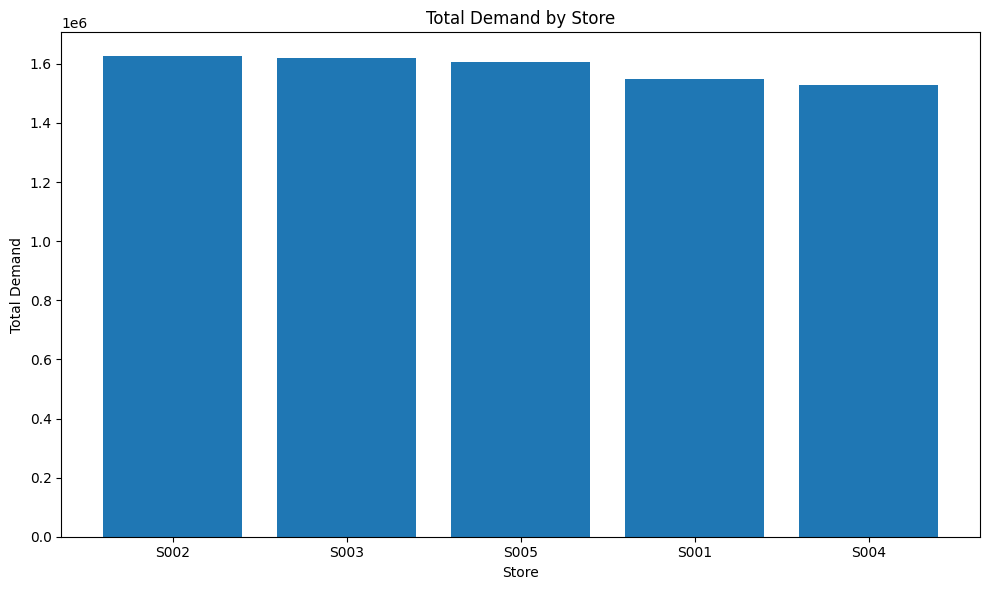

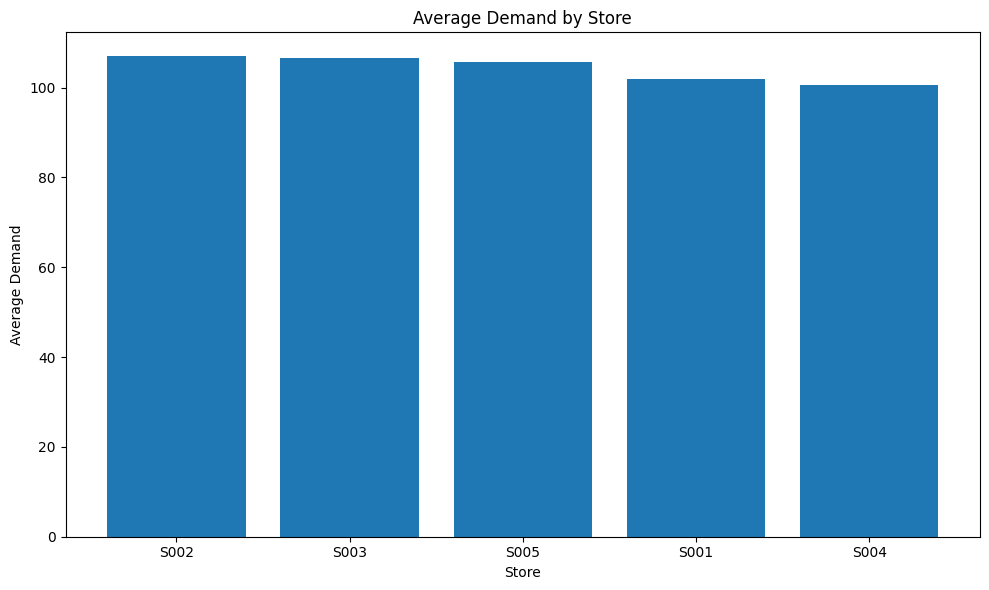

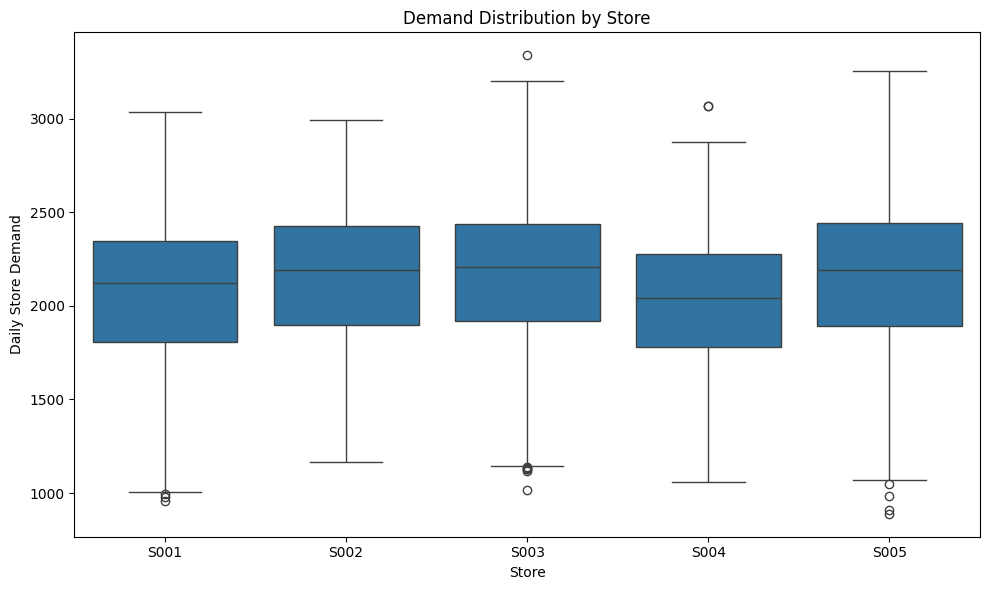

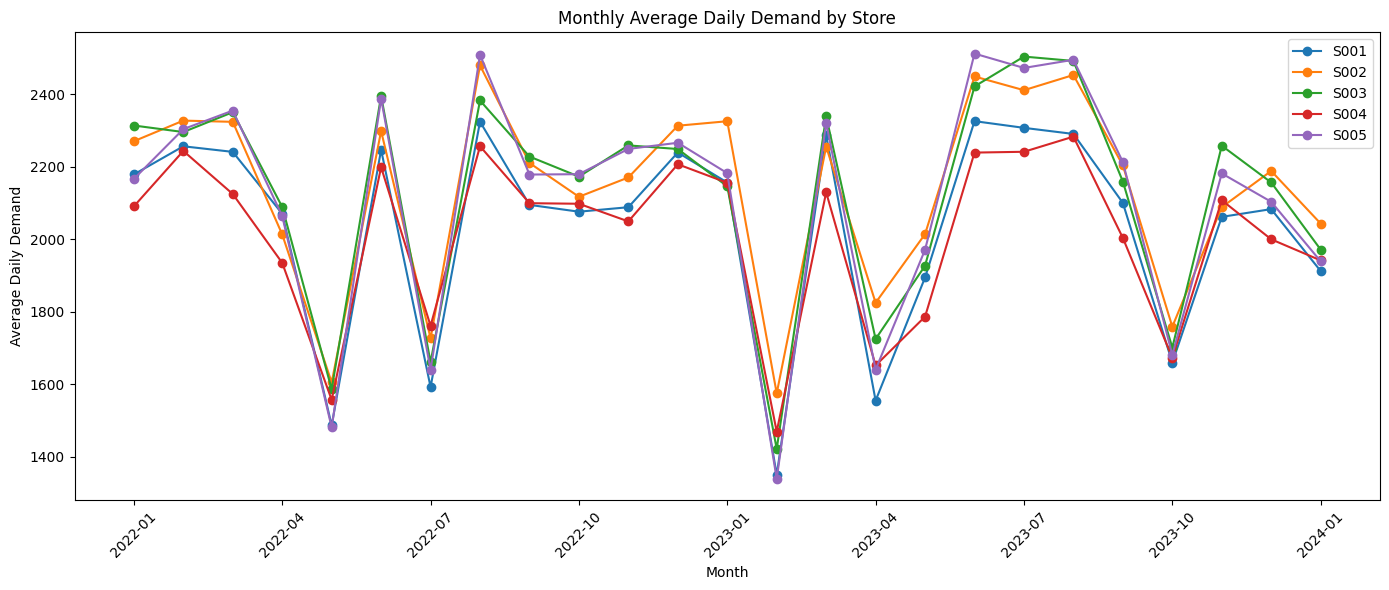


EDA 4.6 COMPLETE
No observations were removed or modified.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EDA 4.6 — STORE-LEVEL ANALYSIS
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df["Demand"] = pd.to_numeric(df["Demand"], errors="coerce")

# ------------------------------------------------------------
# 2. Store-level statistics
# ------------------------------------------------------------
store_stats = (
    df.groupby(["Store ID", "Region"])["Demand"]
    .agg(
        total_demand="sum",
        average_demand="mean",
        median_demand="median",
        std_demand="std",
        minimum_demand="min",
        maximum_demand="max",
        observations="count"
    )
    .reset_index()
)

store_stats["CV"] = (
    store_stats["std_demand"] /
    store_stats["average_demand"]
)

store_stats["demand_share_pct"] = (
    store_stats["total_demand"] /
    df["Demand"].sum() * 100
)

# ------------------------------------------------------------
# 3. Print store statistics
# ------------------------------------------------------------
print("=" * 70)
print("EDA 4.6 — STORE-LEVEL ANALYSIS")
print("=" * 70)

print("\n[1] STORE DEMAND SUMMARY")
print("-" * 70)

print(
    store_stats
    .sort_values("total_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 4. Highest and lowest average demand stores
# ------------------------------------------------------------
print("\n[2] STORE RANKING BY AVERAGE DEMAND")
print("-" * 70)

print(
    store_stats[
        ["Store ID", "Region", "average_demand", "CV"]
    ]
    .sort_values("average_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. Store demand contribution
# ------------------------------------------------------------
print("\n[3] STORE DEMAND CONTRIBUTION")
print("-" * 70)

print(
    store_stats[
        ["Store ID", "Region", "total_demand", "demand_share_pct"]
    ]
    .sort_values("total_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 6. Store × Date aggregation
# ------------------------------------------------------------
store_daily = (
    df.groupby(["Date", "Store ID"], as_index=False)["Demand"]
    .sum()
)

# ------------------------------------------------------------
# 7. Monthly store demand
# ------------------------------------------------------------
store_daily["YearMonth"] = store_daily["Date"].dt.to_period("M")

monthly_store = (
    store_daily
    .groupby(["YearMonth", "Store ID"])["Demand"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# 8. Store-level correlation
# ------------------------------------------------------------
store_pivot = store_daily.pivot(
    index="Date",
    columns="Store ID",
    values="Demand"
)

store_correlation = store_pivot.corr()

print("\n[4] STORE DEMAND CORRELATION")
print("-" * 70)

print(store_correlation.round(3).to_string())

# ------------------------------------------------------------
# 9. Store variability
# ------------------------------------------------------------
print("\n[5] STORE VARIABILITY")
print("-" * 70)

print(
    store_stats[
        ["Store ID", "Region", "average_demand",
         "std_demand", "CV", "minimum_demand",
         "maximum_demand"]
    ]
    .sort_values("CV", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 10. Total demand by store
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plot_data = store_stats.sort_values(
    "total_demand",
    ascending=False
)

plt.bar(
    plot_data["Store ID"],
    plot_data["total_demand"]
)

plt.title("Total Demand by Store")
plt.xlabel("Store")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Average demand by store
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plot_data = store_stats.sort_values(
    "average_demand",
    ascending=False
)

plt.bar(
    plot_data["Store ID"],
    plot_data["average_demand"]
)

plt.title("Average Demand by Store")
plt.xlabel("Store")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Store demand distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=store_daily,
    x="Store ID",
    y="Demand"
)

plt.title("Demand Distribution by Store")
plt.xlabel("Store")
plt.ylabel("Daily Store Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Monthly demand by store
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

for store in sorted(monthly_store["Store ID"].unique()):
    temp = monthly_store[
        monthly_store["Store ID"] == store
    ]

    plt.plot(
        temp["YearMonth"].astype(str),
        temp["Demand"],
        marker="o",
        label=store
    )

plt.title("Monthly Average Daily Demand by Store")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")

plt.xticks(
    ticks=np.arange(0, len(monthly_store["YearMonth"].unique()), 3),
    labels=sorted(
        monthly_store["YearMonth"]
        .astype(str)
        .unique()
    )[::3],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.6 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.7 — PRODUCT-LEVEL ANALYSIS

[1] PRODUCT DEMAND SUMMARY
----------------------------------------------------------------------
Product ID  total_demand  average_demand  median_demand  std_demand  minimum_demand  maximum_demand  observations       CV  demand_share_pct
     P0009        450324      118.506316          114.0   46.087811               4             338          3800 0.388906          5.680097
     P0013        440895      116.025000          112.0   49.937341               4             343          3800 0.430402          5.561166
     P0004        438505      115.396053          110.0   48.157642               4             351          3800 0.417325          5.531020
     P0007        437089      115.023421          111.0   48.938656               4             331          3800 0.425467          5.513159
     P0002        425853      112.066579          108.0   48.796185               4             370          3800 0.435421          5.371436
     P0010        4220

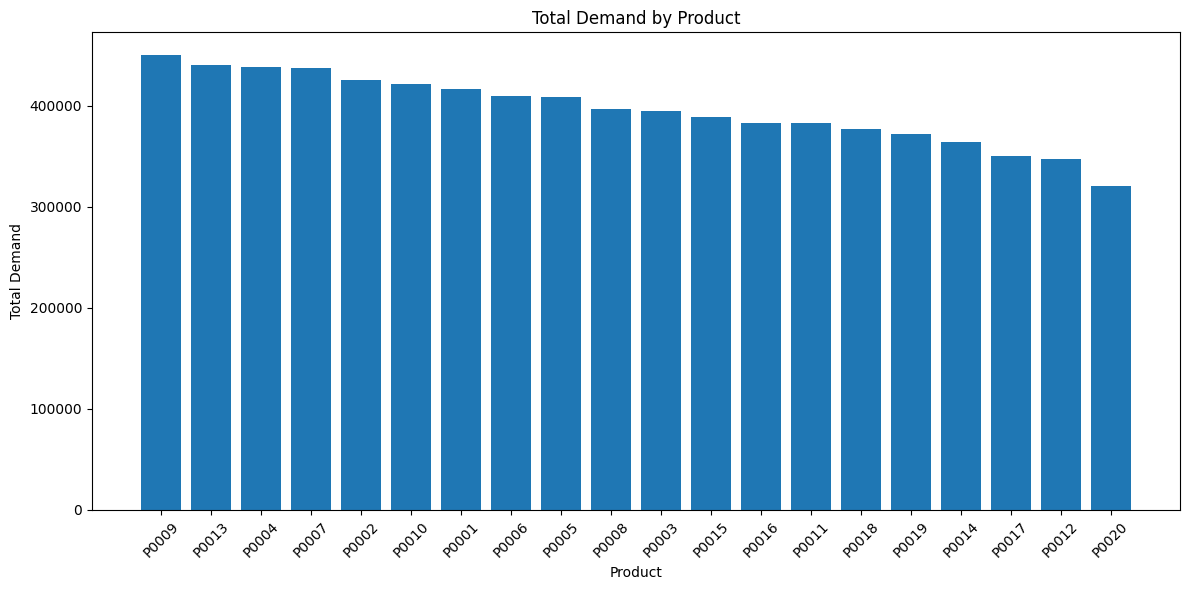

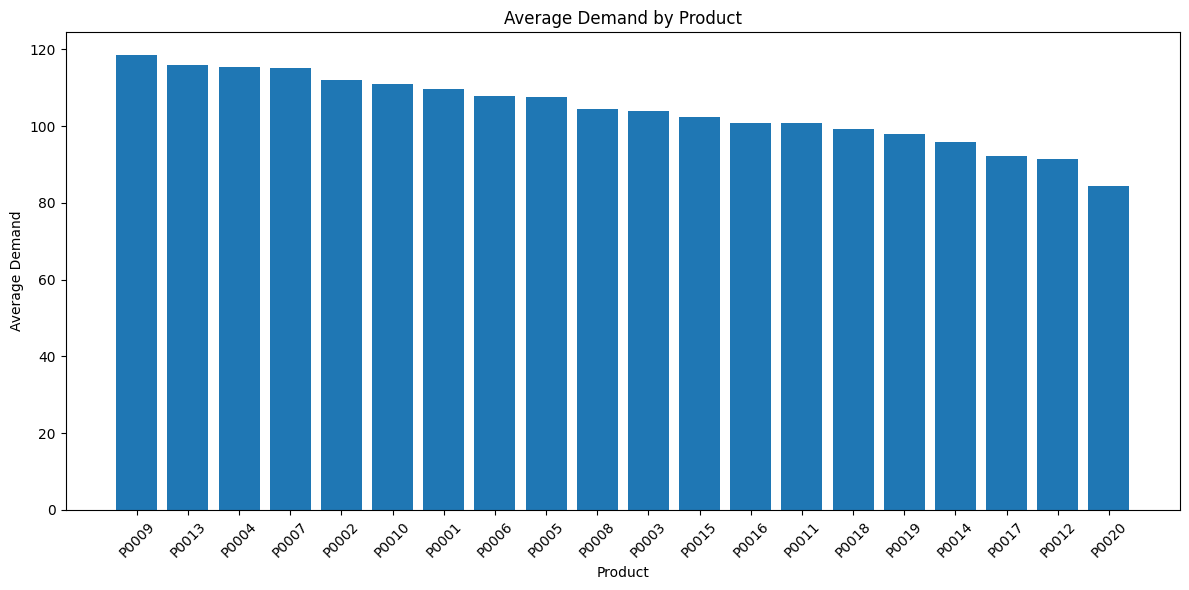

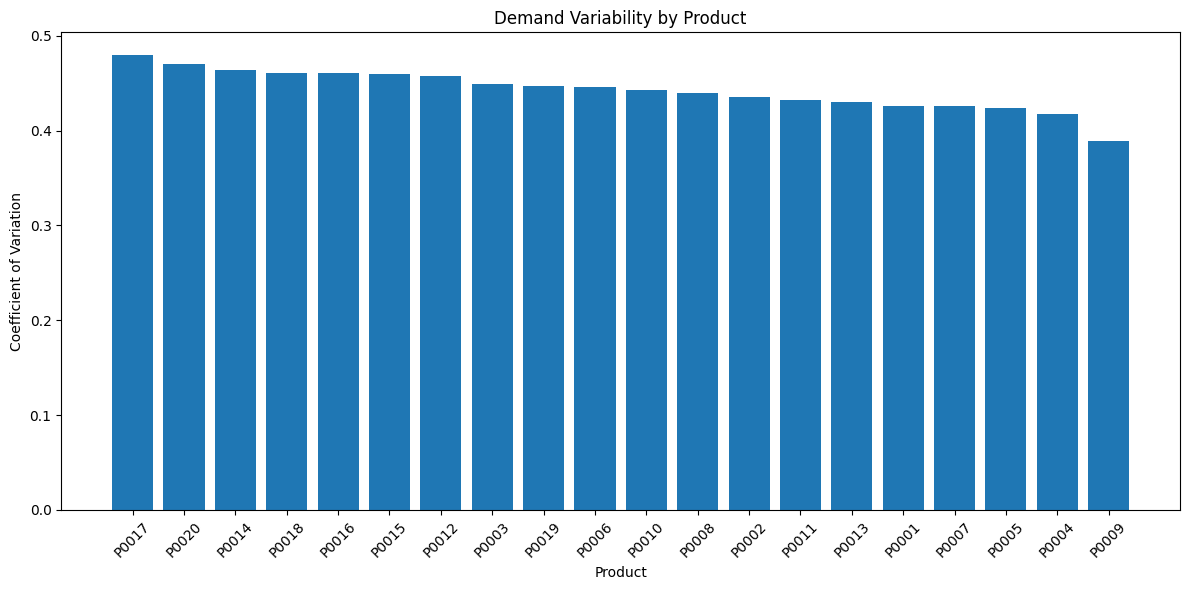

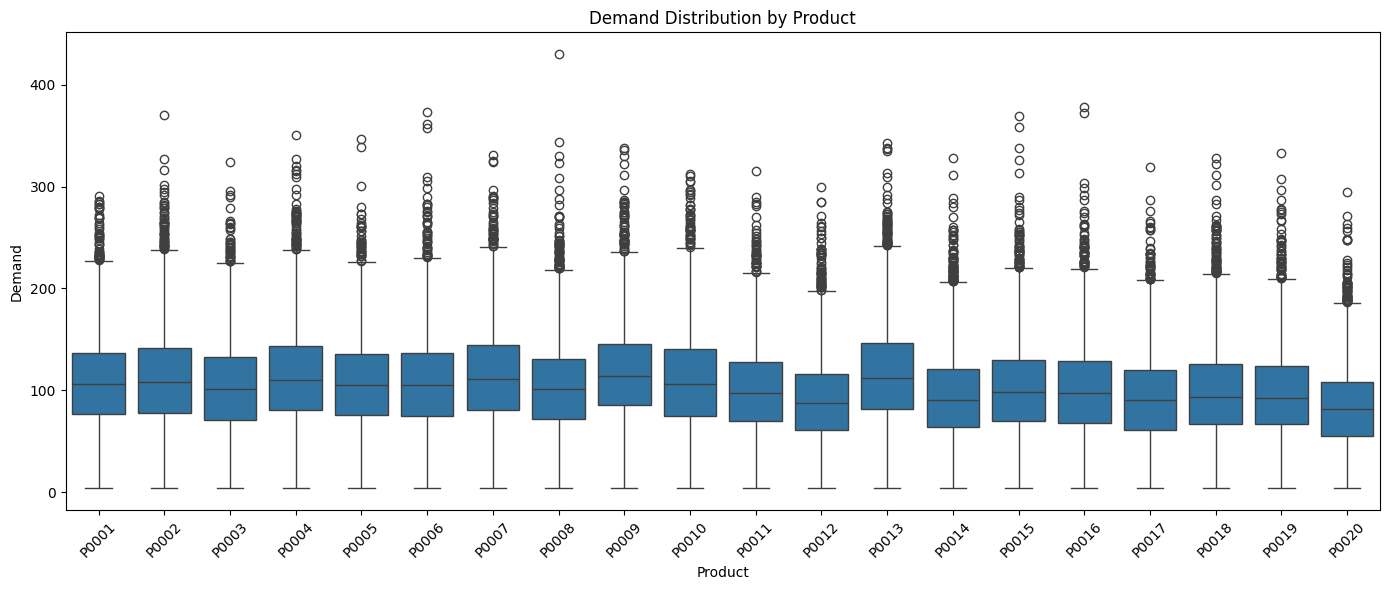


EDA 4.7 COMPLETE
No observations were removed or modified.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EDA 4.7 — PRODUCT-LEVEL ANALYSIS
# ============================================================

FILE_PATH = "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df["Demand"] = pd.to_numeric(df["Demand"], errors="coerce")

# ------------------------------------------------------------
# 2. Product-level statistics
# ------------------------------------------------------------
product_stats = (
    df.groupby("Product ID")["Demand"]
    .agg(
        total_demand="sum",
        average_demand="mean",
        median_demand="median",
        std_demand="std",
        minimum_demand="min",
        maximum_demand="max",
        observations="count"
    )
    .reset_index()
)

product_stats["CV"] = (
    product_stats["std_demand"] /
    product_stats["average_demand"]
)

product_stats["demand_share_pct"] = (
    product_stats["total_demand"] /
    df["Demand"].sum() * 100
)

# ------------------------------------------------------------
# 3. Print complete product summary
# ------------------------------------------------------------
print("=" * 70)
print("EDA 4.7 — PRODUCT-LEVEL ANALYSIS")
print("=" * 70)

print("\n[1] PRODUCT DEMAND SUMMARY")
print("-" * 70)

print(
    product_stats
    .sort_values("total_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 4. Highest-demand products
# ------------------------------------------------------------
print("\n[2] TOP 10 PRODUCTS BY TOTAL DEMAND")
print("-" * 70)

print(
    product_stats
    .sort_values("total_demand", ascending=False)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. Lowest-demand products
# ------------------------------------------------------------
print("\n[3] BOTTOM 10 PRODUCTS BY TOTAL DEMAND")
print("-" * 70)

print(
    product_stats
    .sort_values("total_demand", ascending=True)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 6. Most volatile products
# ------------------------------------------------------------
print("\n[4] TOP 10 PRODUCTS BY COEFFICIENT OF VARIATION")
print("-" * 70)

print(
    product_stats
    .sort_values("CV", ascending=False)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 7. Least volatile products
# ------------------------------------------------------------
print("\n[5] BOTTOM 10 PRODUCTS BY COEFFICIENT OF VARIATION")
print("-" * 70)

print(
    product_stats
    .sort_values("CV", ascending=True)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 8. Demand concentration
# ------------------------------------------------------------
sorted_products = product_stats.sort_values(
    "total_demand",
    ascending=False
).reset_index(drop=True)

sorted_products["cumulative_share_pct"] = (
    sorted_products["demand_share_pct"].cumsum()
)

print("\n[6] DEMAND CONCENTRATION")
print("-" * 70)

for n in [5, 10, 15, 20]:
    cumulative = sorted_products.iloc[:n]["demand_share_pct"].sum()
    print(f"Top {n:2} products: {cumulative:.2f}% of total demand")

# ------------------------------------------------------------
# 9. Product × Date demand
# ------------------------------------------------------------
product_daily = (
    df.groupby(["Date", "Product ID"], as_index=False)["Demand"]
    .sum()
)

# ------------------------------------------------------------
# 10. Product correlation
# ------------------------------------------------------------
product_pivot = product_daily.pivot(
    index="Date",
    columns="Product ID",
    values="Demand"
)

product_correlation = product_pivot.corr()

# Remove diagonal for finding strongest pair
corr_matrix = product_correlation.copy()

np.fill_diagonal(
    corr_matrix.values,
    np.nan
)

strongest_pair = (
    corr_matrix
    .stack()
    .sort_values(ascending=False)
    .head(1)
)

weakest_pair = (
    corr_matrix
    .stack()
    .sort_values(ascending=True)
    .head(1)
)

print("\n[7] PRODUCT DEMAND CORRELATION")
print("-" * 70)

print(
    f"Highest product-pair correlation: "
    f"{strongest_pair.iloc[0]:.3f}"
)

print(strongest_pair)

print(
    f"\nLowest product-pair correlation: "
    f"{weakest_pair.iloc[0]:.3f}"
)

print(weakest_pair)

# ------------------------------------------------------------
# 11. Total demand by product
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plot_data = product_stats.sort_values(
    "total_demand",
    ascending=False
)

plt.bar(
    plot_data["Product ID"],
    plot_data["total_demand"]
)

plt.title("Total Demand by Product")
plt.xlabel("Product")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Average demand by product
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plot_data = product_stats.sort_values(
    "average_demand",
    ascending=False
)

plt.bar(
    plot_data["Product ID"],
    plot_data["average_demand"]
)

plt.title("Average Demand by Product")
plt.xlabel("Product")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Product variability
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plot_data = product_stats.sort_values(
    "CV",
    ascending=False
)

plt.bar(
    plot_data["Product ID"],
    plot_data["CV"]
)

plt.title("Demand Variability by Product")
plt.xlabel("Product")
plt.ylabel("Coefficient of Variation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Product demand distribution
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Product ID",
    y="Demand"
)

plt.title("Demand Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.7 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.8 — CATEGORY-LEVEL ANALYSIS

[1] CATEGORY DEMAND SUMMARY
----------------------------------------------------------------------
   Category  total_demand  average_demand  median_demand  std_demand  minimum_demand  maximum_demand  observations       CV  demand_share_pct
  Groceries       3677684      120.976447          116.0   48.362730               4             430         30400 0.399770         46.387938
   Clothing       1369456      112.619737          109.0   41.022968               4             330         12160 0.364261         17.273436
  Furniture       1006590       73.581140           72.0   32.336141               4             214         13680 0.439462         12.696478
       Toys        985338       92.606955           92.0   46.170390               4             361         10640 0.498563         12.428419
Electronics        889036       97.482018           95.0   40.557859               4             339          9120 0.416055         11.213728

[2] CATEGORY 

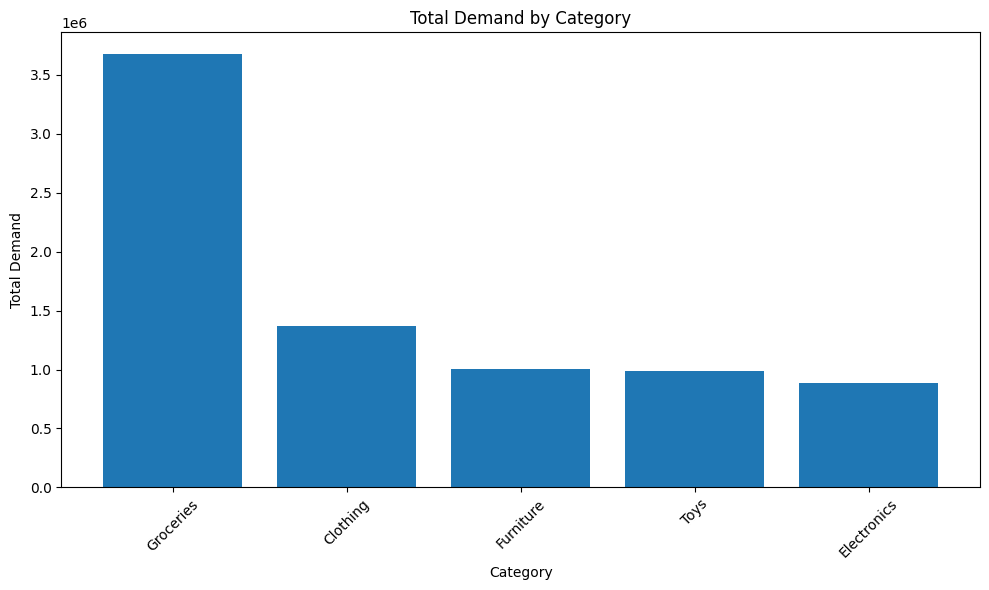

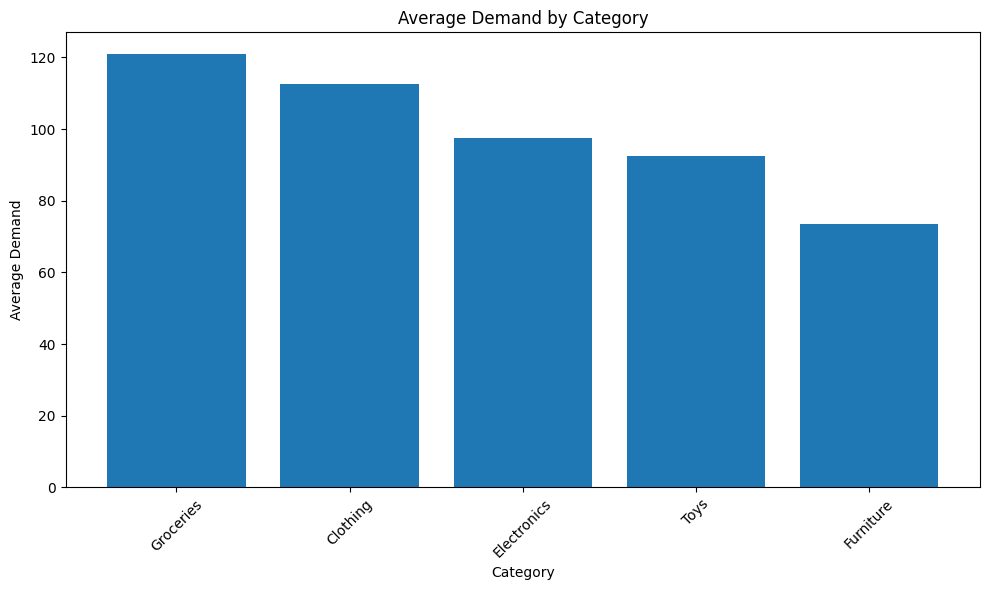

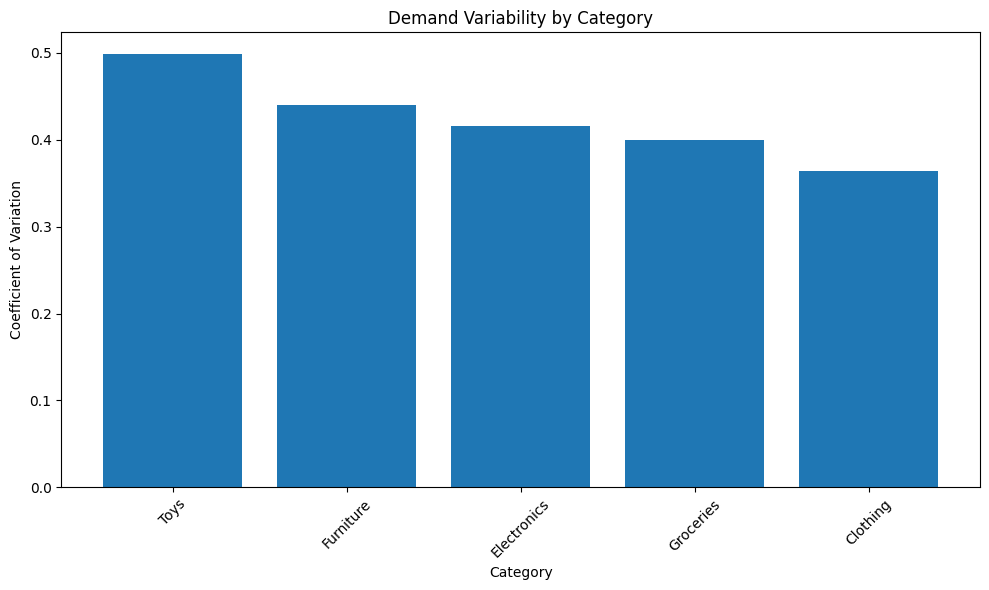

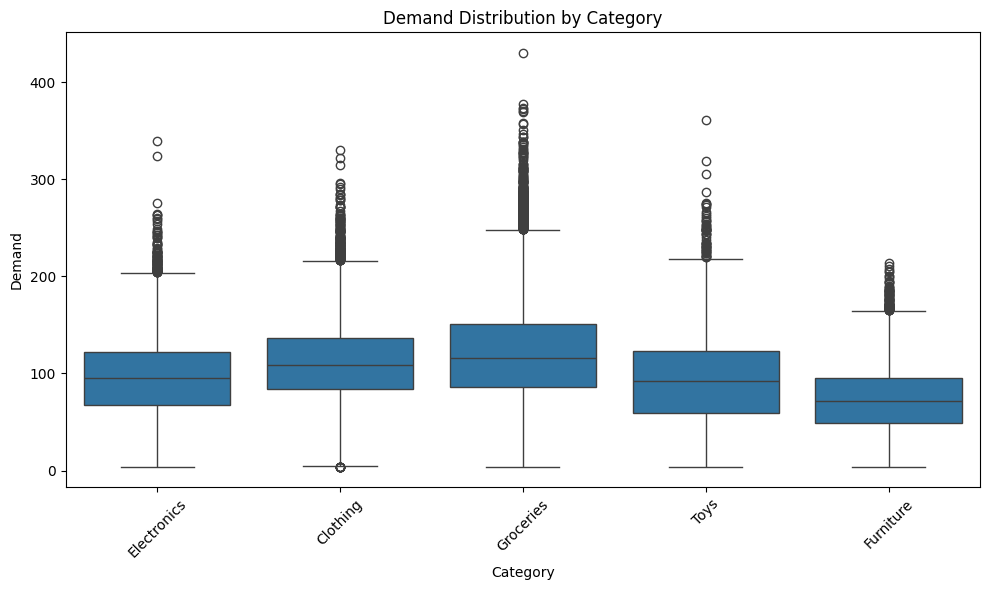

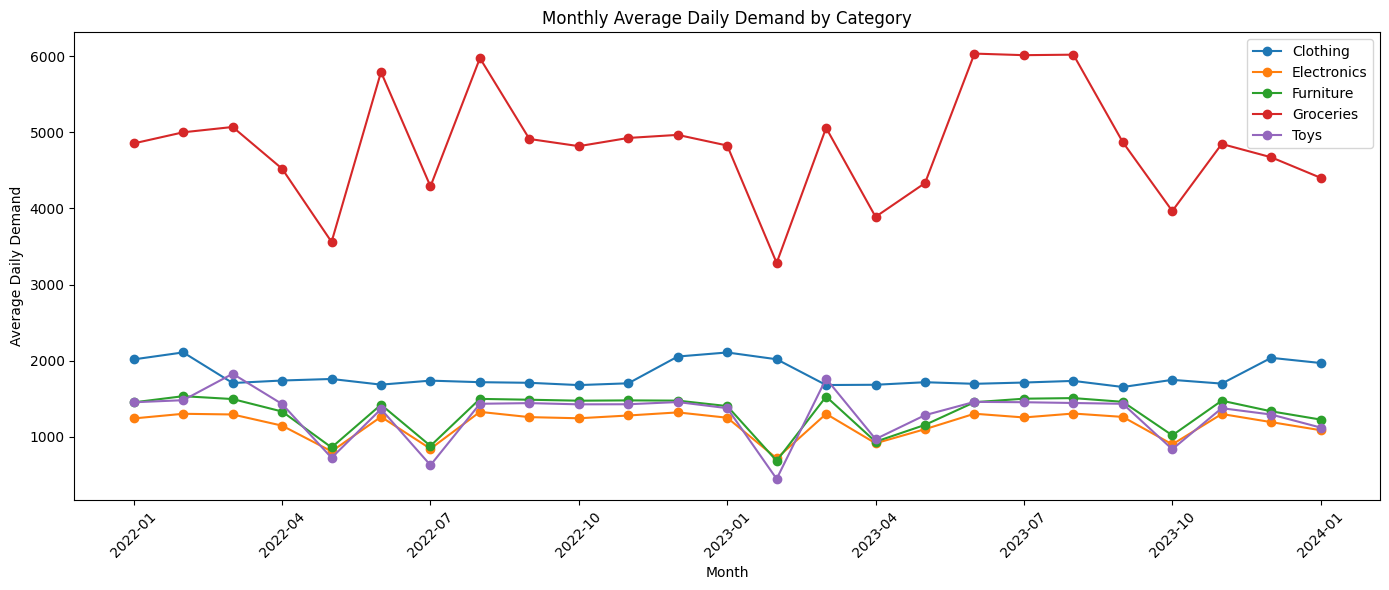


EDA 4.8 COMPLETE
No observations were removed or modified.


In [9]:
# ============================================================
# EDA 4.8 — CATEGORY-LEVEL ANALYSIS
# ============================================================

print("=" * 70)
print("EDA 4.8 — CATEGORY-LEVEL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Category-level statistics
# ------------------------------------------------------------
category_stats = (
    df.groupby("Category")["Demand"]
    .agg(
        total_demand="sum",
        average_demand="mean",
        median_demand="median",
        std_demand="std",
        minimum_demand="min",
        maximum_demand="max",
        observations="count"
    )
    .reset_index()
)

# Coefficient of Variation
category_stats["CV"] = (
    category_stats["std_demand"] /
    category_stats["average_demand"]
)

# Percentage contribution to total demand
category_stats["demand_share_pct"] = (
    category_stats["total_demand"] /
    df["Demand"].sum() * 100
)

# ------------------------------------------------------------
# 2. Category demand summary
# ------------------------------------------------------------
print("\n[1] CATEGORY DEMAND SUMMARY")
print("-" * 70)

print(
    category_stats
    .sort_values("total_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 3. Category demand contribution
# ------------------------------------------------------------
print("\n[2] CATEGORY DEMAND CONTRIBUTION")
print("-" * 70)

print(
    category_stats[
        [
            "Category",
            "total_demand",
            "demand_share_pct"
        ]
    ]
    .sort_values("total_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 4. Category variability
# ------------------------------------------------------------
print("\n[3] CATEGORY VARIABILITY")
print("-" * 70)

print(
    category_stats[
        [
            "Category",
            "average_demand",
            "std_demand",
            "CV",
            "minimum_demand",
            "maximum_demand"
        ]
    ]
    .sort_values("CV", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. Number of products in each category
# ------------------------------------------------------------
category_products = (
    df[["Category", "Product ID"]]
    .drop_duplicates()
    .groupby("Category")["Product ID"]
    .nunique()
    .reset_index(name="unique_products")
)

print("\n[4] PRODUCTS PER CATEGORY")
print("-" * 70)

print(
    category_products
    .sort_values("unique_products", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 6. Category × Date demand
# ------------------------------------------------------------
category_daily = (
    df.groupby(
        ["Date", "Category"],
        as_index=False
    )["Demand"]
    .sum()
)

# ------------------------------------------------------------
# 7. Category demand correlation
# ------------------------------------------------------------
category_pivot = category_daily.pivot(
    index="Date",
    columns="Category",
    values="Demand"
)

category_correlation = category_pivot.corr()

print("\n[5] CATEGORY DEMAND CORRELATION")
print("-" * 70)

print(
    category_correlation
    .round(3)
    .to_string()
)

# ------------------------------------------------------------
# 8. Find strongest and weakest category relationships
# ------------------------------------------------------------
corr_matrix = category_correlation.copy()

np.fill_diagonal(
    corr_matrix.values,
    np.nan
)

category_pairs = (
    corr_matrix
    .stack()
    .sort_values(ascending=False)
)

print("\n[6] CATEGORY CORRELATION RANGE")
print("-" * 70)

print(
    f"Highest category correlation : "
    f"{category_pairs.iloc[0]:.3f}"
)

print(
    f"Lowest category correlation  : "
    f"{category_pairs.iloc[-1]:.3f}"
)

# ------------------------------------------------------------
# 9. Monthly category demand
# ------------------------------------------------------------
category_daily["YearMonth"] = (
    category_daily["Date"].dt.to_period("M")
)

monthly_category = (
    category_daily
    .groupby(
        ["YearMonth", "Category"]
    )["Demand"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# 10. Total demand by category
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plot_data = category_stats.sort_values(
    "total_demand",
    ascending=False
)

plt.bar(
    plot_data["Category"],
    plot_data["total_demand"]
)

plt.title("Total Demand by Category")
plt.xlabel("Category")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Average demand by category
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plot_data = category_stats.sort_values(
    "average_demand",
    ascending=False
)

plt.bar(
    plot_data["Category"],
    plot_data["average_demand"]
)

plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Category variability
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plot_data = category_stats.sort_values(
    "CV",
    ascending=False
)

plt.bar(
    plot_data["Category"],
    plot_data["CV"]
)

plt.title("Demand Variability by Category")
plt.xlabel("Category")
plt.ylabel("Coefficient of Variation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Category demand distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Demand"
)

plt.title("Demand Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Monthly average daily demand by category
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

for category in sorted(
    monthly_category["Category"].unique()
):

    temp = monthly_category[
        monthly_category["Category"] == category
    ].sort_values("YearMonth")

    plt.plot(
        temp["YearMonth"].astype(str),
        temp["Demand"],
        marker="o",
        label=category
    )

months = sorted(
    monthly_category["YearMonth"]
    .astype(str)
    .unique()
)

plt.title("Monthly Average Daily Demand by Category")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")

plt.xticks(
    ticks=np.arange(0, len(months), 3),
    labels=months[::3],
    rotation=45
)

plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.8 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.9 — PROMOTION ANALYSIS

[1] PROMOTION FREQUENCY
----------------------------------------------------------------------
Promotion = 0 : 51,000 rows (67.11%)
Promotion = 1 : 25,000 rows (32.89%)

[2] DEMAND WITH VS WITHOUT PROMOTION
----------------------------------------------------------------------
 Promotion  observations  total_demand  average_demand  median_demand  std_demand  minimum_demand  maximum_demand
         0         51000       4846369       95.026843           92.0   40.654269               4             330
         1         25000       3081735      123.269400          120.0   52.900712               4             430

[3] PROMOTION DEMAND DIFFERENCE
----------------------------------------------------------------------
Average demand with promotion    : 123.27
Average demand without promotion : 95.03
Absolute difference              : 28.24
Percentage difference            : 29.72%

[4] STORE-LEVEL PROMOTION COMPARISON
------------------------------------------

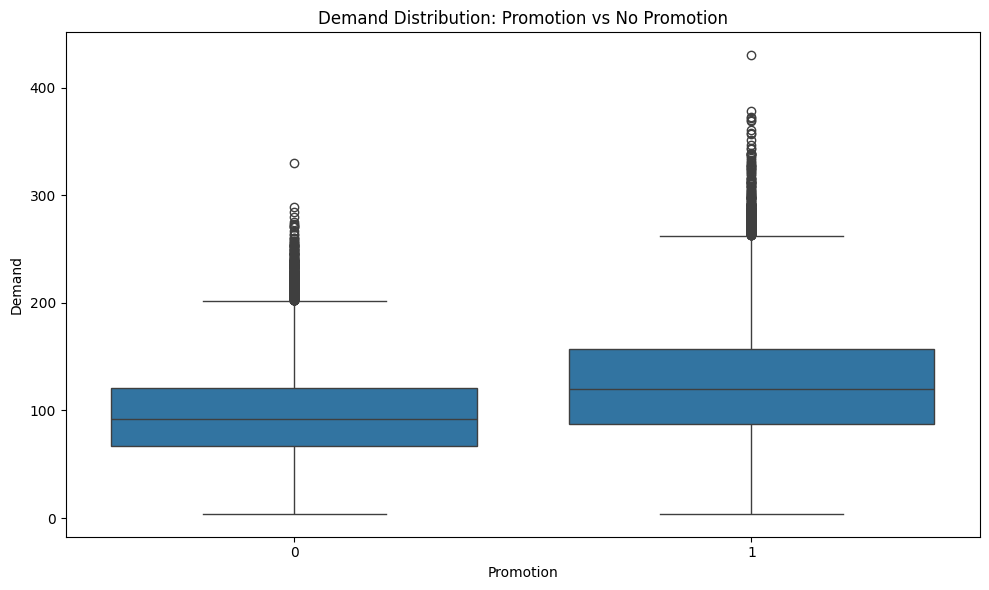

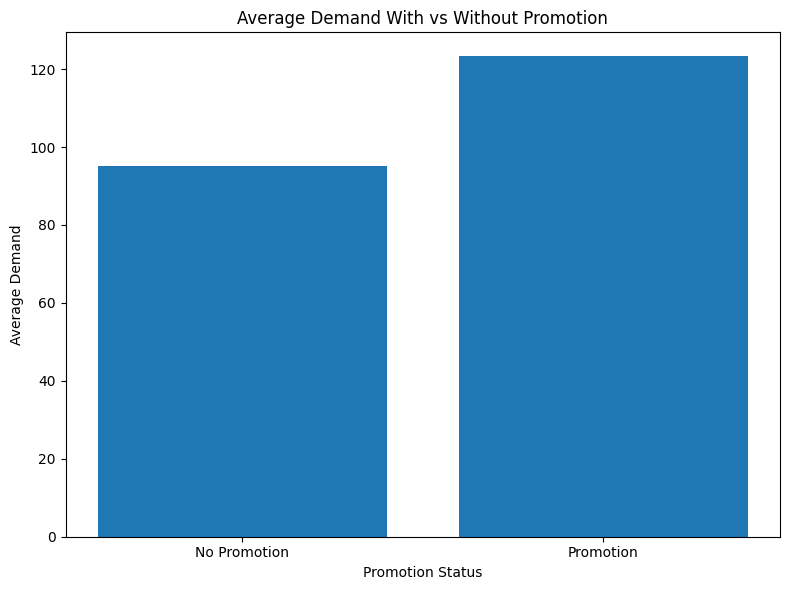

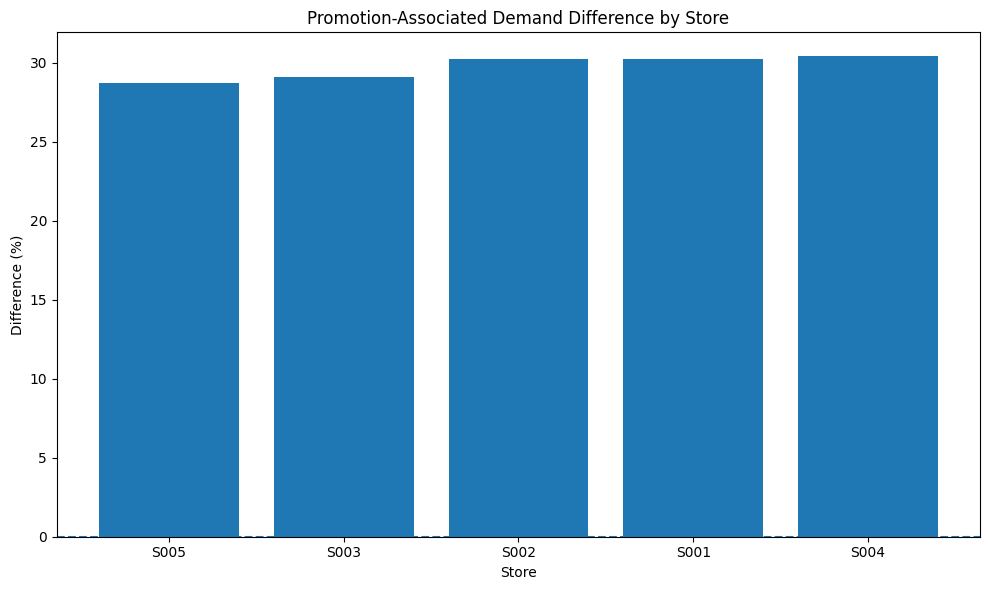

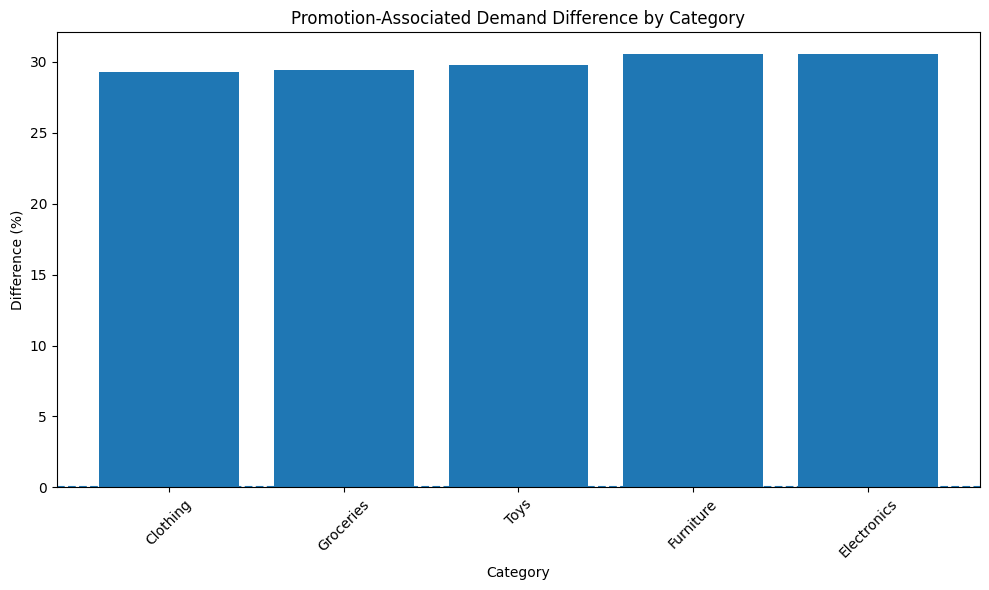

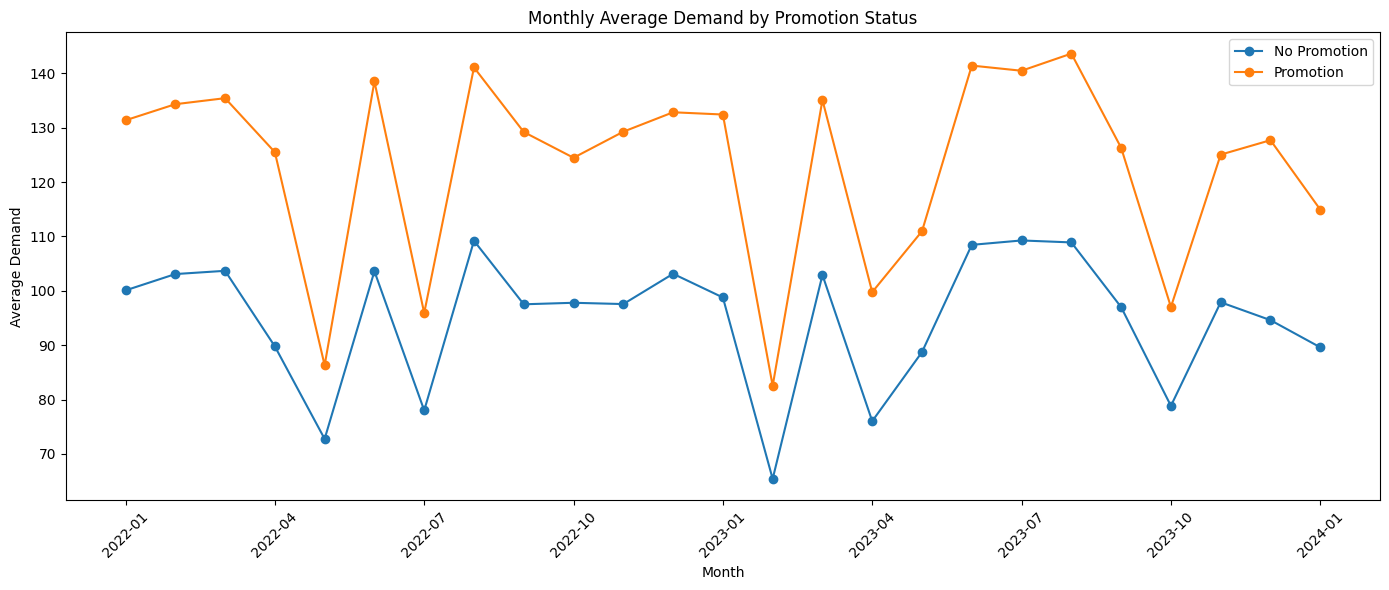


EDA 4.9 COMPLETE
No observations were removed or modified.


In [10]:
# ============================================================
# EDA 4.9 — PROMOTION ANALYSIS
# ============================================================

print("=" * 70)
print("EDA 4.9 — PROMOTION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Promotion frequency
# ------------------------------------------------------------
promotion_counts = (
    df["Promotion"]
    .value_counts()
    .sort_index()
)

promotion_pct = (
    df["Promotion"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n[1] PROMOTION FREQUENCY")
print("-" * 70)

for value in sorted(df["Promotion"].dropna().unique()):
    print(
        f"Promotion = {int(value)} : "
        f"{promotion_counts.get(value, 0):,} rows "
        f"({promotion_pct.get(value, 0):.2f}%)"
    )

# ------------------------------------------------------------
# 2. Overall demand with vs without promotion
# ------------------------------------------------------------
promotion_stats = (
    df.groupby("Promotion")["Demand"]
    .agg(
        observations="count",
        total_demand="sum",
        average_demand="mean",
        median_demand="median",
        std_demand="std",
        minimum_demand="min",
        maximum_demand="max"
    )
    .reset_index()
)

print("\n[2] DEMAND WITH VS WITHOUT PROMOTION")
print("-" * 70)

print(
    promotion_stats.to_string(index=False)
)

# ------------------------------------------------------------
# 3. Difference in average demand
# ------------------------------------------------------------
promo_mean = (
    df.loc[df["Promotion"] == 1, "Demand"]
    .mean()
)

nonpromo_mean = (
    df.loc[df["Promotion"] == 0, "Demand"]
    .mean()
)

absolute_difference = promo_mean - nonpromo_mean

percentage_difference = (
    absolute_difference /
    nonpromo_mean * 100
)

print("\n[3] PROMOTION DEMAND DIFFERENCE")
print("-" * 70)

print(f"Average demand with promotion    : {promo_mean:.2f}")
print(f"Average demand without promotion : {nonpromo_mean:.2f}")
print(f"Absolute difference              : {absolute_difference:.2f}")
print(f"Percentage difference            : {percentage_difference:.2f}%")

# ------------------------------------------------------------
# 4. Store-level promotion comparison
# ------------------------------------------------------------
store_promotion = (
    df.groupby(
        ["Store ID", "Promotion"]
    )["Demand"]
    .mean()
    .reset_index()
)

store_promotion_pivot = (
    store_promotion
    .pivot(
        index="Store ID",
        columns="Promotion",
        values="Demand"
    )
    .rename(
        columns={
            0: "No_Promotion",
            1: "Promotion"
        }
    )
)

if "No_Promotion" in store_promotion_pivot.columns and \
   "Promotion" in store_promotion_pivot.columns:

    store_promotion_pivot["Difference"] = (
        store_promotion_pivot["Promotion"] -
        store_promotion_pivot["No_Promotion"]
    )

    store_promotion_pivot["Difference_Pct"] = (
        store_promotion_pivot["Difference"] /
        store_promotion_pivot["No_Promotion"] * 100
    )

print("\n[4] STORE-LEVEL PROMOTION COMPARISON")
print("-" * 70)

print(
    store_promotion_pivot
    .round(2)
    .to_string()
)

# ------------------------------------------------------------
# 5. Category-level promotion comparison
# ------------------------------------------------------------
category_promotion = (
    df.groupby(
        ["Category", "Promotion"]
    )["Demand"]
    .mean()
    .reset_index()
)

category_promotion_pivot = (
    category_promotion
    .pivot(
        index="Category",
        columns="Promotion",
        values="Demand"
    )
    .rename(
        columns={
            0: "No_Promotion",
            1: "Promotion"
        }
    )
)

if "No_Promotion" in category_promotion_pivot.columns and \
   "Promotion" in category_promotion_pivot.columns:

    category_promotion_pivot["Difference"] = (
        category_promotion_pivot["Promotion"] -
        category_promotion_pivot["No_Promotion"]
    )

    category_promotion_pivot["Difference_Pct"] = (
        category_promotion_pivot["Difference"] /
        category_promotion_pivot["No_Promotion"] * 100
    )

print("\n[5] CATEGORY-LEVEL PROMOTION COMPARISON")
print("-" * 70)

print(
    category_promotion_pivot
    .round(2)
    .to_string()
)

# ------------------------------------------------------------
# 6. Promotion by month
# ------------------------------------------------------------
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_promotion = (
    df.groupby(
        ["YearMonth", "Promotion"]
    )["Demand"]
    .mean()
    .reset_index()
)

monthly_promotion_pivot = (
    monthly_promotion
    .pivot(
        index="YearMonth",
        columns="Promotion",
        values="Demand"
    )
    .rename(
        columns={
            0: "No_Promotion",
            1: "Promotion"
        }
    )
)

print("\n[6] MONTHLY PROMOTION DEMAND")
print("-" * 70)

print(
    monthly_promotion_pivot
    .round(2)
    .to_string()
)

# ------------------------------------------------------------
# 7. Promotion demand distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Promotion",
    y="Demand"
)

plt.title("Demand Distribution: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Average demand comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plot_data = (
    promotion_stats
    .copy()
)

labels = ["No Promotion", "Promotion"]

values = []

for value in [0, 1]:
    row = plot_data[
        plot_data["Promotion"] == value
    ]

    if len(row) > 0:
        values.append(
            row["average_demand"].iloc[0]
        )
    else:
        values.append(0)

plt.bar(
    labels,
    values
)

plt.title("Average Demand With vs Without Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Store-level promotion effect
# ------------------------------------------------------------
if "Difference_Pct" in store_promotion_pivot.columns:

    plt.figure(figsize=(10, 6))

    plot_data = (
        store_promotion_pivot
        .sort_values("Difference_Pct")
    )

    plt.bar(
        plot_data.index,
        plot_data["Difference_Pct"]
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.title(
        "Promotion-Associated Demand Difference by Store"
    )

    plt.xlabel("Store")
    plt.ylabel("Difference (%)")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 10. Category-level promotion effect
# ------------------------------------------------------------
if "Difference_Pct" in category_promotion_pivot.columns:

    plt.figure(figsize=(10, 6))

    plot_data = (
        category_promotion_pivot
        .sort_values("Difference_Pct")
    )

    plt.bar(
        plot_data.index,
        plot_data["Difference_Pct"]
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.title(
        "Promotion-Associated Demand Difference by Category"
    )

    plt.xlabel("Category")
    plt.ylabel("Difference (%)")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 11. Monthly promotion comparison
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

if "No_Promotion" in monthly_promotion_pivot.columns:

    plt.plot(
        monthly_promotion_pivot.index.astype(str),
        monthly_promotion_pivot["No_Promotion"],
        marker="o",
        label="No Promotion"
    )

if "Promotion" in monthly_promotion_pivot.columns:

    plt.plot(
        monthly_promotion_pivot.index.astype(str),
        monthly_promotion_pivot["Promotion"],
        marker="o",
        label="Promotion"
    )

months = monthly_promotion_pivot.index.astype(str).tolist()

plt.title("Monthly Average Demand by Promotion Status")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.xticks(
    ticks=np.arange(0, len(months), 3),
    labels=months[::3],
    rotation=45
)

plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EDA 4.9 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.10 — PRICE, DISCOUNT & COMPETITOR PRICING ANALYSIS

[1] PRICE SUMMARY
----------------------------------------------------------------------
count    76000.000000
mean        67.726028
std         39.377899
min          4.740000
25%         31.997500
50%         64.500000
75%         95.830000
max        228.030000

Price skewness : 0.4850
Price kurtosis : -0.4839

[2] COMPETITOR PRICING SUMMARY
----------------------------------------------------------------------
count    76000.000000
mean        69.454029
std         40.943818
min          4.290000
25%         32.620000
50%         65.700000
75%         97.932500
max        261.220000

Competitor Pricing skewness : 0.5490
Competitor Pricing kurtosis : -0.3097

[3] DISCOUNT SUMMARY
----------------------------------------------------------------------
count    76000.000000
mean         9.087039
std          7.475781
min          0.000000
25%          5.000000
50%         10.000000
75%         10.000000
max         25.000000

Di

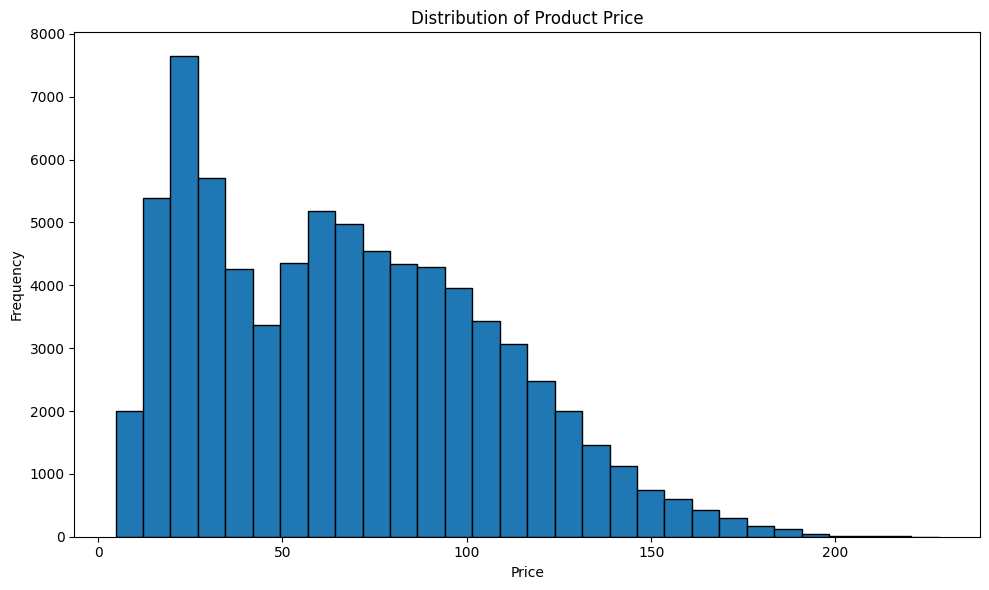

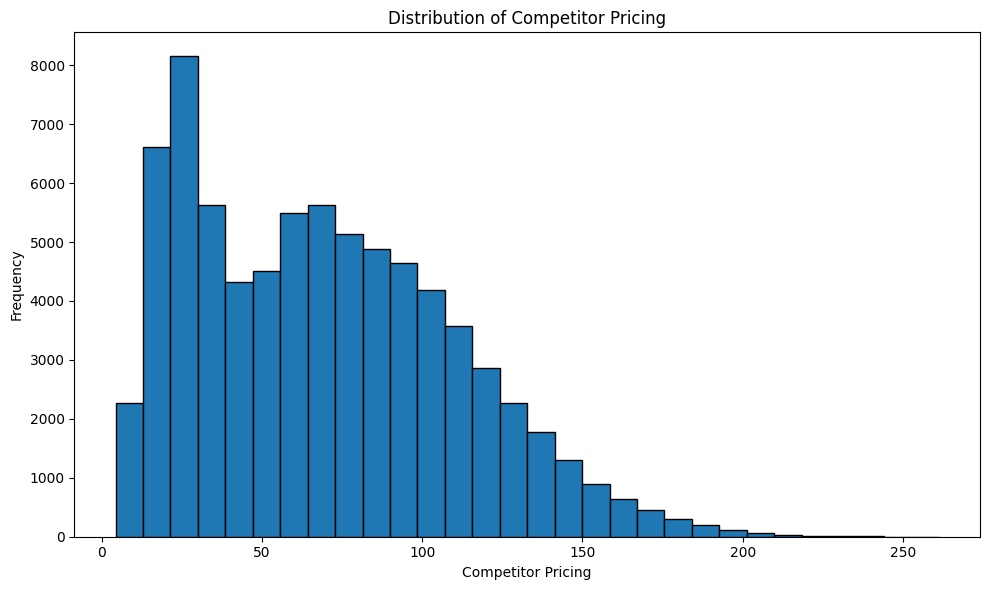

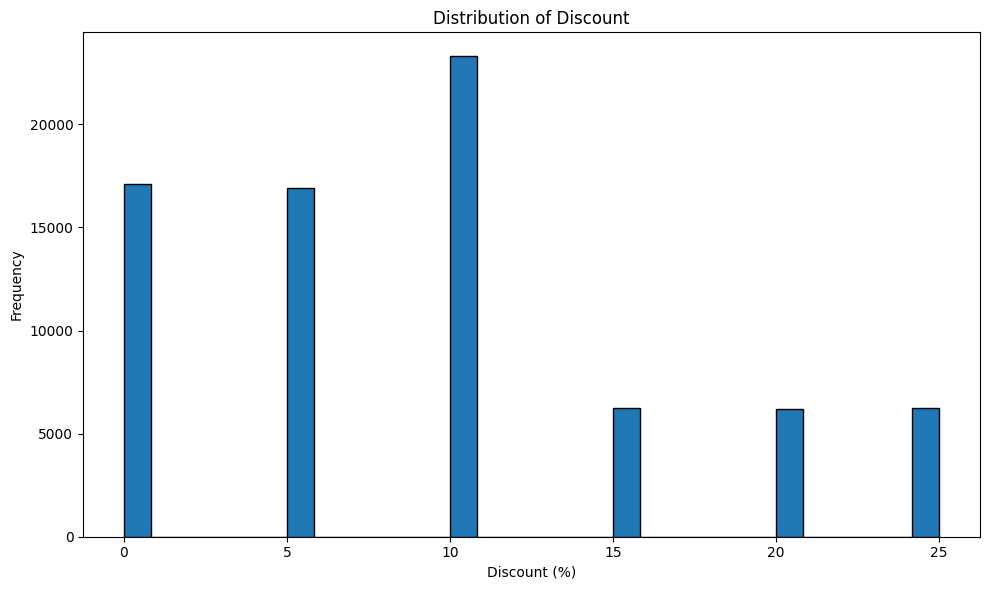

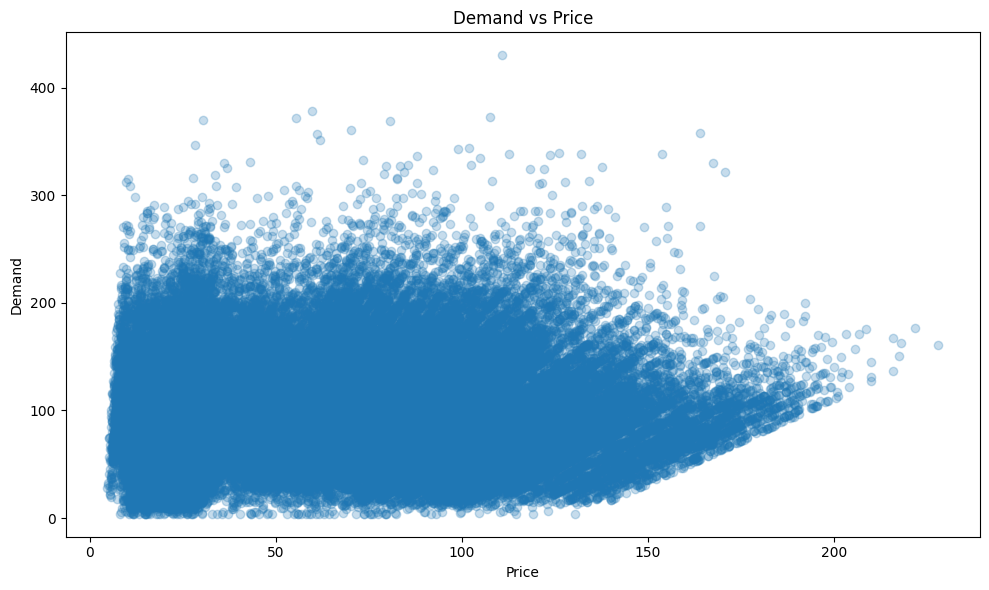

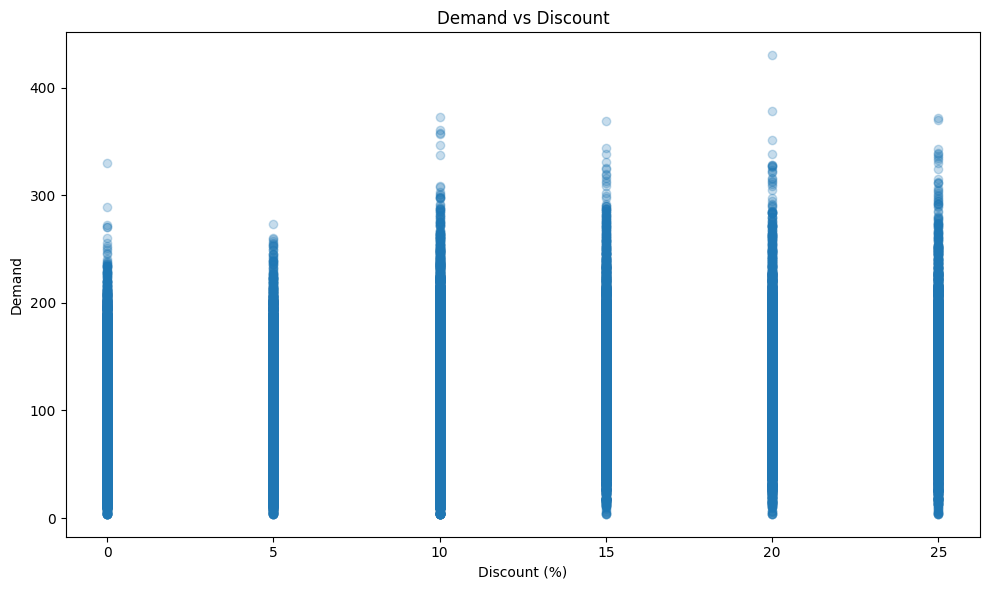

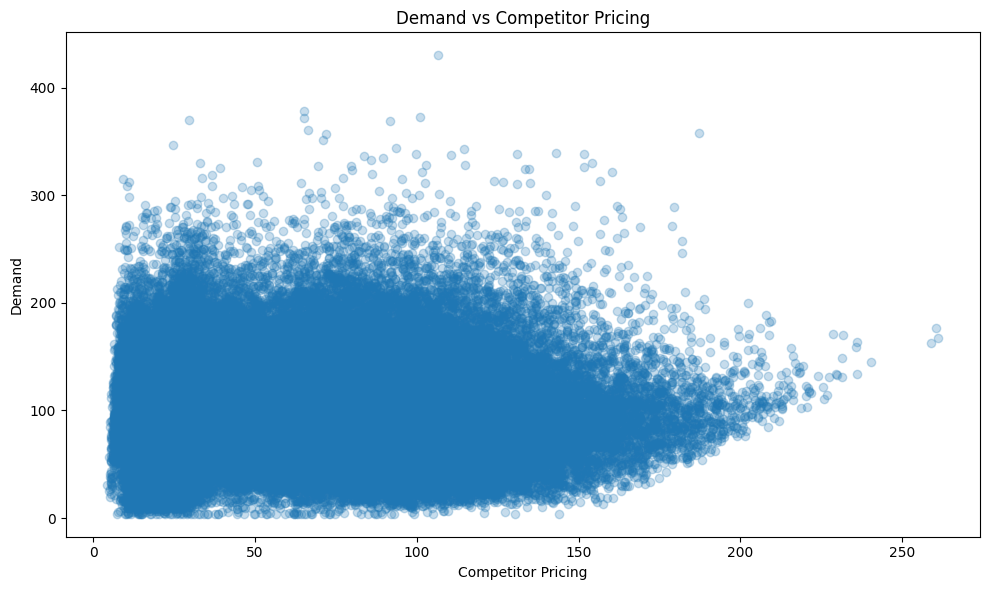

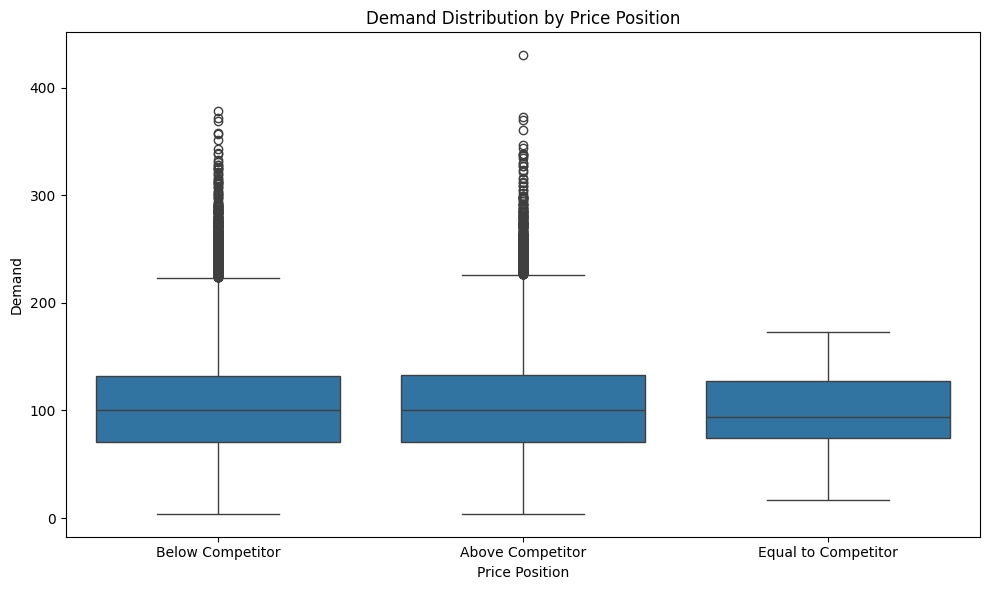

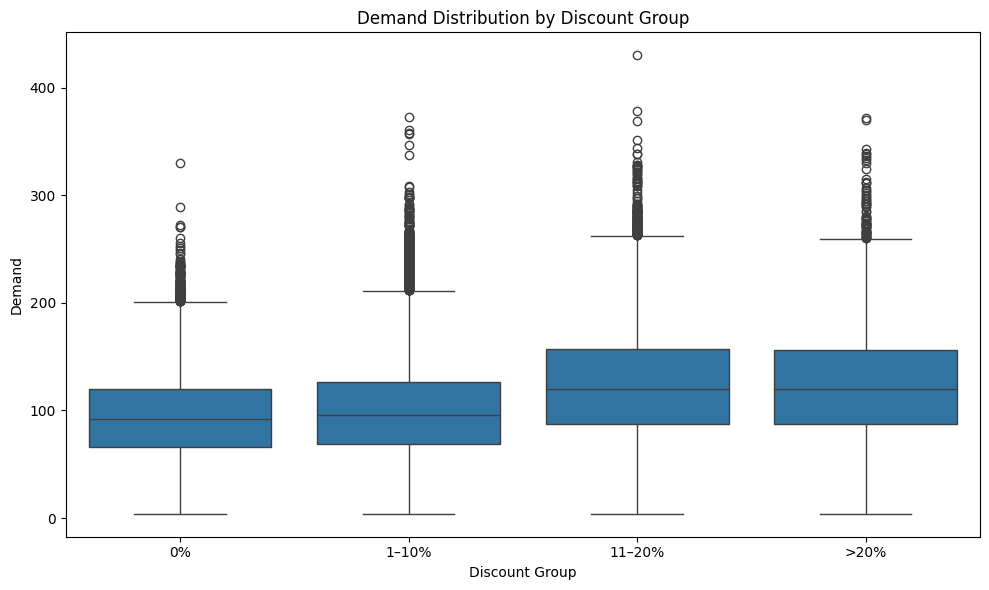

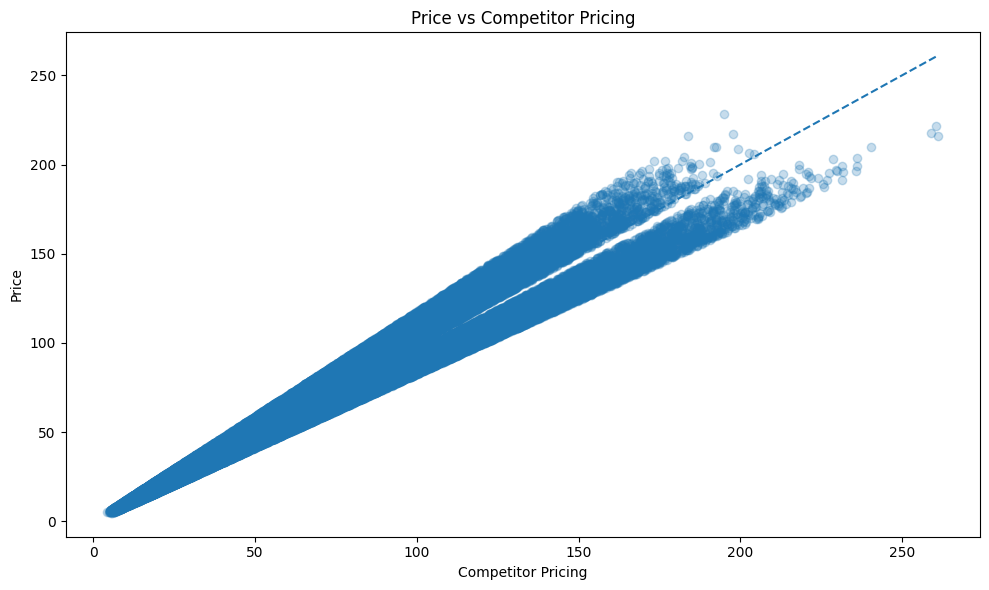

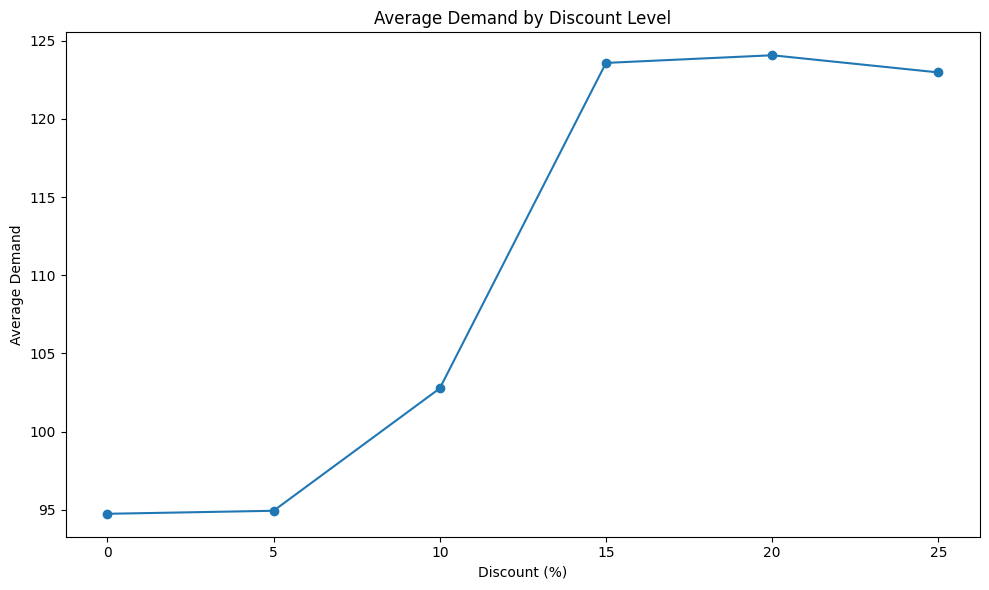

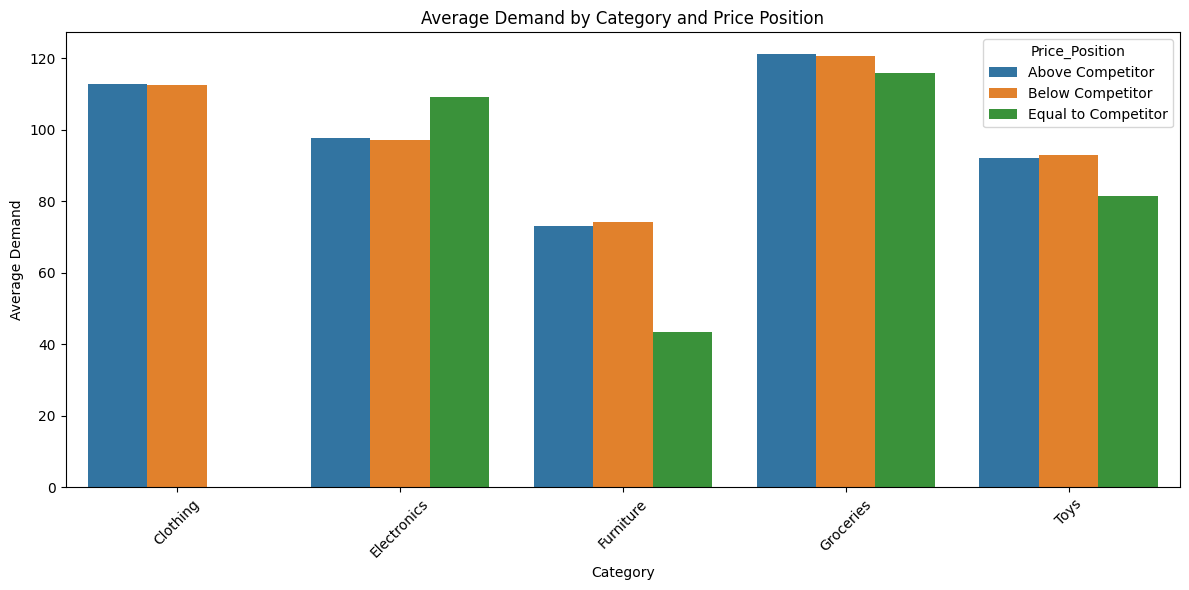


[13] PRELIMINARY FEATURE ASSESSMENT
----------------------------------------------------------------------
Price                    : Candidate feature
Discount                 : Candidate feature
Competitor Pricing       : Candidate feature
Price_Difference         : Derived candidate feature
Price_Difference_Pct     : Derived candidate feature

Note: Candidate status is based on EDA relevance only.
Feature selection and model-based importance will be performed later.

EDA 4.10 COMPLETE
No observations were removed or modified.


In [11]:
# ============================================================
# EDA 4.10 — PRICE, DISCOUNT & COMPETITOR PRICING ANALYSIS
# ============================================================

print("=" * 70)
print("EDA 4.10 — PRICE, DISCOUNT & COMPETITOR PRICING ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Price descriptive statistics
# ------------------------------------------------------------
print("\n[1] PRICE SUMMARY")
print("-" * 70)

price_summary = df["Price"].describe()

print(price_summary.to_string())

print(f"\nPrice skewness : {df['Price'].skew():.4f}")
print(f"Price kurtosis : {df['Price'].kurtosis():.4f}")

# ------------------------------------------------------------
# 2. Competitor pricing descriptive statistics
# ------------------------------------------------------------
print("\n[2] COMPETITOR PRICING SUMMARY")
print("-" * 70)

competitor_summary = df["Competitor Pricing"].describe()

print(competitor_summary.to_string())

print(
    f"\nCompetitor Pricing skewness : "
    f"{df['Competitor Pricing'].skew():.4f}"
)

print(
    f"Competitor Pricing kurtosis : "
    f"{df['Competitor Pricing'].kurtosis():.4f}"
)

# ------------------------------------------------------------
# 3. Discount descriptive statistics
# ------------------------------------------------------------
print("\n[3] DISCOUNT SUMMARY")
print("-" * 70)

discount_summary = df["Discount"].describe()

print(discount_summary.to_string())

print(f"\nDiscount skewness : {df['Discount'].skew():.4f}")
print(f"Discount kurtosis : {df['Discount'].kurtosis():.4f}")

print(
    f"\nUnique discount values : "
    f"{df['Discount'].nunique()}"
)

print(
    f"Discount values : "
    f"{sorted(df['Discount'].unique())}"
)

# ------------------------------------------------------------
# 4. Price vs Competitor Pricing
# ------------------------------------------------------------
df["Price_Difference"] = (
    df["Price"] - df["Competitor Pricing"]
)

df["Price_Difference_Pct"] = (
    df["Price_Difference"] /
    df["Competitor Pricing"] * 100
)

print("\n[4] PRICE VS COMPETITOR PRICING")
print("-" * 70)

print(
    df[
        [
            "Price",
            "Competitor Pricing",
            "Price_Difference",
            "Price_Difference_Pct"
        ]
    ].describe().to_string()
)

print(
    f"\nMean Price Difference : "
    f"{df['Price_Difference'].mean():.4f}"
)

print(
    f"Median Price Difference : "
    f"{df['Price_Difference'].median():.4f}"
)

print(
    f"Mean Price Difference % : "
    f"{df['Price_Difference_Pct'].mean():.4f}%"
)

# ------------------------------------------------------------
# 5. Pricing position classification
# ------------------------------------------------------------
df["Price_Position"] = np.select(
    [
        df["Price"] < df["Competitor Pricing"],
        df["Price"] > df["Competitor Pricing"]
    ],
    [
        "Below Competitor",
        "Above Competitor"
    ],
    default="Equal to Competitor"
)

price_position_counts = (
    df["Price_Position"]
    .value_counts()
)

price_position_pct = (
    df["Price_Position"]
    .value_counts(normalize=True) * 100
)

print("\n[5] PRICE POSITION RELATIVE TO COMPETITOR")
print("-" * 70)

for position in price_position_counts.index:

    print(
        f"{position:22s}: "
        f"{price_position_counts[position]:,} rows "
        f"({price_position_pct[position]:.2f}%)"
    )

# ------------------------------------------------------------
# 6. Demand by price position
# ------------------------------------------------------------
price_position_demand = (
    df.groupby("Price_Position")["Demand"]
    .agg(
        observations="count",
        total_demand="sum",
        average_demand="mean",
        median_demand="median",
        std_demand="std",
        minimum_demand="min",
        maximum_demand="max"
    )
    .reset_index()
)

print("\n[6] DEMAND BY PRICE POSITION")
print("-" * 70)

print(
    price_position_demand
    .sort_values("average_demand", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 7. Demand by discount level
# ------------------------------------------------------------
discount_demand = (
    df.groupby("Discount")["Demand"]
    .agg(
        observations="count",
        average_demand="mean",
        median_demand="median",
        std_demand="std"
    )
    .reset_index()
)

print("\n[7] DEMAND BY DISCOUNT LEVEL")
print("-" * 70)

print(
    discount_demand
    .sort_values("Discount")
    .to_string(index=False)
)

# ------------------------------------------------------------
# 8. Demand by discount group
# ------------------------------------------------------------
df["Discount_Group"] = pd.cut(
    df["Discount"],
    bins=[-np.inf, 0, 10, 20, np.inf],
    labels=[
        "0%",
        "1–10%",
        "11–20%",
        ">20%"
    ]
)

discount_group_demand = (
    df.groupby(
        "Discount_Group",
        observed=False
    )["Demand"]
    .agg(
        observations="count",
        average_demand="mean",
        median_demand="median",
        std_demand="std"
    )
    .reset_index()
)

print("\n[8] DEMAND BY DISCOUNT GROUP")
print("-" * 70)

print(
    discount_group_demand
    .to_string(index=False)
)

# ------------------------------------------------------------
# 9. Price statistics by category
# ------------------------------------------------------------
category_price = (
    df.groupby("Category")
    .agg(
        average_price=("Price", "mean"),
        median_price=("Price", "median"),
        std_price=("Price", "std"),
        average_competitor_price=(
            "Competitor Pricing",
            "mean"
        ),
        average_discount=("Discount", "mean"),
        average_demand=("Demand", "mean")
    )
    .reset_index()
)

category_price["price_gap"] = (
    category_price["average_price"] -
    category_price["average_competitor_price"]
)

category_price["price_gap_pct"] = (
    category_price["price_gap"] /
    category_price["average_competitor_price"] * 100
)

print("\n[9] PRICING PROFILE BY CATEGORY")
print("-" * 70)

print(
    category_price
    .sort_values("average_price", ascending=False)
    .round(2)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 10. Correlation with Demand
# ------------------------------------------------------------
correlation_columns = [
    "Demand",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Price_Difference",
    "Price_Difference_Pct"
]

price_demand_corr = (
    df[correlation_columns]
    .corr()
)

print("\n[10] PRICE-RELATED CORRELATION MATRIX")
print("-" * 70)

print(
    price_demand_corr
    .round(3)
    .to_string()
)

# ------------------------------------------------------------
# 11. Direct correlation with Demand
# ------------------------------------------------------------
print("\n[11] CORRELATION WITH DEMAND")
print("-" * 70)

demand_correlations = (
    price_demand_corr["Demand"]
    .drop("Demand")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

for variable, correlation in demand_correlations.items():

    print(
        f"{variable:25s}: "
        f"{correlation:.4f}"
    )

# ------------------------------------------------------------
# 12. Demand by price position and promotion
# ------------------------------------------------------------
price_promotion = (
    df.groupby(
        ["Price_Position", "Promotion"]
    )["Demand"]
    .mean()
    .reset_index()
)

price_promotion_pivot = (
    price_promotion
    .pivot(
        index="Price_Position",
        columns="Promotion",
        values="Demand"
    )
    .rename(
        columns={
            0: "No_Promotion",
            1: "Promotion"
        }
    )
)

print("\n[12] PRICE POSITION × PROMOTION")
print("-" * 70)

print(
    price_promotion_pivot
    .round(2)
    .to_string()
)

# ------------------------------------------------------------
# 13. Price distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    df["Price"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Product Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Competitor pricing distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    df["Competitor Pricing"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Competitor Pricing")
plt.xlabel("Competitor Pricing")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. Discount distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    df["Discount"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 16. Demand vs Price
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Price"],
    df["Demand"],
    alpha=0.25
)

plt.title("Demand vs Price")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 17. Demand vs Discount
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount"],
    df["Demand"],
    alpha=0.25
)

plt.title("Demand vs Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 18. Demand vs Competitor Pricing
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Competitor Pricing"],
    df["Demand"],
    alpha=0.25
)

plt.title("Demand vs Competitor Pricing")
plt.xlabel("Competitor Pricing")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 19. Demand by price position
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Price_Position",
    y="Demand"
)

plt.title("Demand Distribution by Price Position")
plt.xlabel("Price Position")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 20. Demand by discount group
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Discount_Group",
    y="Demand"
)

plt.title("Demand Distribution by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 21. Price vs Competitor Pricing
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Competitor Pricing"],
    df["Price"],
    alpha=0.25
)

min_value = min(
    df["Price"].min(),
    df["Competitor Pricing"].min()
)

max_value = max(
    df["Price"].max(),
    df["Competitor Pricing"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Price vs Competitor Pricing")
plt.xlabel("Competitor Pricing")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 22. Average demand by discount level
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    discount_demand["Discount"],
    discount_demand["average_demand"],
    marker="o"
)

plt.title("Average Demand by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 23. Average demand by category and price position
# ------------------------------------------------------------
category_position = (
    df.groupby(
        ["Category", "Price_Position"]
    )["Demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_position,
    x="Category",
    y="Demand",
    hue="Price_Position"
)

plt.title(
    "Average Demand by Category and Price Position"
)

plt.xlabel("Category")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 24. Final candidate feature assessment
# ------------------------------------------------------------
print("\n[13] PRELIMINARY FEATURE ASSESSMENT")
print("-" * 70)

print(
    "Price                    : Candidate feature"
)

print(
    "Discount                 : Candidate feature"
)

print(
    "Competitor Pricing       : Candidate feature"
)

print(
    "Price_Difference         : Derived candidate feature"
)

print(
    "Price_Difference_Pct     : Derived candidate feature"
)

print(
    "\nNote: Candidate status is based on EDA relevance only."
)

print(
    "Feature selection and model-based importance will be "
    "performed later."
)

print("\n" + "=" * 70)
print("EDA 4.10 COMPLETE")
print("No observations were removed or modified.")
print("=" * 70)

EDA 4.11 — STORE × PRODUCT VARIABILITY

[0] DATA VALIDATION
----------------------------------------------------------------------
Rows available for analysis : 76,000
Required columns present    : ['Store ID', 'Product ID', 'Demand']
Data validation             : PASSED

[1] STORE × PRODUCT SERIES BALANCE
----------------------------------------------------------------------
Number of Store × Product combinations : 100
Minimum observations per series        : 760
Maximum observations per series        : 760
Mean observations per series           : 760.00
Median observations per series         : 760.00

Observation count distribution:
observations
760    100
Name: count, dtype: int64

[2] STORE × PRODUCT DEMAND SUMMARY
----------------------------------------------------------------------
Store ID Product ID  total_demand  average_demand  median_demand  std_demand  minimum_demand  maximum_demand  observations       CV  demand_range  demand_share_pct
    S001      P0002         94729   

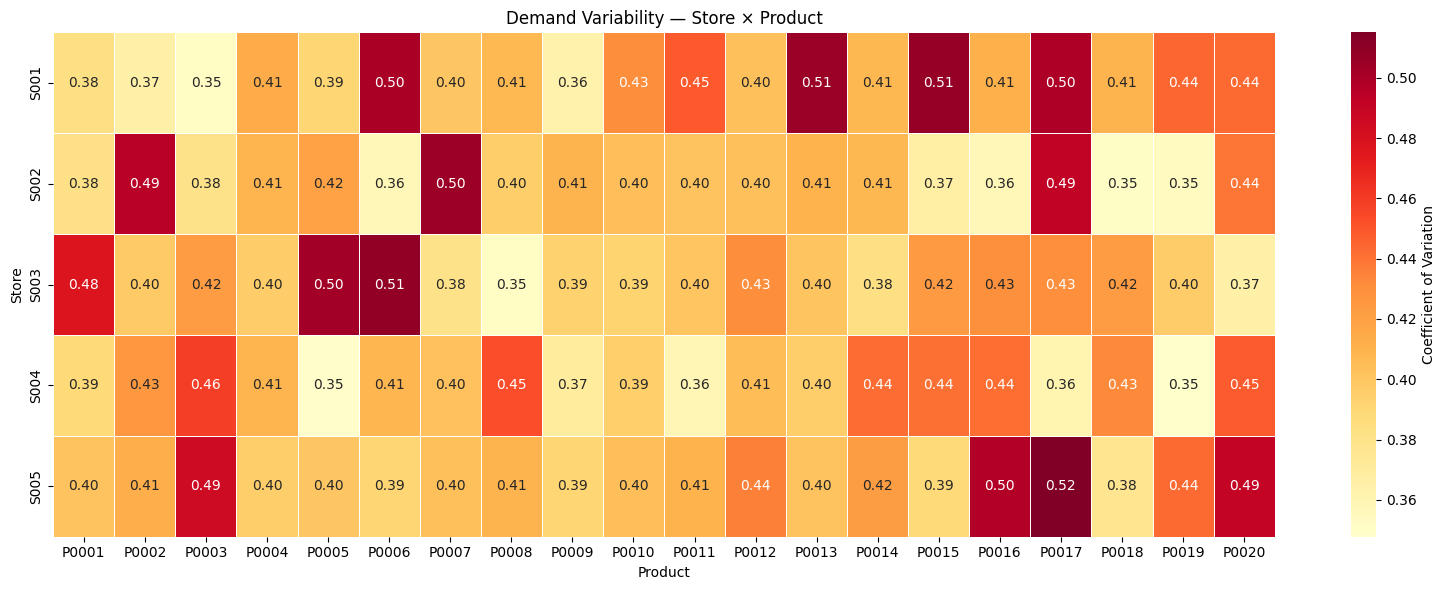

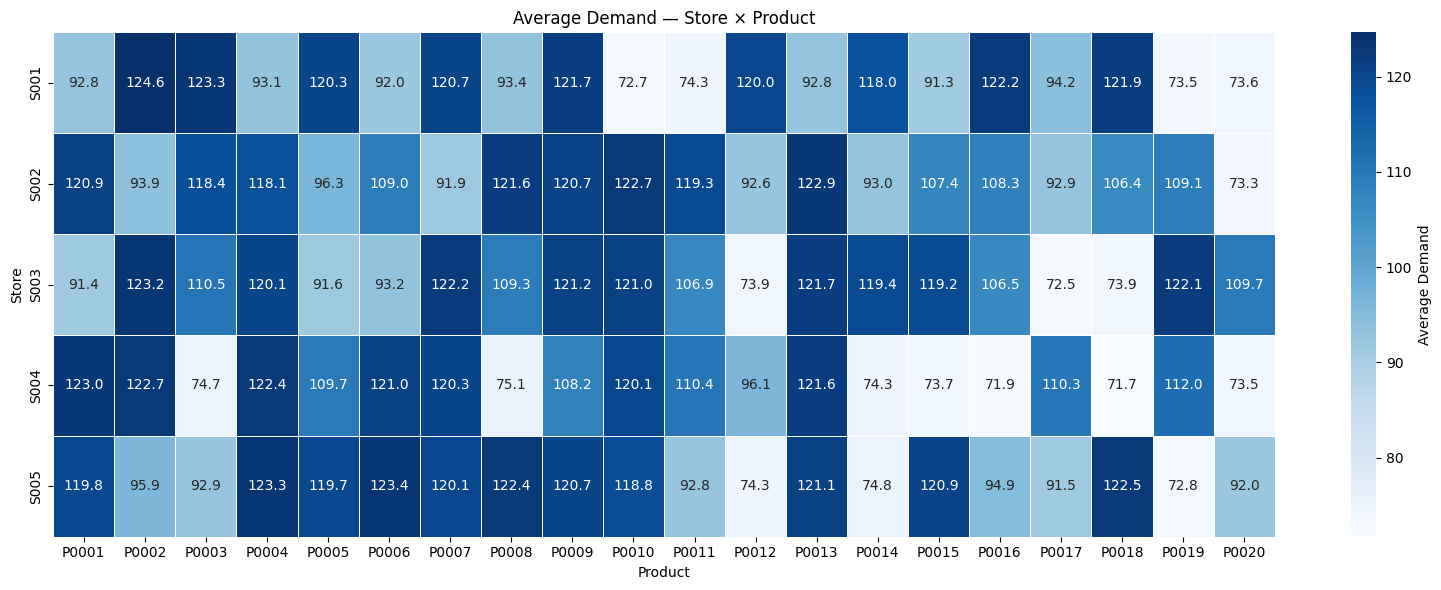

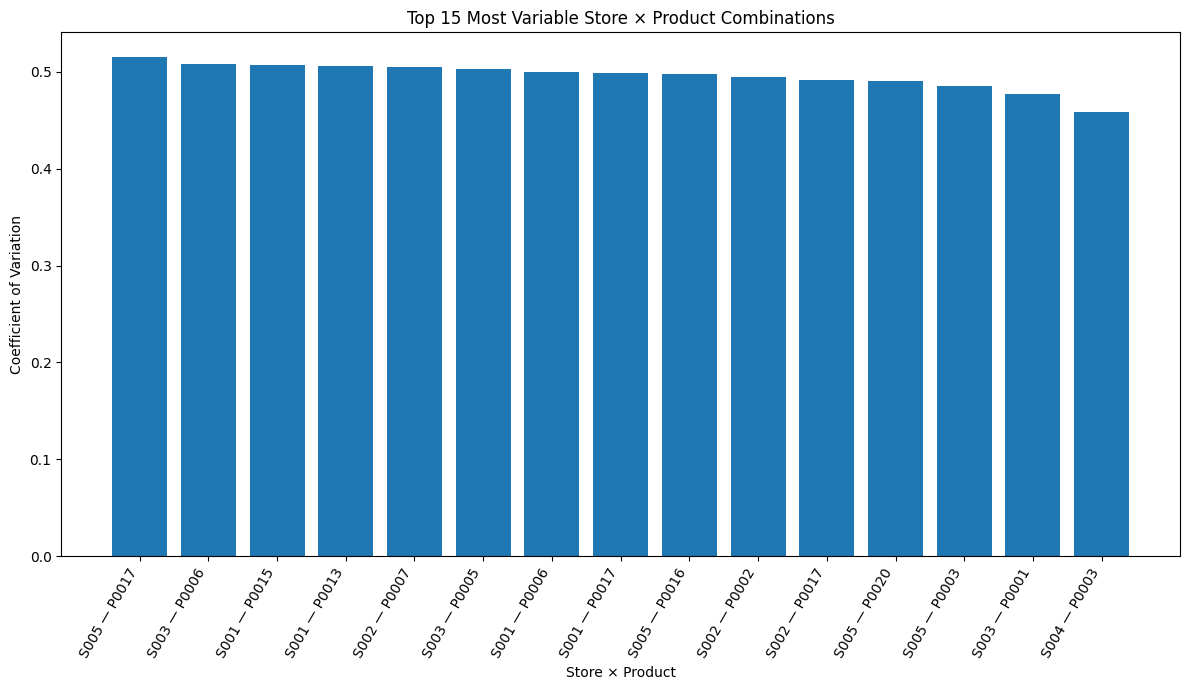

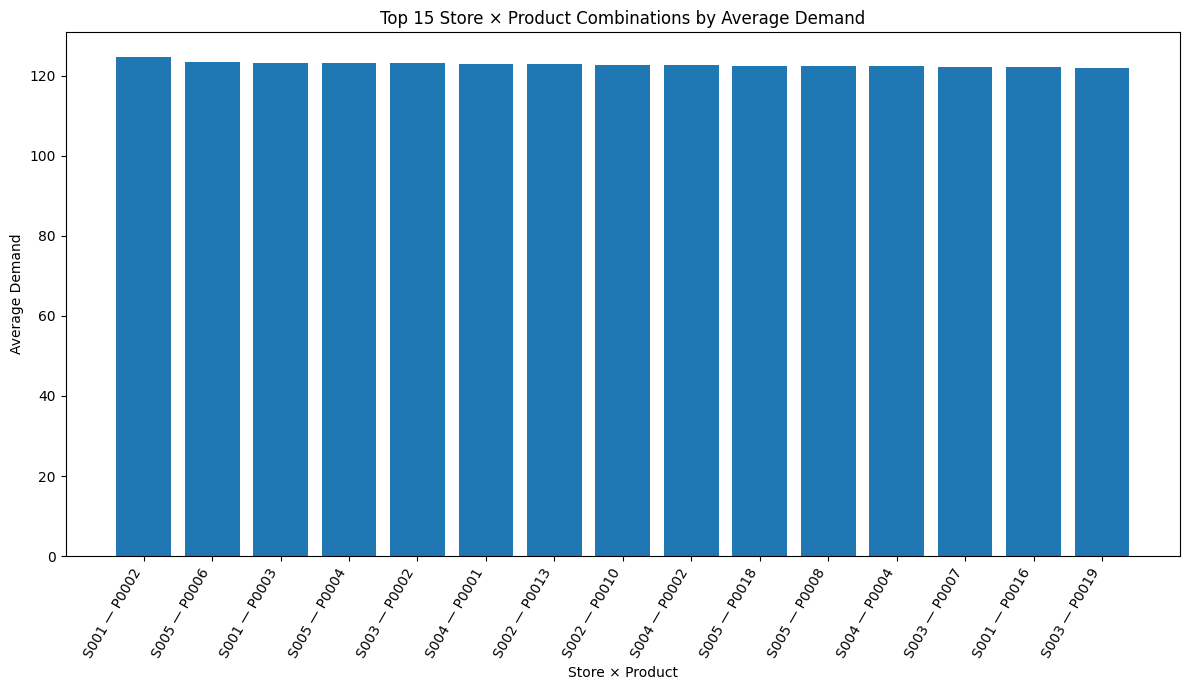

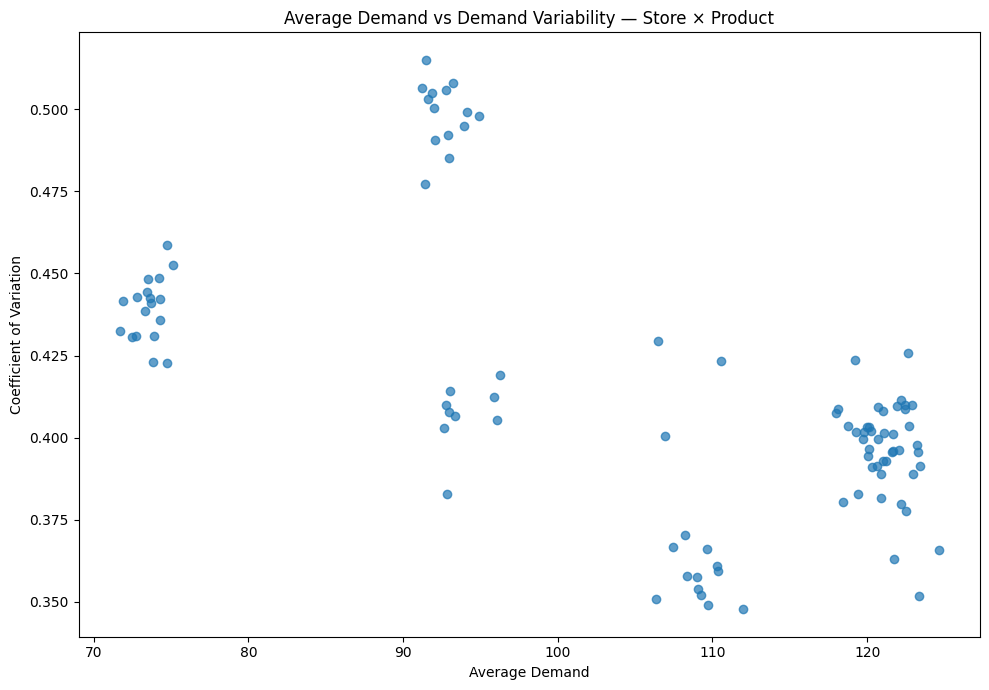


EDA 4.11 COMPLETE
Store × Product combinations analyzed : 100
Expected combinations                 : 100
Original observations retained        : 76,000

No observations were removed or modified.
Store × Product variability analysis complete.


In [12]:
# ======================================================================
# EDA 4.11 — STORE × PRODUCT VARIABILITY
# ======================================================================
# Purpose:
# Analyze demand variability at the Store × Product level.
#
# Dataset:
# Existing dataframe `df` from previous EDA cells.
#
# No observations are removed or modified.
# ======================================================================

print("=" * 70)
print("EDA 4.11 — STORE × PRODUCT VARIABILITY")
print("=" * 70)


# ----------------------------------------------------------------------
# [0] DATA VALIDATION
# ----------------------------------------------------------------------

required_columns = [
    "Store ID",
    "Product ID",
    "Demand"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Required columns missing from dataframe: {missing_required}"
    )

print("\n[0] DATA VALIDATION")
print("-" * 70)
print(f"Rows available for analysis : {len(df):,}")
print(f"Required columns present    : {required_columns}")
print("Data validation             : PASSED")


# ----------------------------------------------------------------------
# [1] STORE × PRODUCT SERIES BALANCE
# ----------------------------------------------------------------------

series_counts = (
    df.groupby(["Store ID", "Product ID"])
      .size()
      .reset_index(name="observations")
)

print("\n[1] STORE × PRODUCT SERIES BALANCE")
print("-" * 70)

print(
    f"Number of Store × Product combinations : "
    f"{len(series_counts):,}"
)

print(
    f"Minimum observations per series        : "
    f"{series_counts['observations'].min():,}"
)

print(
    f"Maximum observations per series        : "
    f"{series_counts['observations'].max():,}"
)

print(
    f"Mean observations per series           : "
    f"{series_counts['observations'].mean():.2f}"
)

print(
    f"Median observations per series         : "
    f"{series_counts['observations'].median():.2f}"
)

print("\nObservation count distribution:")
print(series_counts["observations"].value_counts().sort_index())


# ----------------------------------------------------------------------
# [2] STORE × PRODUCT DEMAND SUMMARY
# ----------------------------------------------------------------------

store_product_summary = (
    df.groupby(["Store ID", "Product ID"])["Demand"]
      .agg(
          total_demand="sum",
          average_demand="mean",
          median_demand="median",
          std_demand="std",
          minimum_demand="min",
          maximum_demand="max",
          observations="count"
      )
      .reset_index()
)

# Coefficient of Variation
store_product_summary["CV"] = (
    store_product_summary["std_demand"] /
    store_product_summary["average_demand"]
)

# Demand range
store_product_summary["demand_range"] = (
    store_product_summary["maximum_demand"] -
    store_product_summary["minimum_demand"]
)

# Percentage contribution to total demand
total_demand_all = store_product_summary["total_demand"].sum()

store_product_summary["demand_share_pct"] = (
    store_product_summary["total_demand"] /
    total_demand_all * 100
)

print("\n[2] STORE × PRODUCT DEMAND SUMMARY")
print("-" * 70)

print(
    store_product_summary
    .sort_values("average_demand", ascending=False)
    .to_string(index=False)
)


# ----------------------------------------------------------------------
# [3] HIGHEST-DEMAND STORE × PRODUCT COMBINATIONS
# ----------------------------------------------------------------------

top_average = (
    store_product_summary
    .sort_values("average_demand", ascending=False)
    .head(10)
)

print("\n[3] TOP 10 STORE × PRODUCT COMBINATIONS BY AVERAGE DEMAND")
print("-" * 70)

print(
    top_average[
        [
            "Store ID",
            "Product ID",
            "average_demand",
            "median_demand",
            "std_demand",
            "CV",
            "total_demand"
        ]
    ].to_string(index=False)
)


# ----------------------------------------------------------------------
# [4] MOST VOLATILE STORE × PRODUCT COMBINATIONS
# ----------------------------------------------------------------------

top_variable = (
    store_product_summary
    .sort_values("CV", ascending=False)
    .head(10)
)

print("\n[4] TOP 10 MOST VARIABLE STORE × PRODUCT COMBINATIONS")
print("-" * 70)

print(
    top_variable[
        [
            "Store ID",
            "Product ID",
            "average_demand",
            "std_demand",
            "CV",
            "minimum_demand",
            "maximum_demand",
            "demand_range"
        ]
    ].to_string(index=False)
)


# ----------------------------------------------------------------------
# [5] MOST STABLE STORE × PRODUCT COMBINATIONS
# ----------------------------------------------------------------------

most_stable = (
    store_product_summary
    .sort_values("CV", ascending=True)
    .head(10)
)

print("\n[5] TOP 10 MOST STABLE STORE × PRODUCT COMBINATIONS")
print("-" * 70)

print(
    most_stable[
        [
            "Store ID",
            "Product ID",
            "average_demand",
            "std_demand",
            "CV",
            "minimum_demand",
            "maximum_demand"
        ]
    ].to_string(index=False)
)


# ----------------------------------------------------------------------
# [6] STORE-LEVEL VARIABILITY ACROSS PRODUCTS
# ----------------------------------------------------------------------

store_variability = (
    store_product_summary
    .groupby("Store ID")
    .agg(
        average_store_product_demand=("average_demand", "mean"),
        average_CV=("CV", "mean"),
        maximum_CV=("CV", "max"),
        minimum_CV=("CV", "min"),
        average_std=("std_demand", "mean"),
        product_count=("Product ID", "nunique")
    )
    .reset_index()
    .sort_values("average_CV", ascending=False)
)

print("\n[6] STORE-LEVEL STORE × PRODUCT VARIABILITY")
print("-" * 70)

print(
    store_variability.to_string(index=False)
)


# ----------------------------------------------------------------------
# [7] PRODUCT-LEVEL VARIABILITY ACROSS STORES
# ----------------------------------------------------------------------

product_variability = (
    store_product_summary
    .groupby("Product ID")
    .agg(
        average_product_demand=("average_demand", "mean"),
        average_CV=("CV", "mean"),
        maximum_CV=("CV", "max"),
        minimum_CV=("CV", "min"),
        average_std=("std_demand", "mean"),
        store_count=("Store ID", "nunique")
    )
    .reset_index()
    .sort_values("average_CV", ascending=False)
)

print("\n[7] PRODUCT-LEVEL STORE × PRODUCT VARIABILITY")
print("-" * 70)

print(
    product_variability.to_string(index=False)
)


# ----------------------------------------------------------------------
# [8] STORE × PRODUCT CV MATRIX
# ----------------------------------------------------------------------

cv_matrix = (
    store_product_summary
    .pivot(
        index="Store ID",
        columns="Product ID",
        values="CV"
    )
)

print("\n[8] STORE × PRODUCT CV MATRIX")
print("-" * 70)

print(cv_matrix.round(3).to_string())


# ----------------------------------------------------------------------
# [9] STORE × PRODUCT AVERAGE DEMAND MATRIX
# ----------------------------------------------------------------------

average_demand_matrix = (
    store_product_summary
    .pivot(
        index="Store ID",
        columns="Product ID",
        values="average_demand"
    )
)

print("\n[9] STORE × PRODUCT AVERAGE DEMAND MATRIX")
print("-" * 70)

print(
    average_demand_matrix
    .round(2)
    .to_string()
)


# ----------------------------------------------------------------------
# [10] VARIABILITY RANGE
# ----------------------------------------------------------------------

print("\n[10] OVERALL STORE × PRODUCT VARIABILITY")
print("-" * 70)

print(
    f"Minimum Store × Product CV : "
    f"{store_product_summary['CV'].min():.4f}"
)

print(
    f"Maximum Store × Product CV : "
    f"{store_product_summary['CV'].max():.4f}"
)

print(
    f"Mean Store × Product CV    : "
    f"{store_product_summary['CV'].mean():.4f}"
)

print(
    f"Median Store × Product CV  : "
    f"{store_product_summary['CV'].median():.4f}"
)

print(
    f"Minimum average demand     : "
    f"{store_product_summary['average_demand'].min():.2f}"
)

print(
    f"Maximum average demand     : "
    f"{store_product_summary['average_demand'].max():.2f}"
)


# ======================================================================
# VISUALIZATIONS
# ======================================================================

# ----------------------------------------------------------------------
# [11] STORE × PRODUCT CV HEATMAP
# ----------------------------------------------------------------------

plt.figure(figsize=(16, 6))

sns.heatmap(
    cv_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Coefficient of Variation"}
)

plt.title("Demand Variability — Store × Product")
plt.xlabel("Product")
plt.ylabel("Store")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# [12] STORE × PRODUCT AVERAGE DEMAND HEATMAP
# ----------------------------------------------------------------------

plt.figure(figsize=(16, 6))

sns.heatmap(
    average_demand_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Average Demand"}
)

plt.title("Average Demand — Store × Product")
plt.xlabel("Product")
plt.ylabel("Store")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# [13] TOP 15 MOST VARIABLE STORE × PRODUCT COMBINATIONS
# ----------------------------------------------------------------------

top_15_cv = (
    store_product_summary
    .sort_values("CV", ascending=False)
    .head(15)
    .copy()
)

top_15_cv["Store_Product"] = (
    top_15_cv["Store ID"] +
    " — " +
    top_15_cv["Product ID"]
)

plt.figure(figsize=(12, 7))

plt.bar(
    top_15_cv["Store_Product"],
    top_15_cv["CV"]
)

plt.title("Top 15 Most Variable Store × Product Combinations")
plt.xlabel("Store × Product")
plt.ylabel("Coefficient of Variation")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# [14] TOP 15 STORE × PRODUCT COMBINATIONS BY AVERAGE DEMAND
# ----------------------------------------------------------------------

top_15_avg = (
    store_product_summary
    .sort_values("average_demand", ascending=False)
    .head(15)
    .copy()
)

top_15_avg["Store_Product"] = (
    top_15_avg["Store ID"] +
    " — " +
    top_15_avg["Product ID"]
)

plt.figure(figsize=(12, 7))

plt.bar(
    top_15_avg["Store_Product"],
    top_15_avg["average_demand"]
)

plt.title("Top 15 Store × Product Combinations by Average Demand")
plt.xlabel("Store × Product")
plt.ylabel("Average Demand")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# [15] AVERAGE DEMAND VS CV
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    store_product_summary["average_demand"],
    store_product_summary["CV"],
    alpha=0.7
)

plt.xlabel("Average Demand")
plt.ylabel("Coefficient of Variation")
plt.title("Average Demand vs Demand Variability — Store × Product")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# [16] SAVE ANALYTICAL RESULT IN MEMORY
# ----------------------------------------------------------------------
# No original dataset is modified.
# `store_product_summary` is the analytical output for subsequent EDA.

print("\n" + "=" * 70)
print("EDA 4.11 COMPLETE")
print("=" * 70)

print("Store × Product combinations analyzed :", len(store_product_summary))
print("Expected combinations                 : 100")
print(
    "Original observations retained        : "
    f"{len(df):,}"
)

print("\nNo observations were removed or modified.")
print("Store × Product variability analysis complete.")

print("=" * 70)

EDA 4.12 — CORRELATION ANALYSIS

Existing dataframe 'df' detected — reusing it.
Rows available for analysis : 76,000
Columns available            : 21

----------------------------------------------------------------------
[1] DATA VALIDATION
----------------------------------------------------------------------
Required numerical columns:
  ✓ Demand
  ✓ Price
  ✓ Discount
  ✓ Competitor Pricing
  ✓ Inventory Level
  ✓ Units Sold
  ✓ Units Ordered
  ✓ Promotion
  ✓ Epidemic

Missing values in correlation variables:
Demand                0
Price                 0
Discount              0
Competitor Pricing    0
Inventory Level       0
Units Sold            0
Units Ordered         0
Promotion             0
Epidemic              0

Data validation : PASSED

----------------------------------------------------------------------
[2] CORRELATION DATASET
----------------------------------------------------------------------
Variables included : 9

Variables:
['Demand', 'Price', 'Discount', 'Co

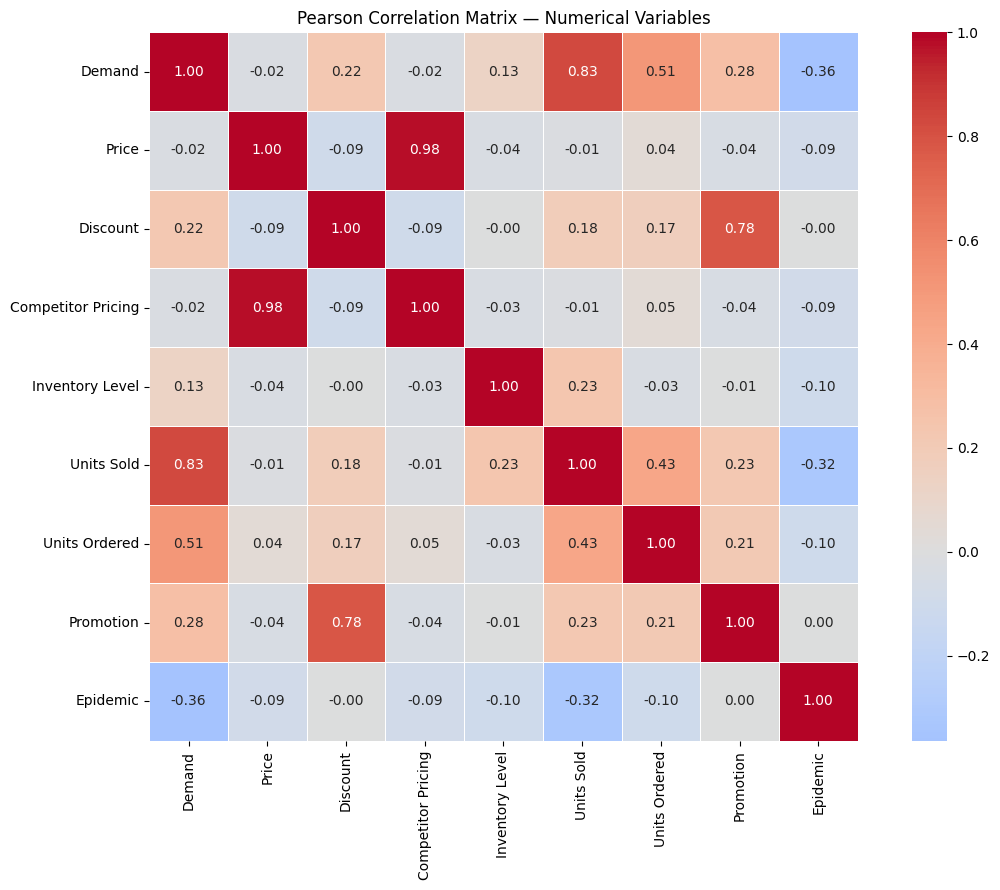

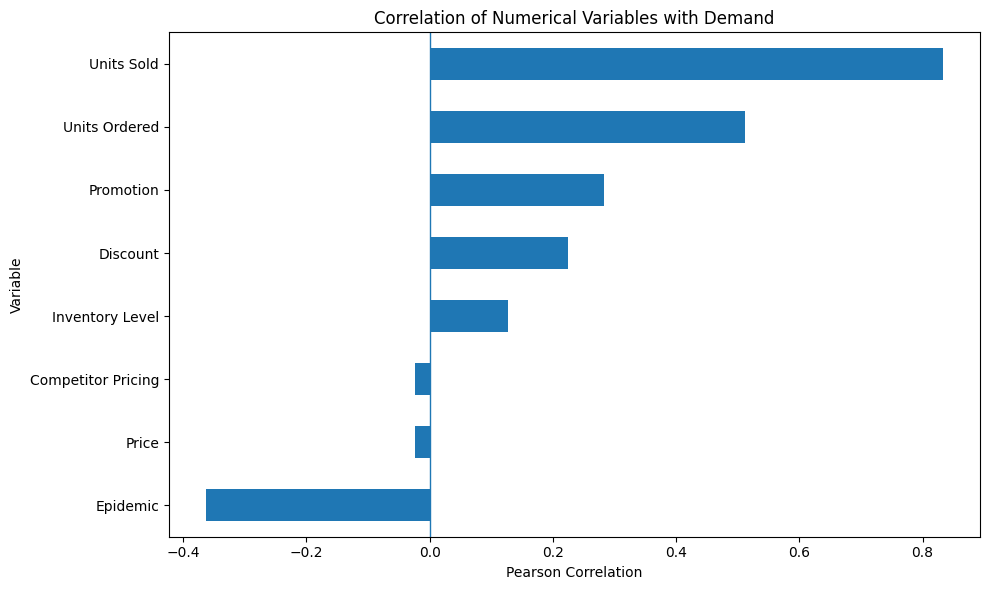


EDA 4.12 SUMMARY
Observations analyzed : 76,000
Numerical variables   : 9

Strongest positive relationship with Demand : Units Sold (0.8334)
Strongest negative relationship with Demand : Epidemic (-0.3637)

Number of predictor pairs with |r| >= 0.80 : 1

EDA 4.12 analysis complete.
No observations were removed or modified.


In [13]:
# ======================================================================
# EDA 4.12 — CORRELATION ANALYSIS
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("EDA 4.12 — CORRELATION ANALYSIS")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. DATA AVAILABILITY
# ----------------------------------------------------------------------

# Reuse existing dataframe if available.
# Otherwise load the original dataset.

try:
    df
    print("\nExisting dataframe 'df' detected — reusing it.")
except NameError:
    df = pd.read_csv("/content/sales_data.csv")
    print("\nData loaded from /content/sales_data.csv")

print(f"Rows available for analysis : {len(df):,}")
print(f"Columns available            : {len(df.columns)}")


# ----------------------------------------------------------------------
# 1. DATA VALIDATION
# ----------------------------------------------------------------------

required_columns = [
    "Demand",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Promotion",
    "Epidemic"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

print("\n" + "-" * 70)
print("[1] DATA VALIDATION")
print("-" * 70)

print("Required numerical columns:")
for col in required_columns:
    print(f"  ✓ {col}")

print("\nMissing values in correlation variables:")
missing_summary = df[required_columns].isna().sum()
print(missing_summary.to_string())

if missing_summary.sum() == 0:
    print("\nData validation : PASSED")
else:
    print("\nData validation : Missing values detected")


# ----------------------------------------------------------------------
# 2. NUMERICAL DATASET FOR CORRELATION
# ----------------------------------------------------------------------

numeric_cols = required_columns.copy()

corr_data = df[numeric_cols].copy()

print("\n" + "-" * 70)
print("[2] CORRELATION DATASET")
print("-" * 70)

print(f"Variables included : {len(numeric_cols)}")
print("\nVariables:")
print(numeric_cols)


# ----------------------------------------------------------------------
# 3. PEARSON CORRELATION MATRIX
# ----------------------------------------------------------------------

pearson_corr = corr_data.corr(method="pearson")

print("\n" + "-" * 70)
print("[3] PEARSON CORRELATION MATRIX")
print("-" * 70)

print(pearson_corr.round(3).to_string())


# ----------------------------------------------------------------------
# 4. SPEARMAN CORRELATION MATRIX
# ----------------------------------------------------------------------

spearman_corr = corr_data.corr(method="spearman")

print("\n" + "-" * 70)
print("[4] SPEARMAN CORRELATION MATRIX")
print("-" * 70)

print(spearman_corr.round(3).to_string())


# ----------------------------------------------------------------------
# 5. CORRELATION WITH DEMAND — PEARSON
# ----------------------------------------------------------------------

demand_pearson = (
    pearson_corr["Demand"]
    .drop("Demand")
    .sort_values(ascending=False)
)

print("\n" + "-" * 70)
print("[5] PEARSON CORRELATION WITH DEMAND")
print("-" * 70)

for variable, value in demand_pearson.items():
    print(f"{variable:<25}: {value:.4f}")


# ----------------------------------------------------------------------
# 6. CORRELATION WITH DEMAND — SPEARMAN
# ----------------------------------------------------------------------

demand_spearman = (
    spearman_corr["Demand"]
    .drop("Demand")
    .sort_values(ascending=False)
)

print("\n" + "-" * 70)
print("[6] SPEARMAN CORRELATION WITH DEMAND")
print("-" * 70)

for variable, value in demand_spearman.items():
    print(f"{variable:<25}: {value:.4f}")


# ----------------------------------------------------------------------
# 7. STRONGEST POSITIVE AND NEGATIVE DEMAND RELATIONSHIPS
# ----------------------------------------------------------------------

strongest_positive = demand_pearson.idxmax()
strongest_positive_value = demand_pearson.max()

strongest_negative = demand_pearson.idxmin()
strongest_negative_value = demand_pearson.min()

print("\n" + "-" * 70)
print("[7] DEMAND CORRELATION EXTREMES")
print("-" * 70)

print(
    f"Strongest positive Pearson correlation : "
    f"{strongest_positive} = {strongest_positive_value:.4f}"
)

print(
    f"Strongest negative Pearson correlation : "
    f"{strongest_negative} = {strongest_negative_value:.4f}"
)


# ----------------------------------------------------------------------
# 8. ABSOLUTE CORRELATION STRENGTH WITH DEMAND
# ----------------------------------------------------------------------

demand_strength = (
    demand_pearson
    .abs()
    .sort_values(ascending=False)
)

print("\n" + "-" * 70)
print("[8] DEMAND RELATIONSHIP STRENGTH")
print("-" * 70)

for variable, value in demand_strength.items():
    print(f"{variable:<25}: |r| = {value:.4f}")


# ----------------------------------------------------------------------
# 9. HIGHLY CORRELATED PREDICTOR PAIRS
# ----------------------------------------------------------------------

# Exclude Demand because this section is specifically checking
# relationships among predictors.

predictor_cols = [
    col for col in numeric_cols
    if col != "Demand"
]

predictor_corr = corr_data[predictor_cols].corr(method="pearson")

upper_triangle = predictor_corr.where(
    np.triu(
        np.ones(predictor_corr.shape),
        k=1
    ).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
)

print("\n" + "-" * 70)
print("[9] STRONGEST PREDICTOR-TO-PREDICTOR RELATIONSHIPS")
print("-" * 70)

print(
    correlation_pairs[
        [
            "Variable 1",
            "Variable 2",
            "Correlation"
        ]
    ].head(10).round(4).to_string(index=False)
)


# ----------------------------------------------------------------------
# 10. HIGH-CORRELATION PAIRS — POTENTIAL MULTICOLLINEARITY
# ----------------------------------------------------------------------

high_corr_pairs = correlation_pairs[
    correlation_pairs["Absolute Correlation"] >= 0.80
].copy()

print("\n" + "-" * 70)
print("[10] HIGHLY CORRELATED PREDICTOR PAIRS")
print("-" * 70)

if len(high_corr_pairs) == 0:
    print("No predictor pairs with |correlation| >= 0.80 were found.")
else:
    print(
        high_corr_pairs[
            [
                "Variable 1",
                "Variable 2",
                "Correlation"
            ]
        ].round(4).to_string(index=False)
    )


# ----------------------------------------------------------------------
# 11. PEARSON CORRELATION HEATMAP
# ----------------------------------------------------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 12. DEMAND CORRELATION BAR CHART
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 6))

demand_pearson.sort_values().plot(
    kind="barh"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("Correlation of Numerical Variables with Demand")
plt.xlabel("Pearson Correlation")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 13. FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EDA 4.12 SUMMARY")
print("=" * 70)

print(f"Observations analyzed : {len(corr_data):,}")
print(f"Numerical variables   : {len(numeric_cols)}")

print(
    f"\nStrongest positive relationship with Demand : "
    f"{strongest_positive} ({strongest_positive_value:.4f})"
)

print(
    f"Strongest negative relationship with Demand : "
    f"{strongest_negative} ({strongest_negative_value:.4f})"
)

print(
    f"\nNumber of predictor pairs with |r| >= 0.80 : "
    f"{len(high_corr_pairs)}"
)

print("\nEDA 4.12 analysis complete.")
print("No observations were removed or modified.")

print("=" * 70)

EDA 4.13 — OUTLIER / ANOMALY INVESTIGATION

Rows available for analysis : 76000
Demand minimum              : 4
Demand maximum              : 430

----------------------------------------------------------------------
[1] DEMAND DISTRIBUTION
----------------------------------------------------------------------
Q1                          : 71.00
Q3                          : 133.00
IQR                         : 62.00
IQR lower bound             : -22.00
IQR upper bound             : 226.00

----------------------------------------------------------------------
[2] IQR OUTLIERS
----------------------------------------------------------------------
IQR outlier observations    : 986
IQR outlier percentage      : 1.30%

Lower-tail outliers         : 0
Upper-tail outliers         : 986

----------------------------------------------------------------------
[3] Z-SCORE OUTLIERS
----------------------------------------------------------------------
Mean demand                 : 104.32
Standa

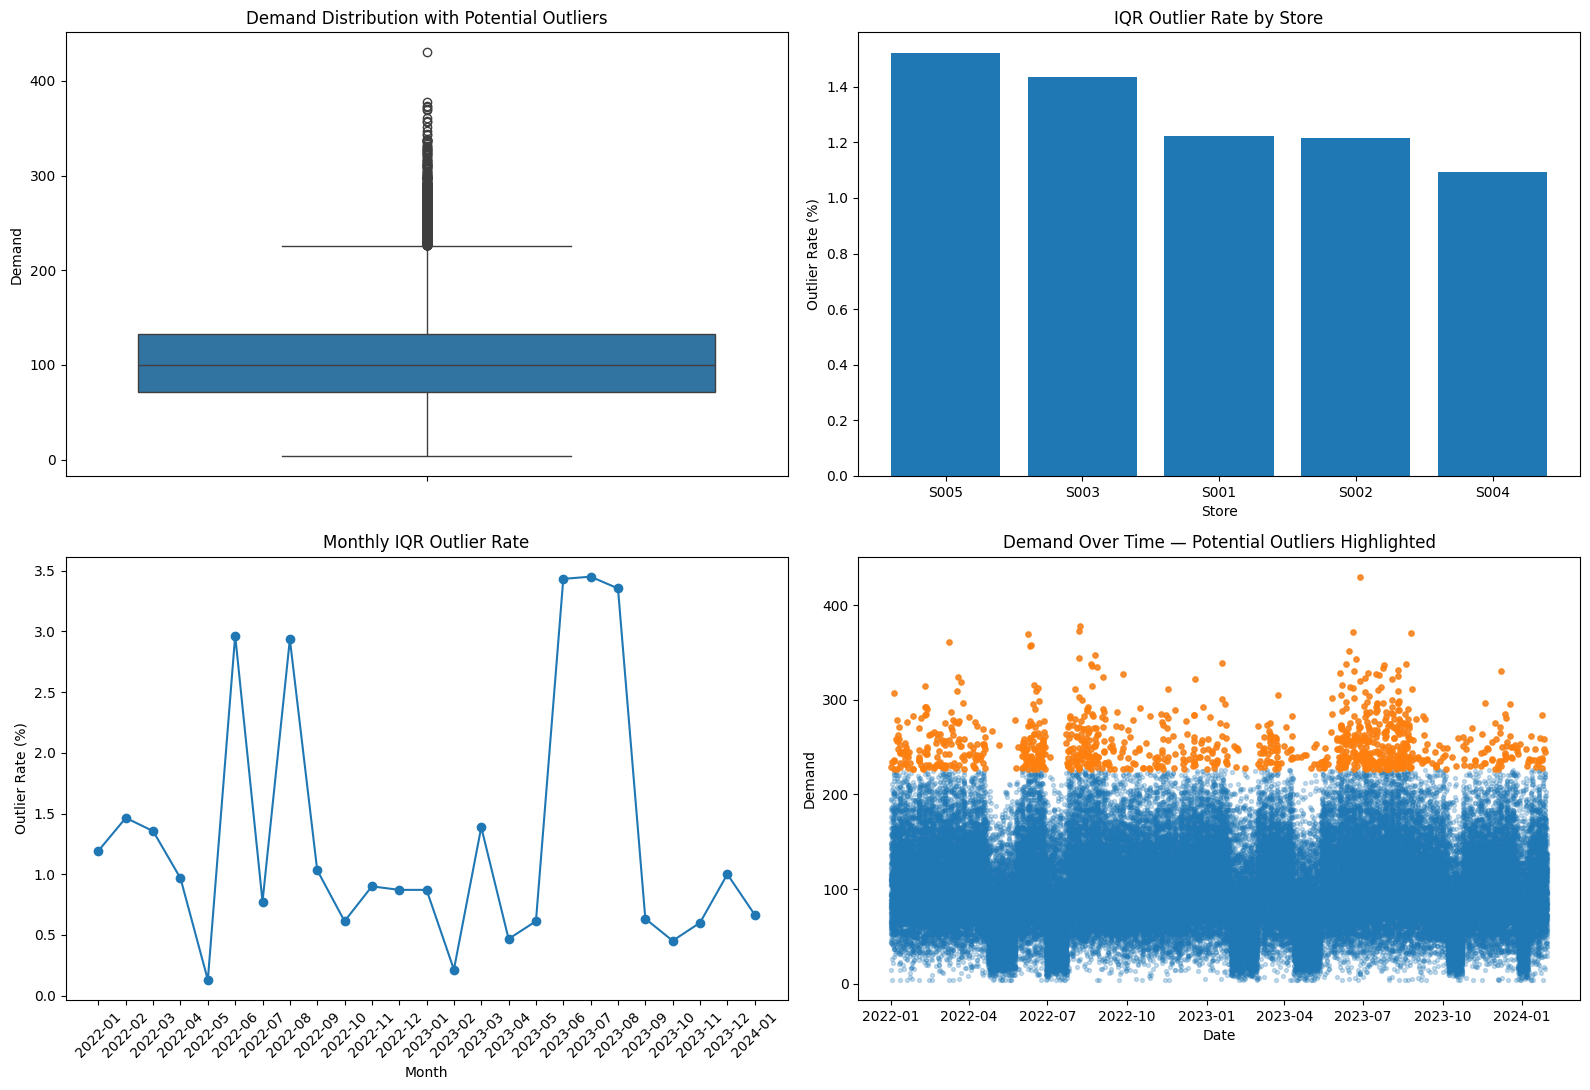


EDA 4.13 COMPLETE
Total observations analyzed : 76,000
IQR outliers                : 986
IQR outlier rate            : 1.30%
Z-score outliers (|Z| > 3)  : 517

IMPORTANT:
No observations were removed or modified.
Outliers are being investigated, not automatically treated as errors.


In [14]:
# ======================================================================
# EDA 4.13 — OUTLIER / ANOMALY INVESTIGATION
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("EDA 4.13 — OUTLIER / ANOMALY INVESTIGATION")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. VALIDATE EXISTING DATAFRAME
# ----------------------------------------------------------------------

if 'df' not in globals():
    raise NameError(
        "DataFrame 'df' is not available. "
        "Run the earlier EDA/data-loading cell first."
    )

required_cols = [
    'Date',
    'Store ID',
    'Product ID',
    'Category',
    'Promotion',
    'Epidemic',
    'Demand'
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

work = df.copy()

work['Date'] = pd.to_datetime(work['Date'])

print("\nRows available for analysis :", len(work))
print("Demand minimum              :", work['Demand'].min())
print("Demand maximum              :", work['Demand'].max())

# ----------------------------------------------------------------------
# 1. BASIC DEMAND DISTRIBUTION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[1] DEMAND DISTRIBUTION")
print("-" * 70)

demand = work['Demand'].astype(float)

q1 = demand.quantile(0.25)
q3 = demand.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1                          : {q1:.2f}")
print(f"Q3                          : {q3:.2f}")
print(f"IQR                         : {iqr:.2f}")
print(f"IQR lower bound             : {lower_bound:.2f}")
print(f"IQR upper bound             : {upper_bound:.2f}")

# ----------------------------------------------------------------------
# 2. IQR OUTLIER DETECTION
# ----------------------------------------------------------------------

iqr_outlier = (
    (work['Demand'] < lower_bound) |
    (work['Demand'] > upper_bound)
)

work['IQR_Outlier'] = iqr_outlier

iqr_count = iqr_outlier.sum()
iqr_pct = iqr_count / len(work) * 100

print("\n" + "-" * 70)
print("[2] IQR OUTLIERS")
print("-" * 70)

print(f"IQR outlier observations    : {iqr_count:,}")
print(f"IQR outlier percentage      : {iqr_pct:.2f}%")

print("\nLower-tail outliers         :",
      (work['Demand'] < lower_bound).sum())

print("Upper-tail outliers         :",
      (work['Demand'] > upper_bound).sum())

# ----------------------------------------------------------------------
# 3. Z-SCORE OUTLIER DETECTION
# ----------------------------------------------------------------------

mean_demand = demand.mean()
std_demand = demand.std()

work['Z_Score'] = (
    (work['Demand'] - mean_demand) / std_demand
)

work['Z_Outlier'] = work['Z_Score'].abs() > 3

z_count = work['Z_Outlier'].sum()
z_pct = z_count / len(work) * 100

print("\n" + "-" * 70)
print("[3] Z-SCORE OUTLIERS")
print("-" * 70)

print(f"Mean demand                 : {mean_demand:.2f}")
print(f"Standard deviation          : {std_demand:.2f}")
print(f"|Z| > 3 observations        : {z_count:,}")
print(f"|Z| > 3 percentage          : {z_pct:.2f}%")

# ----------------------------------------------------------------------
# 4. EXTREME DEMAND OBSERVATIONS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[4] TOP 20 HIGHEST DEMAND OBSERVATIONS")
print("-" * 70)

top_extremes = (
    work[
        [
            'Date',
            'Store ID',
            'Product ID',
            'Category',
            'Promotion',
            'Epidemic',
            'Demand',
            'IQR_Outlier',
            'Z_Score'
        ]
    ]
    .sort_values('Demand', ascending=False)
    .head(20)
)

print(top_extremes.to_string(index=False))

# ----------------------------------------------------------------------
# 5. LOWEST DEMAND OBSERVATIONS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[5] 20 LOWEST DEMAND OBSERVATIONS")
print("-" * 70)

lowest_extremes = (
    work[
        [
            'Date',
            'Store ID',
            'Product ID',
            'Category',
            'Promotion',
            'Epidemic',
            'Demand',
            'IQR_Outlier',
            'Z_Score'
        ]
    ]
    .sort_values('Demand', ascending=True)
    .head(20)
)

print(lowest_extremes.to_string(index=False))

# ----------------------------------------------------------------------
# 6. OUTLIERS BY STORE
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[6] OUTLIERS BY STORE")
print("-" * 70)

store_outliers = (
    work.groupby('Store ID')
    .agg(
        observations=('Demand', 'size'),
        outliers=('IQR_Outlier', 'sum'),
        average_demand=('Demand', 'mean'),
        maximum_demand=('Demand', 'max')
    )
)

store_outliers['outlier_pct'] = (
    store_outliers['outliers'] /
    store_outliers['observations'] * 100
)

print(
    store_outliers
    .sort_values('outlier_pct', ascending=False)
    .round(2)
    .to_string()
)

# ----------------------------------------------------------------------
# 7. OUTLIERS BY PRODUCT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[7] TOP PRODUCTS BY OUTLIER RATE")
print("-" * 70)

product_outliers = (
    work.groupby('Product ID')
    .agg(
        observations=('Demand', 'size'),
        outliers=('IQR_Outlier', 'sum'),
        average_demand=('Demand', 'mean'),
        maximum_demand=('Demand', 'max')
    )
)

product_outliers['outlier_pct'] = (
    product_outliers['outliers'] /
    product_outliers['observations'] * 100
)

print(
    product_outliers
    .sort_values('outlier_pct', ascending=False)
    .round(2)
    .to_string()
)

# ----------------------------------------------------------------------
# 8. OUTLIERS BY CATEGORY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[8] OUTLIERS BY CATEGORY")
print("-" * 70)

category_outliers = (
    work.groupby('Category')
    .agg(
        observations=('Demand', 'size'),
        outliers=('IQR_Outlier', 'sum'),
        average_demand=('Demand', 'mean'),
        maximum_demand=('Demand', 'max')
    )
)

category_outliers['outlier_pct'] = (
    category_outliers['outliers'] /
    category_outliers['observations'] * 100
)

print(
    category_outliers
    .sort_values('outlier_pct', ascending=False)
    .round(2)
    .to_string()
)

# ----------------------------------------------------------------------
# 9. OUTLIERS BY PROMOTION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[9] OUTLIERS BY PROMOTION STATUS")
print("-" * 70)

promotion_outliers = (
    work.groupby('Promotion')
    .agg(
        observations=('Demand', 'size'),
        outliers=('IQR_Outlier', 'sum'),
        average_demand=('Demand', 'mean'),
        maximum_demand=('Demand', 'max')
    )
)

promotion_outliers['outlier_pct'] = (
    promotion_outliers['outliers'] /
    promotion_outliers['observations'] * 100
)

print(
    promotion_outliers
    .round(2)
    .to_string()
)

# ----------------------------------------------------------------------
# 10. OUTLIERS BY EPIDEMIC STATUS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[10] OUTLIERS BY EPIDEMIC STATUS")
print("-" * 70)

epidemic_outliers = (
    work.groupby('Epidemic')
    .agg(
        observations=('Demand', 'size'),
        outliers=('IQR_Outlier', 'sum'),
        average_demand=('Demand', 'mean'),
        maximum_demand=('Demand', 'max')
    )
)

epidemic_outliers['outlier_pct'] = (
    epidemic_outliers['outliers'] /
    epidemic_outliers['observations'] * 100
)

print(
    epidemic_outliers
    .round(2)
    .to_string()
)

# ----------------------------------------------------------------------
# 11. MONTHLY OUTLIER CONCENTRATION
# ----------------------------------------------------------------------

work['YearMonth'] = work['Date'].dt.to_period('M').astype(str)

monthly_outliers = (
    work.groupby('YearMonth')
    .agg(
        observations=('Demand', 'size'),
        outliers=('IQR_Outlier', 'sum'),
        average_demand=('Demand', 'mean'),
        maximum_demand=('Demand', 'max')
    )
)

monthly_outliers['outlier_pct'] = (
    monthly_outliers['outliers'] /
    monthly_outliers['observations'] * 100
)

print("\n" + "-" * 70)
print("[11] MONTHS WITH HIGHEST OUTLIER RATE")
print("-" * 70)

print(
    monthly_outliers
    .sort_values('outlier_pct', ascending=False)
    .head(10)
    .round(2)
    .to_string()
)

# ----------------------------------------------------------------------
# 12. EXTREME OBSERVATION CONTEXT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[12] EXTREME DEMAND CONTEXT")
print("-" * 70)

extreme_context = work[work['IQR_Outlier']].copy()

if len(extreme_context) > 0:

    print("\nPromotion distribution among IQR outliers:")
    print(
        extreme_context['Promotion']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename('percentage')
        .to_string()
    )

    print("\nEpidemic distribution among IQR outliers:")
    print(
        extreme_context['Epidemic']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename('percentage')
        .to_string()
    )

else:
    print("No IQR outliers detected.")

# ----------------------------------------------------------------------
# 13. PLOTS
# ----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Distribution
sns.boxplot(
    y=work['Demand'],
    ax=axes[0, 0]
)

axes[0, 0].set_title('Demand Distribution with Potential Outliers')
axes[0, 0].set_ylabel('Demand')

# IQR outlier counts by store
store_plot = (
    store_outliers
    .sort_values('outlier_pct', ascending=False)
)

axes[0, 1].bar(
    store_plot.index,
    store_plot['outlier_pct']
)

axes[0, 1].set_title('IQR Outlier Rate by Store')
axes[0, 1].set_xlabel('Store')
axes[0, 1].set_ylabel('Outlier Rate (%)')

# Monthly outlier rate
monthly_plot = monthly_outliers.copy()

axes[1, 0].plot(
    monthly_plot.index,
    monthly_plot['outlier_pct'],
    marker='o'
)

axes[1, 0].set_title('Monthly IQR Outlier Rate')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Outlier Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Highest demand observations over time
axes[1, 1].scatter(
    work['Date'],
    work['Demand'],
    alpha=0.25,
    s=8
)

axes[1, 1].scatter(
    work.loc[work['IQR_Outlier'], 'Date'],
    work.loc[work['IQR_Outlier'], 'Demand'],
    alpha=0.8,
    s=15
)

axes[1, 1].set_title('Demand Over Time — Potential Outliers Highlighted')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Demand')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 14. FINAL STATUS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EDA 4.13 COMPLETE")
print("=" * 70)

print(f"Total observations analyzed : {len(work):,}")
print(f"IQR outliers                : {iqr_count:,}")
print(f"IQR outlier rate            : {iqr_pct:.2f}%")
print(f"Z-score outliers (|Z| > 3)  : {z_count:,}")

print("\nIMPORTANT:")
print("No observations were removed or modified.")
print("Outliers are being investigated, not automatically treated as errors.")

print("=" * 70)

In [15]:
# ================================================================
# EDA 4.14 — FORECASTING READINESS
# ================================================================

print("=" * 70)
print("EDA 4.14 — FORECASTING READINESS")
print("=" * 70)

# ------------------------------------------------
# 0. REUSE EXISTING DATAFRAME
# ------------------------------------------------

if 'df' not in globals():
    raise NameError(
        "DataFrame 'df' was not found. Run the earlier EDA cells first."
    )

data = df.copy()

print(f"\nRows available for analysis : {len(data):,}")
print(f"Columns available            : {len(data.columns)}")

# ------------------------------------------------
# 1. IDENTIFY REQUIRED COLUMNS
# ------------------------------------------------

required_columns = [
    'Date',
    'Store ID',
    'Product ID',
    'Demand'
]

missing_required = [
    col for col in required_columns
    if col not in data.columns
]

if missing_required:
    raise ValueError(
        f"Required columns missing: {missing_required}"
    )

print("\n" + "-" * 70)
print("[1] REQUIRED COLUMN VALIDATION")
print("-" * 70)

for col in required_columns:
    print(f"✓ {col}")

print("Required columns : PASSED")

# ------------------------------------------------
# 2. DATE VALIDATION
# ------------------------------------------------

print("\n" + "-" * 70)
print("[2] DATE STRUCTURE")
print("-" * 70)

data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

invalid_dates = data['Date'].isna().sum()

print(f"Invalid / unparseable dates : {invalid_dates:,}")

if invalid_dates == 0:
    print("Date parsing : PASSED")
else:
    print("Date parsing : FAILED")

min_date = data['Date'].min()
max_date = data['Date'].max()

print(f"Minimum date                : {min_date.date()}")
print(f"Maximum date                : {max_date.date()}")

calendar_days = (
    data['Date'].max() - data['Date'].min()
).days + 1

unique_dates = data['Date'].nunique()

print(f"Calendar span (days)        : {calendar_days:,}")
print(f"Unique observed dates       : {unique_dates:,}")

# ------------------------------------------------
# 3. GLOBAL DATE CONTINUITY
# ------------------------------------------------

print("\n" + "-" * 70)
print("[3] GLOBAL DATE CONTINUITY")
print("-" * 70)

observed_dates = (
    pd.Series(data['Date'].dropna().unique())
    .sort_values()
)

full_date_range = pd.date_range(
    start=min_date,
    end=max_date,
    freq='D'
)

missing_global_dates = full_date_range.difference(
    observed_dates
)

print(f"Expected calendar dates     : {len(full_date_range):,}")
print(f"Observed calendar dates     : {len(observed_dates):,}")
print(f"Missing global dates        : {len(missing_global_dates):,}")

if len(missing_global_dates) == 0:
    print("Global date continuity : PASSED")
else:
    print("Global date continuity : REQUIRES INVESTIGATION")

# ------------------------------------------------
# 4. DUPLICATE TIME-SERIES OBSERVATIONS
# ------------------------------------------------

print("\n" + "-" * 70)
print("[4] DUPLICATE DATE × STORE × PRODUCT CHECK")
print("-" * 70)

duplicate_mask = data.duplicated(
    subset=['Date', 'Store ID', 'Product ID'],
    keep=False
)

duplicate_rows = duplicate_mask.sum()
duplicate_groups = (
    data.loc[duplicate_mask,
             ['Date', 'Store ID', 'Product ID']]
    .drop_duplicates()
    .shape[0]
)

print(f"Duplicate rows              : {duplicate_rows:,}")
print(f"Duplicate groups            : {duplicate_groups:,}")

if duplicate_rows == 0:
    print("Duplicate check : PASSED")
else:
    print("Duplicate check : FAILED — investigate before forecasting")

# ------------------------------------------------
# 5. MISSING VALUES IN CORE FORECASTING FIELDS
# ------------------------------------------------

print("\n" + "-" * 70)
print("[5] MISSING VALUE CHECK")
print("-" * 70)

core_forecasting_columns = [
    'Date',
    'Store ID',
    'Product ID',
    'Demand'
]

missing_summary = data[core_forecasting_columns].isna().sum()

print(missing_summary.to_string())

total_missing_core = missing_summary.sum()

print(
    f"\nTotal missing values in core fields : "
    f"{total_missing_core:,}"
)

if total_missing_core == 0:
    print("Core missing-value check : PASSED")
else:
    print("Core missing-value check : REQUIRES INVESTIGATION")

# ------------------------------------------------
# 6. DEMAND VALIDATION
# ------------------------------------------------

print("\n" + "-" * 70)
print("[6] DEMAND TARGET VALIDATION")
print("-" * 70)

print(f"Demand minimum             : {data['Demand'].min():,.2f}")
print(f"Demand maximum             : {data['Demand'].max():,.2f}")
print(f"Demand mean                : {data['Demand'].mean():,.2f}")
print(f"Demand median              : {data['Demand'].median():,.2f}")

zero_demand = (data['Demand'] == 0).sum()
negative_demand = (data['Demand'] < 0).sum()

print(f"Zero-demand observations   : {zero_demand:,}")
print(f"Negative-demand observations: {negative_demand:,}")

if negative_demand == 0:
    print("Negative demand check : PASSED")
else:
    print("Negative demand check : FAILED")

# ------------------------------------------------
# 7. STORE × PRODUCT STRUCTURE
# ------------------------------------------------

print("\n" + "-" * 70)
print("[7] STORE × PRODUCT TIME-SERIES STRUCTURE")
print("-" * 70)

unique_stores = data['Store ID'].nunique()
unique_products = data['Product ID'].nunique()

store_product_pairs = (
    data[['Store ID', 'Product ID']]
    .drop_duplicates()
)

num_pairs = len(store_product_pairs)

print(f"Unique stores              : {unique_stores:,}")
print(f"Unique products            : {unique_products:,}")
print(f"Store × Product series     : {num_pairs:,}")

# ------------------------------------------------
# 8. OBSERVATIONS PER SERIES
# ------------------------------------------------

series_counts = (
    data.groupby(['Store ID', 'Product ID'])
        .size()
)

print("\nObservations per Store × Product series:")

print(f"Minimum observations       : {series_counts.min():,}")
print(f"Maximum observations       : {series_counts.max():,}")
print(f"Median observations        : {series_counts.median():,.0f}")
print(f"Mean observations          : {series_counts.mean():,.2f}")

print("\nSeries observation-count distribution:")
print(
    series_counts.describe()
    .to_string()
)

# ------------------------------------------------
# 9. SERIES WITH INCOMPLETE DAILY HISTORY
# ------------------------------------------------

print("\n" + "-" * 70)
print("[8] STORE × PRODUCT HISTORY COMPLETENESS")
print("-" * 70)

expected_series_length = calendar_days

incomplete_series = (
    series_counts[series_counts < expected_series_length]
)

complete_series = (
    series_counts[series_counts == expected_series_length]
)

print(f"Expected observations per complete series : "
      f"{expected_series_length:,}")

print(f"Complete Store × Product series           : "
      f"{len(complete_series):,}")

print(f"Incomplete Store × Product series         : "
      f"{len(incomplete_series):,}")

if len(incomplete_series) == 0:
    print("Series completeness : PASSED")
else:
    print("Series completeness : REQUIRES INVESTIGATION")

# ------------------------------------------------
# 10. DATE GAPS WITHIN EACH STORE × PRODUCT SERIES
# ------------------------------------------------

print("\n" + "-" * 70)
print("[9] WITHIN-SERIES DATE GAP CHECK")
print("-" * 70)

gap_results = []

for (store, product), group in data.groupby(
    ['Store ID', 'Product ID']
):
    dates = (
        group['Date']
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    if len(dates) <= 1:
        gap_count = 0
        max_gap = 0
    else:
        date_diffs = dates.diff().dt.days.dropna()
        gap_count = int((date_diffs > 1).sum())
        max_gap = int(date_diffs.max())

    gap_results.append({
        'Store ID': store,
        'Product ID': product,
        'Date_Gaps': gap_count,
        'Maximum_Gap_Days': max_gap
    })

gap_df = pd.DataFrame(gap_results)

series_with_gaps = (
    gap_df['Date_Gaps'] > 0
).sum()

total_gap_events = gap_df['Date_Gaps'].sum()
maximum_series_gap = gap_df['Maximum_Gap_Days'].max()

print(f"Series with date gaps       : {series_with_gaps:,}")
print(f"Total date-gap events       : {total_gap_events:,}")
print(f"Largest gap within a series : "
      f"{maximum_series_gap:,} day(s)")

if series_with_gaps == 0:
    print("Within-series continuity : PASSED")
else:
    print("Within-series continuity : REQUIRES INVESTIGATION")

# ------------------------------------------------
# 11. MINIMUM HISTORY FOR FORECASTING
# ------------------------------------------------

print("\n" + "-" * 70)
print("[10] FORECASTING HISTORY SUFFICIENCY")
print("-" * 70)

history_thresholds = [30, 90, 180, 365]

for threshold in history_thresholds:

    sufficient_series = (
        series_counts >= threshold
    ).sum()

    percentage = (
        sufficient_series / len(series_counts) * 100
    )

    print(
        f"Series with >= {threshold:3} observations : "
        f"{sufficient_series:3} / {len(series_counts):3} "
        f"({percentage:6.2f}%)"
    )

# ------------------------------------------------
# 12. MONTHLY / SEASONAL COVERAGE
# ------------------------------------------------

print("\n" + "-" * 70)
print("[11] SEASONAL COVERAGE")
print("-" * 70)

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

years_present = sorted(
    data['Year'].dropna().unique()
)

months_present = sorted(
    data['Month'].dropna().unique()
)

print(f"Years represented           : {years_present}")
print(f"Number of years             : {len(years_present)}")
print(f"Months represented          : {months_present}")
print(f"Number of months            : {len(months_present)}")

year_month_counts = (
    data.groupby(['Year', 'Month'])
        .size()
)

print(
    f"Year × Month combinations   : "
    f"{len(year_month_counts):,}"
)

# ------------------------------------------------
# 13. FORECASTING HORIZON FEASIBILITY
# ------------------------------------------------

print("\n" + "-" * 70)
print("[12] CHRONOLOGICAL TRAIN / TEST FEASIBILITY")
print("-" * 70)

forecast_horizons = [7, 30, 60, 90]

for horizon in forecast_horizons:

    if calendar_days > horizon:

        train_end = (
            max_date -
            pd.Timedelta(days=horizon)
        )

        train_rows = (
            data['Date'] <= train_end
        ).sum()

        test_rows = (
            data['Date'] > train_end
        ).sum()

        print(
            f"{horizon:3}-day holdout -> "
            f"Train rows: {train_rows:6,} | "
            f"Test rows: {test_rows:6,} | "
            f"Test start: {train_end.date()}"
        )

# ------------------------------------------------
# 14. POTENTIAL FORECASTING LEAKAGE VARIABLES
# ------------------------------------------------

print("\n" + "-" * 70)
print("[13] POTENTIAL FEATURE-LEAKAGE REVIEW")
print("-" * 70)

potential_leakage_variables = [
    'Inventory Level',
    'Units Sold',
    'Units Ordered'
]

available_leakage_variables = [
    col for col in potential_leakage_variables
    if col in data.columns
]

for col in available_leakage_variables:
    print(
        f"⚠ {col}: PRESENT — timing/availability "
        f"must be validated before model use"
    )

print(
    "\nThese variables are NOT automatically rejected."
)
print(
    "Their usability depends on whether their value would "
    "be known at the forecasting cutoff."
)

# ------------------------------------------------
# 15. POTENTIALLY USABLE EXOGENOUS VARIABLES
# ------------------------------------------------

print("\n" + "-" * 70)
print("[14] POTENTIAL EXOGENOUS VARIABLES")
print("-" * 70)

candidate_exogenous = [
    'Price',
    'Discount',
    'Promotion',
    'Competitor Pricing',
    'Epidemic',
    'Weather Condition'
]

available_exogenous = [
    col for col in candidate_exogenous
    if col in data.columns
]

for col in available_exogenous:
    print(
        f"✓ {col}: PRESENT — availability/timing "
        f"must be validated before forecasting use"
    )

# ------------------------------------------------
# 16. FINAL READINESS CHECKS
# ------------------------------------------------

print("\n" + "=" * 70)
print("EDA 4.14 — FORECASTING READINESS SUMMARY")
print("=" * 70)

checks = {
    "Required columns available":
        len(missing_required) == 0,

    "Valid dates":
        invalid_dates == 0,

    "No duplicate Date × Store × Product rows":
        duplicate_rows == 0,

    "No missing core forecasting values":
        total_missing_core == 0,

    "No negative demand":
        negative_demand == 0,

    "Multiple Store × Product series":
        num_pairs > 1,

    "At least 365 observations available per series":
        (series_counts >= 365).all(),

    "Multiple years available":
        len(years_present) >= 2,

    "Multiple months available":
        len(months_present) >= 12,

    "Chronological holdout possible":
        calendar_days > 90
}

for check, status in checks.items():

    symbol = "✓" if status else "✗"

    print(
        f"{symbol} {check}"
    )

print("\n" + "-" * 70)

if all(checks.values()):
    print("OVERALL FORECASTING READINESS : PASSED")
else:
    print(
        "OVERALL FORECASTING READINESS : "
        "REQUIRES INVESTIGATION"
    )

print("-" * 70)

print("\nIMPORTANT:")
print("• No observations were removed.")
print("• No values were modified.")
print("• No forecasting model was trained.")
print("• No feature was permanently selected or rejected.")
print("• Leakage variables remain flagged for timing validation.")

print("\n" + "=" * 70)
print("EDA 4.14 COMPLETE")
print("=" * 70)

EDA 4.14 — FORECASTING READINESS

Rows available for analysis : 76,000
Columns available            : 21

----------------------------------------------------------------------
[1] REQUIRED COLUMN VALIDATION
----------------------------------------------------------------------
✓ Date
✓ Store ID
✓ Product ID
✓ Demand
Required columns : PASSED

----------------------------------------------------------------------
[2] DATE STRUCTURE
----------------------------------------------------------------------
Invalid / unparseable dates : 0
Date parsing : PASSED
Minimum date                : 2022-01-01
Maximum date                : 2024-01-30
Calendar span (days)        : 760
Unique observed dates       : 760

----------------------------------------------------------------------
[3] GLOBAL DATE CONTINUITY
----------------------------------------------------------------------
Expected calendar dates     : 760
Observed calendar dates     : 760
Missing global dates        : 0
Global date continu

In [16]:
# ======================================================================
# EDA 4.15 — EDA CONCLUSIONS & FORECASTING IMPLICATIONS
# ======================================================================

print("=" * 70)
print("EDA 4.15 — EDA CONCLUSIONS & FORECASTING IMPLICATIONS")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. VALIDATION
# ----------------------------------------------------------------------

required_columns = [
    "Date",
    "Store ID",
    "Product ID",
    "Demand"
]

missing_required = [c for c in required_columns if c not in df.columns]

if missing_required:
    raise ValueError(
        f"Required columns missing from dataframe: {missing_required}"
    )

print("\n[1] EDA VALIDATION")
print("-" * 70)

print(f"Rows available              : {len(df):,}")
print(f"Columns available           : {len(df.columns)}")
print(f"Unique dates                : {df['Date'].nunique():,}")
print(f"Unique stores               : {df['Store ID'].nunique()}")
print(f"Unique products             : {df['Product ID'].nunique()}")
print(f"Store × Product series      : "
      f"{df.groupby(['Store ID', 'Product ID']).ngroups}")

print("\nCore forecasting fields:")
for col in required_columns:
    print(f"  ✓ {col}")

# ----------------------------------------------------------------------
# 1. CORE DEMAND PROFILE
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[2] CORE DEMAND PROFILE")
print("-" * 70)

total_demand = df["Demand"].sum()
avg_demand = df["Demand"].mean()
median_demand = df["Demand"].median()
std_demand = df["Demand"].std()
min_demand = df["Demand"].min()
max_demand = df["Demand"].max()

print(f"Total demand               : {total_demand:,.0f}")
print(f"Average demand             : {avg_demand:.2f}")
print(f"Median demand              : {median_demand:.2f}")
print(f"Standard deviation         : {std_demand:.2f}")
print(f"Minimum demand             : {min_demand:.2f}")
print(f"Maximum demand             : {max_demand:.2f}")

print("\nInterpretation:")
print(
    "Demand is positive throughout the dataset and shows substantial "
    "variation around its central level."
)

# ----------------------------------------------------------------------
# 2. TEMPORAL STRUCTURE
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[3] TEMPORAL STRUCTURE")
print("-" * 70)

date_min = df["Date"].min()
date_max = df["Date"].max()
unique_dates = df["Date"].nunique()

print(f"Date range                 : {date_min} → {date_max}")
print(f"Observed daily dates       : {unique_dates}")
print(f"Years represented          : {sorted(df['Date'].dt.year.unique())}")
print(f"Months represented         : {df['Date'].dt.month.nunique()}")

print("\nTemporal conclusion:")
print(
    "The dataset contains a continuous multi-year daily history. "
    "This supports chronological forecasting and seasonal feature "
    "engineering."
)

# ----------------------------------------------------------------------
# 3. SEASONALITY FINDINGS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[4] SEASONALITY")
print("-" * 70)

season_map = {
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
    12: "Winter"
}

season_df = df.copy()
season_df["Season"] = season_df["Date"].dt.month.map(season_map)

season_summary = (
    season_df.groupby("Season")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Average demand by season:")
for season, value in season_summary.items():
    print(f"  {season:<10}: {value:.2f}")

highest_season = season_summary.index[0]
lowest_season = season_summary.index[-1]

print(f"\nHighest seasonal average : {highest_season}")
print(f"Lowest seasonal average  : {lowest_season}")

print("\nForecasting implication:")
print(
    "Calendar and seasonal features should be considered because demand "
    "shows systematic variation across seasons."
)

# ----------------------------------------------------------------------
# 4. STORE / PRODUCT / CATEGORY STRUCTURE
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[5] STORE, PRODUCT & CATEGORY STRUCTURE")
print("-" * 70)

store_avg = (
    df.groupby("Store ID")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

product_avg = (
    df.groupby("Product ID")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Store average-demand range:")
print(
    f"  Highest : {store_avg.index[0]} = "
    f"{store_avg.iloc[0]:.2f}"
)
print(
    f"  Lowest  : {store_avg.index[-1]} = "
    f"{store_avg.iloc[-1]:.2f}"
)

print("\nProduct average-demand range:")
print(
    f"  Highest : {product_avg.index[0]} = "
    f"{product_avg.iloc[0]:.2f}"
)
print(
    f"  Lowest  : {product_avg.index[-1]} = "
    f"{product_avg.iloc[-1]:.2f}"
)

if "Category" in df.columns:

    category_avg = (
        df.groupby("Category")["Demand"]
        .mean()
        .sort_values(ascending=False)
    )

    print("\nCategory average-demand range:")
    print(
        f"  Highest : {category_avg.index[0]} = "
        f"{category_avg.iloc[0]:.2f}"
    )
    print(
        f"  Lowest  : {category_avg.index[-1]} = "
        f"{category_avg.iloc[-1]:.2f}"
    )

print("\nForecasting implication:")
print(
    "Demand differs across stores, products, and categories. "
    "The forecasting design should therefore preserve Store × Product "
    "identity rather than treating the entire dataset as one homogeneous "
    "time series."
)

# ----------------------------------------------------------------------
# 5. STORE × PRODUCT VARIABILITY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[6] STORE × PRODUCT VARIABILITY")
print("-" * 70)

sp_stats = (
    df.groupby(["Store ID", "Product ID"])["Demand"]
    .agg(["mean", "std"])
    .reset_index()
)

sp_stats["CV"] = (
    sp_stats["std"] / sp_stats["mean"]
)

print(f"Minimum Store × Product CV : {sp_stats['CV'].min():.3f}")
print(f"Maximum Store × Product CV : {sp_stats['CV'].max():.3f}")
print(f"Median Store × Product CV  : {sp_stats['CV'].median():.3f}")

print("\nForecasting implication:")
print(
    "Demand volatility varies materially across Store × Product series. "
    "Forecast evaluation should therefore include series-level error "
    "analysis rather than relying only on one global metric."
)

# ----------------------------------------------------------------------
# 6. PROMOTION EFFECT — DESCRIPTIVE ONLY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[7] PROMOTION")
print("-" * 70)

if "Promotion" in df.columns:

    promotion_summary = (
        df.groupby("Promotion")["Demand"]
        .mean()
    )

    no_promo = promotion_summary.get(0, float("nan"))
    promo = promotion_summary.get(1, float("nan"))

    print(f"Average demand without promotion : {no_promo:.2f}")
    print(f"Average demand with promotion    : {promo:.2f}")

    if no_promo != 0:
        difference_pct = ((promo - no_promo) / no_promo) * 100
        print(f"Descriptive difference           : "
              f"{promo - no_promo:.2f}")
        print(f"Descriptive percentage difference: "
              f"{difference_pct:.2f}%")

    print("\nImportant:")
    print(
        "Promotion is associated with higher observed demand, but this "
        "analysis is descriptive and does NOT establish causation."
    )

    print("\nForecasting implication:")
    print(
        "Promotion can be considered as an exogenous forecasting feature "
        "when its value is known before the forecast period."
    )

# ----------------------------------------------------------------------
# 7. PRICE / DISCOUNT / COMPETITOR VARIABLES
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[8] PRICE & COMPETITIVE VARIABLES")
print("-" * 70)

price_features = [
    "Price",
    "Discount",
    "Competitor Pricing"
]

available_price_features = [
    c for c in price_features if c in df.columns
]

if available_price_features:

    corr_with_demand = (
        df[["Demand"] + available_price_features]
        .corr()["Demand"]
        .drop("Demand")
        .sort_values()
    )

    for feature, correlation in corr_with_demand.items():
        print(f"{feature:<22}: {correlation:.4f}")

print("\nForecasting implication:")
print(
    "Price, discount, and competitor pricing may provide useful "
    "information, but their inclusion must depend on whether the values "
    "are known or reliably forecastable at the prediction cutoff."
)

# ----------------------------------------------------------------------
# 8. CORRELATION FINDINGS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[9] CORRELATION FINDINGS")
print("-" * 70)

correlation_columns = [
    "Demand",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Promotion",
    "Epidemic"
]

available_corr_columns = [
    c for c in correlation_columns if c in df.columns
]

corr_matrix = df[available_corr_columns].corr()

demand_corr = (
    corr_matrix["Demand"]
    .drop("Demand")
    .sort_values(ascending=False)
)

print("Correlation with Demand:")

for feature, value in demand_corr.items():
    print(f"  {feature:<22}: {value:.4f}")

print("\nKey observed relationships from EDA:")
print("  Units Sold vs Demand    : approximately +0.83")
print("  Units Ordered vs Demand : approximately +0.51")
print("  Epidemic vs Demand      : approximately -0.36")
print("  Discount vs Demand      : approximately +0.22")
print("  Price vs Demand         : approximately -0.02")

print("\nImportant:")
print(
    "Correlation identifies association, not causation."
)

# ----------------------------------------------------------------------
# 9. LEAKAGE REVIEW
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[10] FORECASTING LEAKAGE REVIEW")
print("-" * 70)

leakage_risk = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered"
]

print("Variables requiring temporal-availability validation:")

for feature in leakage_risk:
    if feature in df.columns:
        print(f"  ⚠ {feature}")

print("\nReason:")
print(
    "These variables may contain information that would not be available "
    "at the actual forecasting cutoff. Their use must be determined from "
    "forecast timing and operational semantics."
)

print("\nExplicit rule:")
print(
    "Demand at the prediction timestamp MUST NOT be used as a predictor "
    "for that same timestamp."
)

# ----------------------------------------------------------------------
# 10. OUTLIER / ANOMALY FINDINGS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[11] OUTLIER / ANOMALY CONCLUSION")
print("-" * 70)

q1 = df["Demand"].quantile(0.25)
q3 = df["Demand"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    (df["Demand"] < lower_bound) |
    (df["Demand"] > upper_bound)
)

outlier_count = outlier_mask.sum()
outlier_pct = (outlier_count / len(df)) * 100

print(f"Q1                         : {q1:.2f}")
print(f"Q3                         : {q3:.2f}")
print(f"IQR                        : {iqr:.2f}")
print(f"Lower IQR boundary        : {lower_bound:.2f}")
print(f"Upper IQR boundary        : {upper_bound:.2f}")
print(f"Potential IQR outliers     : {outlier_count:,}")
print(f"Potential outlier rate     : {outlier_pct:.2f}%")

print("\nDecision:")
print(
    "Potential outliers are retained. No observations are removed merely "
    "because they fall outside the IQR boundaries."
)

print(
    "The observations may represent genuine demand spikes and are "
    "therefore relevant to forecasting and inventory planning."
)

# ----------------------------------------------------------------------
# 11. FORECASTING READINESS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("[12] FORECASTING READINESS")
print("-" * 70)

checks = {
    "Required forecasting columns available":
        all(c in df.columns for c in required_columns),

    "Valid dates":
        df["Date"].notna().all(),

    "No missing Demand":
        df["Demand"].notna().all(),

    "No negative Demand":
        (df["Demand"] >= 0).all(),

    "Multiple Store × Product series":
        df.groupby(["Store ID", "Product ID"]).ngroups > 1,

    "Complete daily history":
        df["Date"].nunique() >= 365
}

for check, result in checks.items():
    status = "✓ PASSED" if result else "✗ FAILED"
    print(f"{status:<12} {check}")

overall_ready = all(checks.values())

print("\nOverall forecasting readiness:")
print(
    "PASSED"
    if overall_ready
    else "NOT PASSED — investigate failed validation checks"
)

# ----------------------------------------------------------------------
# 12. FORECASTING IMPLICATIONS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FORECASTING IMPLICATIONS")
print("=" * 70)

implications = [
    (
        "1. FORECASTING GRAIN",
        "Forecast at the Store × Product × Date grain."
    ),
    (
        "2. TEMPORAL VALIDATION",
        "Use chronological train/validation/test splits. "
        "Do NOT use random train-test splitting."
    ),
    (
        "3. BASELINE",
        "Establish Naive and Moving Average baselines before "
        "introducing complex models."
    ),
    (
        "4. SEASONALITY",
        "Use calendar/seasonal features because demand varies "
        "systematically over time."
    ),
    (
        "5. LAG FEATURES",
        "Historical demand lags and rolling statistics are strong "
        "candidate forecasting features."
    ),
    (
        "6. STORE / PRODUCT EFFECTS",
        "Preserve Store ID and Product ID information because "
        "demand levels differ materially across series."
    ),
    (
        "7. PROMOTION",
        "Promotion is a candidate exogenous feature when known "
        "before the forecast period."
    ),
    (
        "8. PRICE VARIABLES",
        "Price, Discount, and Competitor Pricing require "
        "forecast-time availability validation."
    ),
    (
        "9. LEAKAGE CONTROL",
        "Inventory Level, Units Sold, and Units Ordered require "
        "explicit timing validation before model inclusion."
    ),
    (
        "10. OUTLIERS",
        "Do not automatically remove demand spikes. Evaluate "
        "their effect on forecast errors."
    ),
    (
        "11. EVALUATION",
        "Evaluate performance both globally and by Store × "
        "Product series."
    ),
    (
        "12. INVENTORY DECISIONS",
        "Forecast uncertainty and forecast errors should later "
        "feed the inventory-risk and safety-stock analysis."
    )
]

for title, statement in implications:
    print(f"\n{title}")
    print(f"   {statement}")

# ----------------------------------------------------------------------
# 13. MODELLING ROADMAP
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 5 — FORECASTING ROADMAP")
print("=" * 70)

roadmap = [
    "Step 1  : Define forecasting horizon and prediction cutoff",
    "Step 2  : Create chronological train / validation / test sets",
    "Step 3  : Build Naive baseline",
    "Step 4  : Build Moving Average baseline",
    "Step 5  : Evaluate baseline errors",
    "Step 6  : Prepare lag and rolling features",
    "Step 7  : Validate all features for temporal leakage",
    "Step 8  : Train statistical forecasting model where appropriate",
    "Step 9  : Train ML forecasting model where appropriate",
    "Step 10 : Compare models using time-aware evaluation",
    "Step 11 : Analyze errors by Store × Product",
    "Step 12 : Select the simplest defensible forecasting approach"
]

for item in roadmap:
    print(item)

# ----------------------------------------------------------------------
# 14. FINAL CONCLUSION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EDA 4.15 — FINAL CONCLUSION")
print("=" * 70)

print("""
The EDA establishes that the dataset is suitable for demand forecasting.
Demand exhibits temporal variation, seasonal differences, store-level and
product-level differences, promotion-associated variation, and meaningful
Store × Product volatility.

The dataset contains complete daily histories for the Store × Product
series, allowing chronological forecasting and time-aware evaluation.

Promotion, Discount, Price, Competitor Pricing, and other operational
variables may provide predictive information, but their inclusion must
depend on whether their values are known at the forecasting cutoff.

Inventory Level, Units Sold, and Units Ordered require particular
attention because their timing may create data leakage.

Potential demand outliers are retained because unusual observations may
represent genuine demand events rather than data errors.

The forecasting phase should therefore begin with simple time-aware
baselines, followed by feature engineering and more advanced models only
after leakage validation. Model performance must be evaluated against
baselines and examined at the Store × Product level.
""")

print("\n" + "=" * 70)
print("EDA 4.15 COMPLETE")
print("No observations were removed or modified.")
print("No forecasting model was trained.")
print("EDA PHASE 4 COMPLETE.")
print("=" * 70)

EDA 4.15 — EDA CONCLUSIONS & FORECASTING IMPLICATIONS

[1] EDA VALIDATION
----------------------------------------------------------------------
Rows available              : 76,000
Columns available           : 21
Unique dates                : 760
Unique stores               : 5
Unique products             : 20
Store × Product series      : 100

Core forecasting fields:
  ✓ Date
  ✓ Store ID
  ✓ Product ID
  ✓ Demand

----------------------------------------------------------------------
[2] CORE DEMAND PROFILE
----------------------------------------------------------------------
Total demand               : 7,928,104
Average demand             : 104.32
Median demand              : 100.00
Standard deviation         : 46.96
Minimum demand             : 4.00
Maximum demand             : 430.00

Interpretation:
Demand is positive throughout the dataset and shows substantial variation around its central level.

----------------------------------------------------------------------
[3] TE